<a href="https://colab.research.google.com/github/gabrielniculaesei/lendingclub-dataset/blob/colab/FAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi del Rischio Creditizio - Dataset LendingClub

Questo notebook affronta una domanda centrale per qualsiasi istituzione finanziaria: **a chi conviene prestare denaro?**

Il dataset proviene da LendingClub, una piattaforma americana di prestiti peer-to-peer. Contiene informazioni su migliaia di prestiti erogati: le caratteristiche dei richiedenti, le condizioni applicate e, soprattutto, se il prestito è stato ripagato o meno.

Il nostro obiettivo non è semplicemente descrivere i dati, ma interrogarli. Ogni analisi parte da una domanda concreta e cerca una risposta nei numeri.

---

## Indice

### Parte 1 - Preparazione dei Dati
1. [Caricamento del dataset](#caricamento)
2. [Rinomina delle variabili](#rinomina)
3. [Descrizione delle variabili](#descrizione)
4. [Gestione valori mancanti](#valori-mancanti)
5. [Conversione tipi di dato](#conversione)

### Parte 2 - Analisi Esplorativa
6. [Panoramica delle distribuzioni](#distribuzioni-generali)
7. [Sbilanciamento delle classi](#sbilanciamento-classi)
8. [Analisi Interest Rate](#interest-rate-dist)
9. [Analisi Installment](#installment-analisi)
10. [Analisi Credit History](#credit_history_days)
11. [Analisi FICO Score](#fico-score)
12. [Analisi Purpose](#purpose-analisi)
13. [Analisi Annual Income](#annual-income)
14. [Analisi DTI](#dti-analisi)
15. [Analisi Revolving Utilization](#revolving-util)
16. [Analisi Credit Policy](#credit-policy)
17. [Analisi Inquiries](#inquiries)
18. [Analisi Public Records](#public-records)
19. [Analisi Delinquencies](#delinquencies)

### Parte 3 - Verifica Statistica
20. [Test di normalita](#test-normalita)
21. [Confronto tra gruppi (t-test)](#test-t)
22. [Associazioni categoriche (chi-quadrato)](#test-chi2)

### Parte 4 - Analisi Multivariata
23. [Correlazioni e covarianze](#correlazioni)
24. [Regressione lineare](#regressione)
25. [Diagnostica del modello](#diagnostica)

### Parte 5 - Tecniche Avanzate
26. [Clustering dei clienti (K-Means)](#clustering)
27. [Riduzione dimensionalita (PCA)](#pca)

### Parte 6 - Modelli Predittivi
28. [Regressione logistica](#logistica)
29. [Valutazione del modello (ROC, Confusion Matrix)](#valutazione)
30. [Strategia di pricing del rischio](#strategia)
31. [Confronto con K-Nearest Neighbors](#knn)
32. [Feature Importance](#feature-importance)
33. [Gaussian Naive Bayes](#naive-bayes)
34. [Confronto finale dei modelli](#confronto-modelli)

### Parte 7 - Conclusioni
35. [Sintesi dei risultati](#conclusioni)

---

## Struttura del notebook

**Parte 1 - Preparazione dei dati**
Prima di analizzare qualsiasi cosa, dobbiamo conoscere i dati: cosa rappresentano, se sono completi, se contengono errori.

**Parte 2 - Analisi esplorativa**
Osserviamo le distribuzioni delle variabili chiave. Ci chiediamo: quali valori sono tipici? Quali sono anomali? Esistono pattern evidenti?

**Parte 3 - Verifica statistica**
Le differenze che osserviamo sono reali o dovute al caso? Applichiamo test statistici per validare le nostre intuizioni.

**Parte 4 - Analisi multivariata**
Le variabili non agiscono in isolamento. Studiamo correlazioni e costruiamo modelli per capire quali fattori influenzano davvero il rischio.

**Parte 5 - Tecniche avanzate**
Segmentiamo i clienti con il clustering e riduciamo la complessità con la PCA.

**Parte 6 - Modello predittivo e strategia**
Costruiamo un modello per prevedere il default e lo traduciamo in una strategia decisionale concreta per la banca. Confrontiamo diversi approcci (Logistic Regression, KNN, Naive Bayes) per trovare la soluzione migliore.

**Parte 7 - Conclusioni**
Sintetizziamo i risultati principali, le implicazioni pratiche e i possibili sviluppi futuri.

<a id="caricamento"></a>
# Parte 1 - Preparazione dei Dati

## Caricamento del Dataset

**Domanda iniziale**: Che dati abbiamo a disposizione?

LendingClub e una piattaforma che mette in contatto chi cerca un prestito con chi vuole investire. A differenza delle banche tradizionali, i prestiti sono finanziati da privati. Questo rende particolarmente importante la valutazione del rischio: gli investitori devono sapere a chi stanno prestando i loro soldi.

Iniziamo caricando il dataset e guardando la sua struttura.

In [331]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = "https://raw.githubusercontent.com/gabrielniculaesei/lendingclub-dataset/refs/heads/main/loans.csv"
data = pd.read_csv(url)

data.columns

Index(['customer.id', 'credit.policy', 'purpose', 'int.rate', 'installment',
       'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal',
       'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec',
       'not.fully.paid'],
      dtype='object')

<a id="rinomina"></a>
## Rinomina delle Variabili

I nomi originali usano punti e abbreviazioni poco leggibili. Li convertiamo in formato snake_case per facilitare il lavoro in Python. Manteniamo gli acronimi standard del settore finanziario (FICO, DTI) perche sono universalmente riconosciuti.

In [332]:
new_columns = {
    'customer.id': 'customer_id',
    'credit.policy': 'credit_policy',
    'purpose': 'purpose',
    'int.rate': 'interest_rate',
    'installment': 'installment',
    'log.annual.inc': 'log_annual_income',
    'dti': 'dti',
    'fico': 'fico_score',
    'days.with.cr.line': 'credit_history_days',
    'revol.bal': 'revolving_balance',
    'revol.util': 'revolving_util',
    'inq.last.6mths': 'inquiries_last_6m',
    'delinq.2yrs': 'delinquencies_2y',
    'pub.rec': 'public_records',
    'not.fully.paid': 'not_fully_paid'
}

data = data.rename(columns=new_columns)


print(data.columns.tolist())

['customer_id', 'credit_policy', 'purpose', 'interest_rate', 'installment', 'log_annual_income', 'dti', 'fico_score', 'credit_history_days', 'revolving_balance', 'revolving_util', 'inquiries_last_6m', 'delinquencies_2y', 'public_records', 'not_fully_paid']


<a id="descrizione"></a>
## Che informazioni abbiamo su ogni cliente?

Prima di analizzare i dati, dobbiamo capire cosa rappresenta ogni variabile. Ecco un dizionario delle colonne:

**Identificazione**
- `customer_id`: codice univoco del cliente

**Profilo creditizio**
- `credit_policy`: indica se il cliente rispetta i criteri di credito della piattaforma (1 = si, 0 = no)
- `fico_score`: punteggio creditizio americano, scala da 300 a 850. E il numero che sintetizza l'affidabilita creditizia di una persona
- `credit_history_days`: anzianita della storia creditizia in giorni
- `delinquencies_2y`: numero di pagamenti in ritardo negli ultimi 2 anni
- `public_records`: eventi negativi pubblici come fallimenti o pignoramenti
- `inquiries_last_6m`: quante volte negli ultimi 6 mesi qualcuno ha richiesto il report creditizio del cliente

**Situazione debitoria**
- `dti` (Debt-to-Income): percentuale del reddito mensile destinata al pagamento di debiti
- `revolving_balance`: saldo attuale su linee di credito rotativo (carte di credito e simili)
- `revolving_util`: percentuale del credito disponibile effettivamente utilizzata

**Dettagli del prestito**
- `purpose`: motivazione dichiarata del prestito
- `interest_rate`: tasso di interesse applicato
- `installment`: importo della rata mensile

**Reddito**
- `log_annual_income`: logaritmo naturale del reddito annuale

**Variabile target**
- `not_fully_paid`: 1 = il cliente non ha ripagato completamente, 0 = ha ripagato regolarmente

Questa e la variabile che vogliamo prevedere.

In [333]:
data.head(10)

,customer_id,credit_policy,purpose,interest_rate,installment,log_annual_income,dti,fico_score,credit_history_days,revolving_balance,revolving_util,inquiries_last_6m,delinquencies_2y,public_records,not_fully_paid
0,10001,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854.0,52.1,0.0,0,0,0
1,10002,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623.0,76.7,0.0,0,0,0
2,10003,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511.0,25.6,1.0,0,0,0
3,10004,1,debt_consolidation,0.1008,162.34,11.350407,8.1,712,2699.958333,33667.0,73.2,1.0,0,0,0
4,10005,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740.0,39.5,0.0,1,0,0
5,10006,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807.0,51,0.0,0,0,0
6,10007,1,debt_consolidation,0.1496,194.02,10.714418,4,667,3180.041667,3839.0,76.8,0.0,0,1,1
7,10008,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220.0,68.6,0.0,0,0,1
8,10009,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909.0,51.1,1.0,0,0,0
9,10010,1,debt_consolidation,0.1221,84.12,10.203592,10,707,2730.041667,5630.0,23,1.0,0,0,0


In [334]:
print(len(data))

9578


### Una precisazione sui valori zero

Prima di cercare valori mancanti, chiariamo un punto importante: in questo dataset, zero non significa "dato mancante". Per esempio:
- `delinquencies_2y = 0` significa che il cliente non ha mai pagato in ritardo negli ultimi 2 anni
- `public_records = 0` significa nessun fallimento o pignoramento

Questi zeri contengono informazione utile e non vanno trattati come dati assenti.

<a id="valori-mancanti"></a>
## I dati sono completi?

**Domanda**: Ci sono valori mancanti? Come li gestiamo?

Con un dataset di questa dimensione possiamo permetterci di eliminare le righe incomplete senza perdere troppa informazione. In contesti con pochi dati si userebbe l'imputazione, ovvero la sostituzione dei mancanti con stime basate sui dati disponibili.

In [335]:
data.loc[30]

customer_id                         10031
credit_policy                           1
purpose                debt_consolidation
interest_rate                      0.0807
installment                        156.84
log_annual_income               11.512925
dti                                   2.3
fico_score                            742
credit_history_days           3148.958333
revolving_balance                  9698.0
revolving_util                       19.4
inquiries_last_6m                     0.0
delinquencies_2y                        0
public_records                          0
not_fully_paid                          0
Name: 30, dtype: object

In [336]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          9578 non-null   int64  
 1   credit_policy        9578 non-null   object 
 2   purpose              9578 non-null   object 
 3   interest_rate        9578 non-null   float64
 4   installment          9578 non-null   float64
 5   log_annual_income    9573 non-null   float64
 6   dti                  9578 non-null   object 
 7   fico_score           9578 non-null   int64  
 8   credit_history_days  9549 non-null   float64
 9   revolving_balance    9577 non-null   float64
 10  revolving_util       9516 non-null   object 
 11  inquiries_last_6m    9548 non-null   float64
 12  delinquencies_2y     9549 non-null   object 
 13  public_records       9549 non-null   object 
 14  not_fully_paid       9578 non-null   int64  
dtypes: float64(6), int64(3), object(6)
mem

In [337]:
data.describe()

,customer_id,interest_rate,installment,log_annual_income,fico_score,credit_history_days,revolving_balance,inquiries_last_6m,not_fully_paid
count,9578.000000,9578.000000,9578.000000,9573.000000,9578.000000,9549.000000,9.577000e+03,9548.000000,9578.000000
mean,14789.500000,0.125529,319.089413,10.931892,711.159532,4562.026085,1.691529e+04,1.571743,0.160054
std,2765.074773,0.202225,207.071301,0.614766,42.024737,2497.985733,3.375770e+04,2.198151,0.366676
min,10001.000000,0.060000,15.670000,7.547502,612.000000,178.958333,0.000000e+00,0.000000,0.000000
25%,12395.250000,0.103900,163.770000,10.558414,682.000000,2820.000000,3.187000e+03,0.000000,0.000000
50%,14789.500000,0.122100,268.950000,10.928238,707.000000,4139.958333,8.596000e+03,1.000000,0.000000
75%,17183.750000,0.140700,432.762500,11.289832,737.000000,5730.000000,1.825200e+04,2.000000,0.000000
max,19578.000000,14.700000,940.140000,14.528354,1812.000000,17639.958330,1.207359e+06,33.000000,1.000000


<a id="conversione"></a>
## Conversione dei tipi di dato

Alcune colonne sono state interpretate come testo ma contengono valori numerici. Le convertiamo ai tipi corretti per poter eseguire calcoli.

In [338]:

# credit.policy dovrebbe essere int (0 o 1)
data['credit_policy'] = pd.to_numeric(data['credit_policy'], errors='coerce').astype('Int64')

# dti (debt-to-income ratio) dovrebbe essere float
data['dti'] = pd.to_numeric(data['dti'], errors='coerce')

# revol.util (revolving utilization) dovrebbe essere float
data['revolving_util'] = pd.to_numeric(data['revolving_util'], errors='coerce')

# delinq.2yrs dovrebbe essere int (numero di ritardi)
data['delinquencies_2y'] = pd.to_numeric(data['delinquencies_2y'], errors='coerce').astype('Int64')

# pub.rec dovrebbe essere int (numero di registrazioni pubbliche)
data['public_records'] = pd.to_numeric(data['public_records'], errors='coerce').astype('Int64')

print(f"Valori mancanti per colonna:")
percent_missing = data.isnull().mean() * 100

for col, pct in percent_missing.items():
    print(f"{col}: {pct:.2f}%")


Valori mancanti per colonna:
customer_id: 0.00%
credit_policy: 0.02%
purpose: 0.00%
interest_rate: 0.00%
installment: 0.00%
log_annual_income: 0.05%
dti: 0.01%
fico_score: 0.00%
credit_history_days: 0.30%
revolving_balance: 0.01%
revolving_util: 0.66%
inquiries_last_6m: 0.31%
delinquencies_2y: 0.31%
public_records: 0.31%
not_fully_paid: 0.00%


In [339]:
# Rimuoviamo le righe con valori mancanti
data = data.dropna()

print(f"Dimensione dataset dopo rimozione NaN: {len(data)} righe")
print(f"\nVerifica valori mancanti per colonna:")
print(data.isnull().sum())

# --- VERIFICA DUPLICATI ---
duplicati = data.duplicated().sum()
print(f"\n📋 Verifica duplicati:")
print(f"   Righe duplicate trovate: {duplicati}")

if duplicati > 0:
    print(f"   ⚠️  Rimozione di {duplicati} righe duplicate...")
    data = data.drop_duplicates()
    print(f"   Dimensione dataset dopo rimozione duplicati: {len(data)} righe")
else:
    print("   ✓ Nessun duplicato presente nel dataset")

Dimensione dataset dopo rimozione NaN: 9508 righe

Verifica valori mancanti per colonna:
customer_id            0
credit_policy          0
purpose                0
interest_rate          0
installment            0
log_annual_income      0
dti                    0
fico_score             0
credit_history_days    0
revolving_balance      0
revolving_util         0
inquiries_last_6m      0
delinquencies_2y       0
public_records         0
not_fully_paid         0
dtype: int64

📋 Verifica duplicati:
   Righe duplicate trovate: 0
   ✓ Nessun duplicato presente nel dataset


<a id="distribuzioni-generali"></a>
# Parte 2 - Analisi Esplorativa

## Come sono distribuiti i dati?

**Domanda**: Quali valori sono tipici nel nostro dataset? Quali sono anomali?

Prima di costruire modelli sofisticati, dobbiamo conoscere i dati. Guardiamo le distribuzioni per capire:
- Dove si concentra la maggior parte delle osservazioni
- Se esistono valori estremi (outlier)
- La forma delle distribuzioni (simmetriche, sbilanciate, con code pesanti)

Dividiamo le variabili in due gruppi:
- **Continue**: possono assumere qualsiasi valore in un intervallo (interest_rate, installment, dti, fico_score)
- **Discrete**: assumono solo valori interi o categorie limitate (credit_policy, delinquencies_2y, not_fully_paid)

### Sbilanciamento delle Classi

Prima di immergerci nell'analisi delle singole variabili, è fondamentale capire come è distribuita la nostra variabile target. Questo aspetto è cruciale perché uno sbilanciamento marcato può influenzare significativamente le performance dei modelli di classificazione e la scelta delle metriche di valutazione.

Se la maggior parte dei clienti ripaga regolarmente il prestito, un modello "pigro" che predice sempre "pagherà" potrebbe sembrare accurato, ma sarebbe completamente inutile nel nostro obiettivo di identificare i clienti a rischio.

Distribuzione della variabile target 'not_fully_paid':
Prestiti ripagati (0):    7,990 (84.0%)
Prestiti in default (1):  1,518 (16.0%)
Rapporto di sbilanciamento: 5.3:1


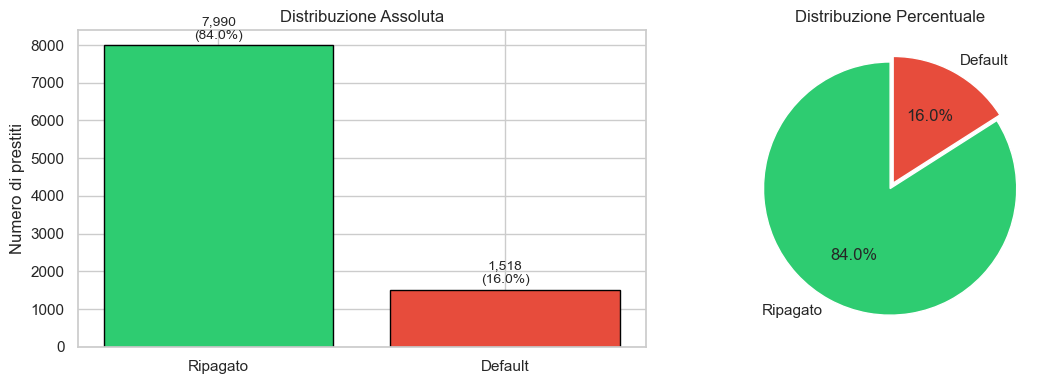


Implicazioni per la modellazione:
--------------------------------------------------
Lo sbilanciamento richiede attenzione nella scelta delle metriche.
Accuracy da sola non e' sufficiente; useremo anche Precision, Recall e F1-Score.


In [340]:
# Analisi dello sbilanciamento delle classi
class_counts = data['not_fully_paid'].value_counts()
class_percentages = data['not_fully_paid'].value_counts(normalize=True) * 100

print("Distribuzione della variabile target 'not_fully_paid':")
print("=" * 50)
print(f"Prestiti ripagati (0):    {class_counts[0]:,} ({class_percentages[0]:.1f}%)")
print(f"Prestiti in default (1):  {class_counts[1]:,} ({class_percentages[1]:.1f}%)")
print(f"Rapporto di sbilanciamento: {class_counts[0]/class_counts[1]:.1f}:1")

# Visualizzazione
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafico a barre
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Ripagato', 'Default'], class_counts.values, color=colors, edgecolor='black')
axes[0].set_ylabel('Numero di prestiti')
axes[0].set_title('Distribuzione Assoluta')
for bar, count, pct in zip(bars, class_counts.values, class_percentages.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# Grafico a torta
axes[1].pie(class_counts.values, labels=['Ripagato', 'Default'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Distribuzione Percentuale')

plt.tight_layout()
plt.show()

print("\nImplicazioni per la modellazione:")
print("-" * 50)
print("Lo sbilanciamento richiede attenzione nella scelta delle metriche.")
print("Accuracy da sola non e' sufficiente; useremo anche Precision, Recall e F1-Score.")

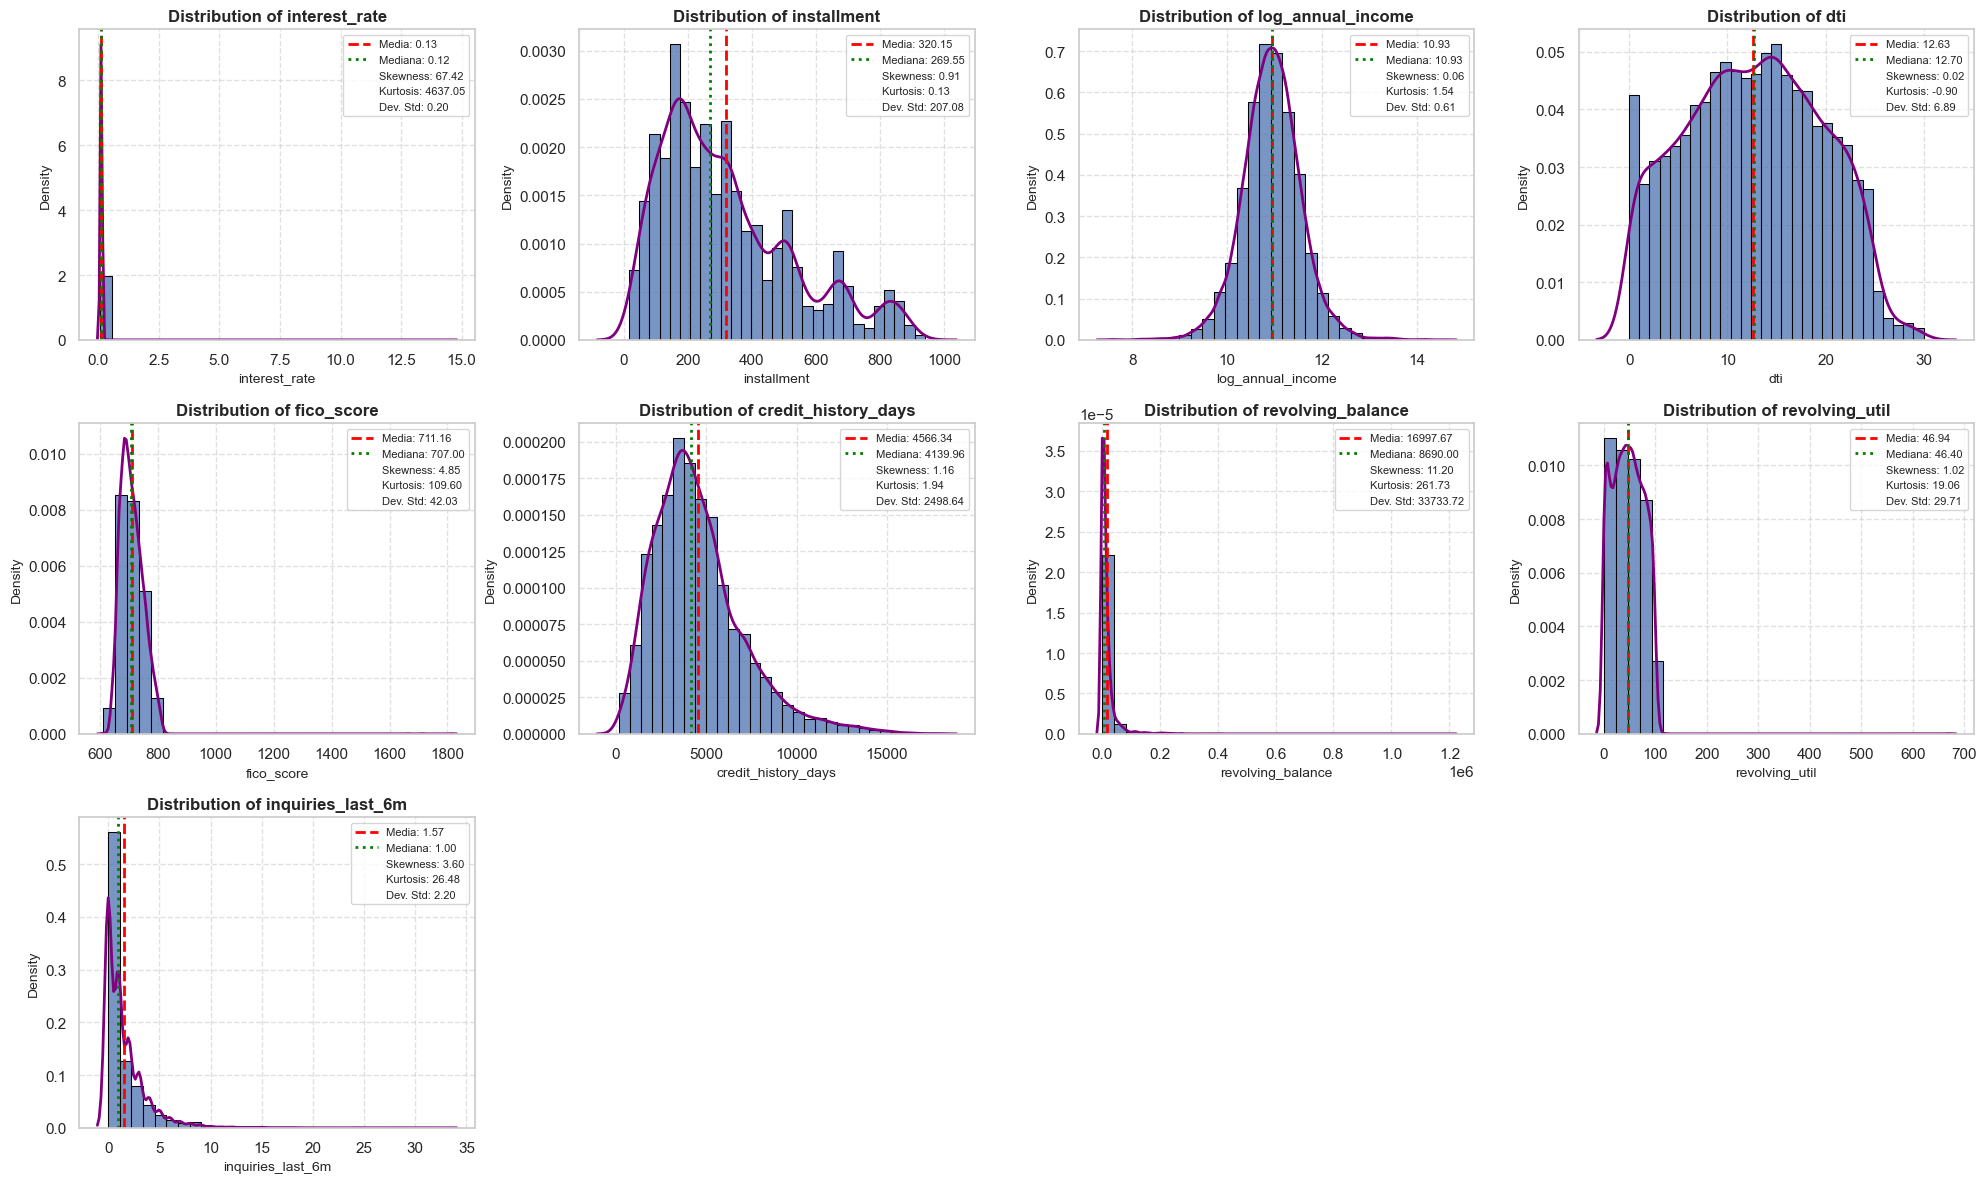

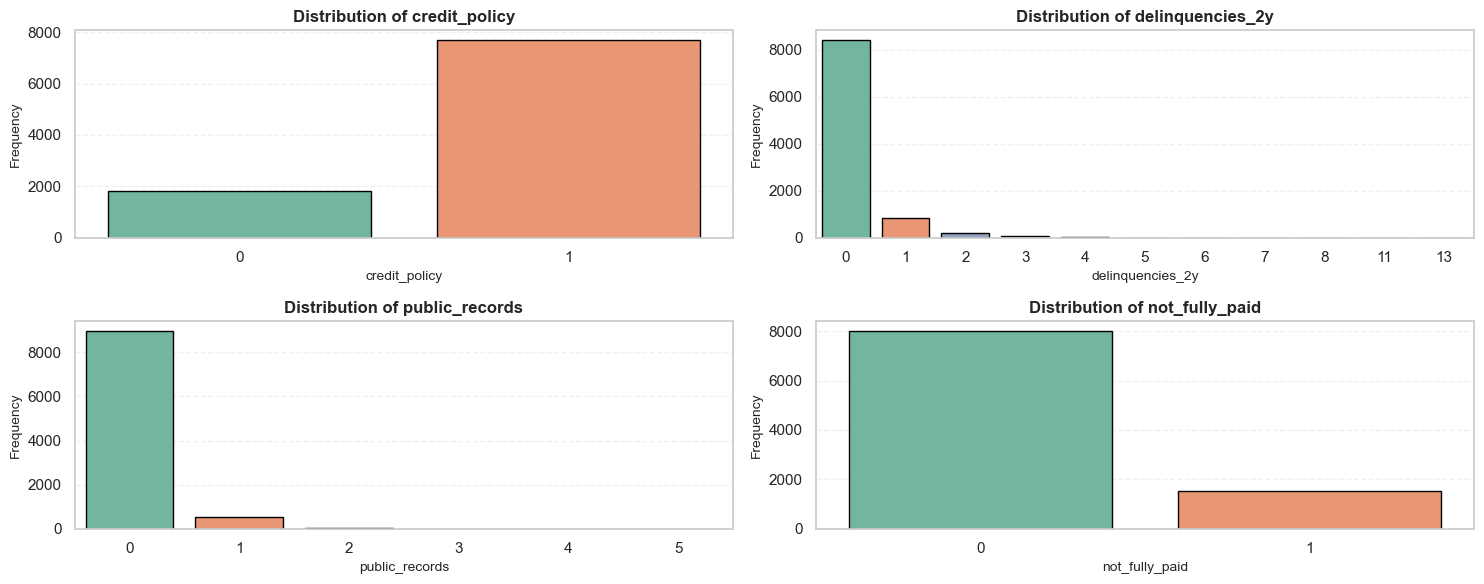

In [341]:

# Separiamo colonne continue e discrete
numeric_cols = data.select_dtypes(include=[np.number]).columns.drop('customer_id')
discrete_cols = ['credit_policy', 'delinquencies_2y', 'public_records', 'not_fully_paid']
continuous_cols = [col for col in numeric_cols if col not in discrete_cols]

# Griglia per variabili CONTINUE (istogramma + KDE)
n_cols_cont = len(continuous_cols)
n_rows_cont = int(np.ceil(n_cols_cont / 4))

plt.figure(figsize=(20, n_rows_cont * 4))

for i, col in enumerate(continuous_cols):
    plt.subplot(n_rows_cont, 4, i+1)
    vals = data[col].dropna()
    bins = np.linspace(vals.min(), vals.max(), 30)

    ax = sns.histplot(vals, bins=bins, edgecolor="black", stat='density', kde=False)
    sns.kdeplot(vals, color='purple', lw=2, ax=ax)

    plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold')

    # Calcoliamo le statistiche
    mean_val = vals.mean()
    median_val = vals.median()
    skew_val = vals.skew()
    kurt_val = vals.kurt()
    std_val = vals.std()

    # Linee verticali per media e mediana
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle=':', linewidth=2, label=f'Mediana: {median_val:.2f}')

    # Statistiche nella legenda
    plt.plot([], [], ' ', label=f'Skewness: {skew_val:.2f}')
    plt.plot([], [], ' ', label=f'Kurtosis: {kurt_val:.2f}')
    plt.plot([], [], ' ', label=f'Dev. Std: {std_val:.2f}')

    plt.legend(fontsize=8, loc='best')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Density', fontsize=10)

plt.tight_layout()
plt.show()

# Griglia per variabili DISCRETE (bar plot)
n_cols_disc = len(discrete_cols)
n_rows_disc = int(np.ceil(n_cols_disc / 2))

plt.figure(figsize=(15, n_rows_disc * 3))

for i, col in enumerate(discrete_cols):
    plt.subplot(n_rows_disc, 2, i+1)
    sns.countplot(data=data, x=col, hue=col, palette='Set2', legend=False, edgecolor="black")
    plt.title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

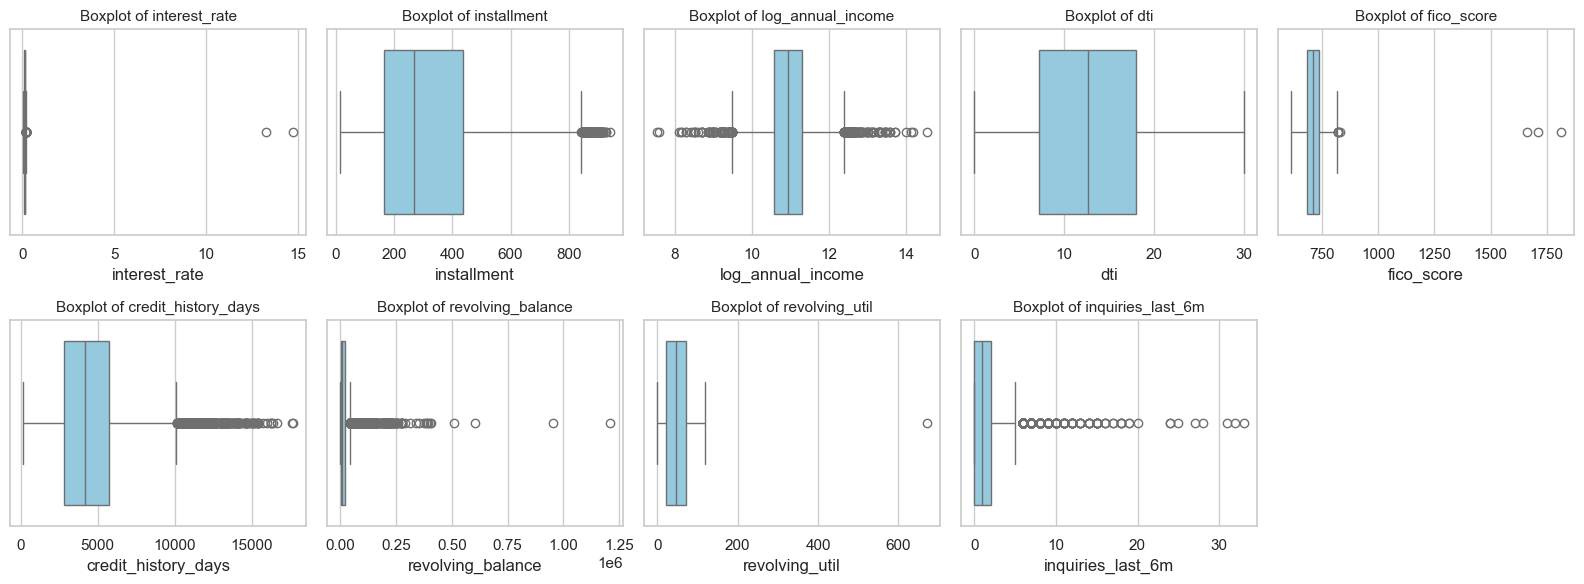

In [342]:
plt.figure(figsize=(16, 6))
for idx, col in enumerate(continuous_cols):
    plt.subplot(2, int(np.ceil(len(continuous_cols)/2)), idx+1)
    sns.boxplot(data=data, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=11)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

<a id="interest-rate-dist"></a>
## Quanto costa prendere un prestito?

**Domanda**: Come sono distribuiti i tassi di interesse? Ci sono valori sospetti?

Il tasso di interesse e una variabile cruciale: rappresenta il "prezzo" del prestito per il cliente e riflette il rischio percepito dalla piattaforma. Tassi alti indicano clienti considerati rischiosi.

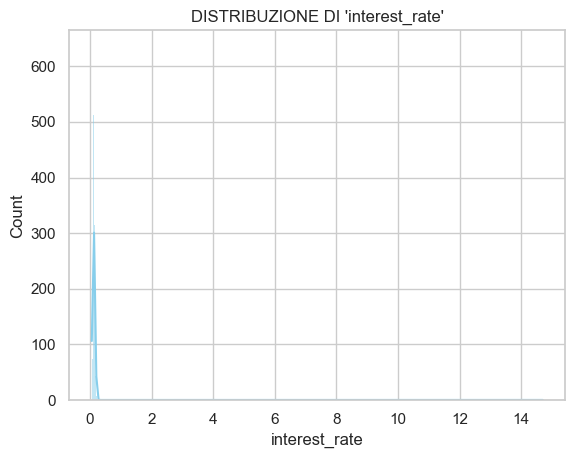

count    9508.000000
mean        0.125583
std         0.202949
min         0.060000
25%         0.103900
50%         0.122100
75%         0.140700
max        14.700000
Name: interest_rate, dtype: float64


In [343]:
sns.histplot(data=data, x='interest_rate', kde=True, color='skyblue')
plt.title("DISTRIBUZIONE DI 'interest_rate'")
plt.show()

print(data['interest_rate'].describe())


Il boxplot evidenzia immediatamente la presenza di valori anomali. Alcuni tassi sono troppo bassi o troppo alti per essere credibili.

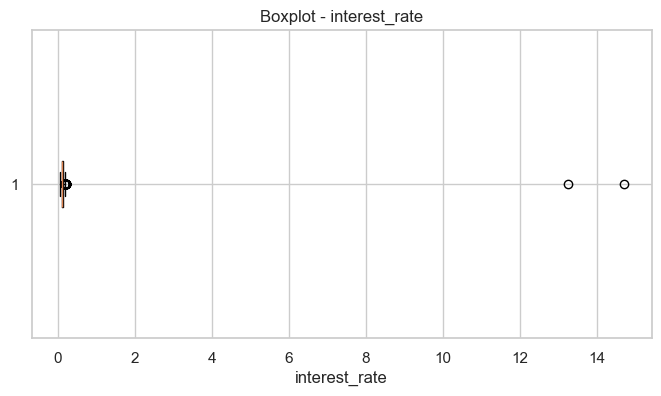

In [344]:
plt.figure(figsize=(8,4))
plt.boxplot(data['interest_rate'], vert=False)
plt.title('Boxplot - interest_rate')
plt.xlabel('interest_rate')
plt.show()

Notiamo valori molto vicini allo zero e altri che arrivano a 14. Questo suggerisce che i tassi potrebbero essere in formato decimale (0.12 invece di 12%). Verifichiamo e correggiamo il problema.

In [345]:
mask_decimal = data['interest_rate'] <= 1
n_corrected = mask_decimal.sum()

if n_corrected > 0:
    print(f"Conversione in corso: trovati {n_corrected} valori in scala decimale (<= 1).")
    data.loc[mask_decimal, 'interest_rate'] = data['interest_rate'] * 100
    print("Conversione completata: ora tutti i valori sono in scala percentuale (0-100).")
else:
    print("Nessun valore in scala decimale (<= 1) trovato. I dati sembrano già in percentuale.")

print("\nStatistiche post-conversione:")
print(data['interest_rate'].describe())

Q1 = data['interest_rate'].quantile(0.25)
Q3 = data['interest_rate'].quantile(0.75)
IQR = Q3 -Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Limite inferiore: {lower_bound:.4f}')
print(f'Limite superiore: {upper_bound:.4f}')

Conversione in corso: trovati 9506 valori in scala decimale (<= 1).
Conversione completata: ora tutti i valori sono in scala percentuale (0-100).

Statistiche post-conversione:
count    9508.000000
mean       12.267296
std         2.681129
min         6.000000
25%        10.390000
50%        12.210000
75%        14.070000
max        21.640000
Name: interest_rate, dtype: float64
Limite inferiore: 4.8700
Limite superiore: 19.5900


I limiti calcolati con il metodo IQR (range interquartile) identificano l'intervallo dei valori "normali". Tutto cio che esce da questo intervallo viene considerato outlier.

In [346]:
lower_outlier = data[data['interest_rate'] < lower_bound]

# Filtrare gli upper outliers
upper_outlier = data[data['interest_rate'] > upper_bound]

print("Numero di lower outliers:", len(lower_outlier))
print("Numero di upper outliers:", len(upper_outlier))

Numero di lower outliers: 0
Numero di upper outliers: 51


In [347]:
outliers = data[(data['interest_rate'] < lower_bound) | (data['interest_rate'] > upper_bound)]
print(f'NUMERO DI OUTLIERS TROVATI : {outliers.shape[0]}')

NUMERO DI OUTLIERS TROVATI : 51


In [348]:
print("Esempi di outlier:")
print(outliers['interest_rate'].head())

Esempi di outlier:
2945    20.86
3713    20.11
3991    20.11
4064    19.79
4731    20.17
Name: interest_rate, dtype: float64


### Pulizia degli outlier

Rimuoviamo i valori anomali per ottenere una distribuzione piu rappresentativa della realta dei prestiti.

In [349]:
total_count = len(data)
outliers_count = len(outliers)

# Applichiamo il filtro direttamente a 'data' invece di creare un nuovo DataFrame
data = data[(data['interest_rate'] >= lower_bound) & (data['interest_rate'] <= upper_bound)]
print(f'DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : {data.shape[0]} righe')

cleaned_count = len(data)
removed_percentage = (outliers_count / total_count) * 100

print(f"Percentuale di outliers rimossi: {removed_percentage:.2f}%")

DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : 9457 righe
Percentuale di outliers rimossi: 0.54%


La perdita di dati e minima ma il dataset e ora piu pulito e affidabile.

### Cosa abbiamo trovato?

Visualizziamo la distribuzione pulita insieme alle principali statistiche descrittive: media, mediana, deviazione standard, asimmetria (skewness) e curtosi (kurtosis).

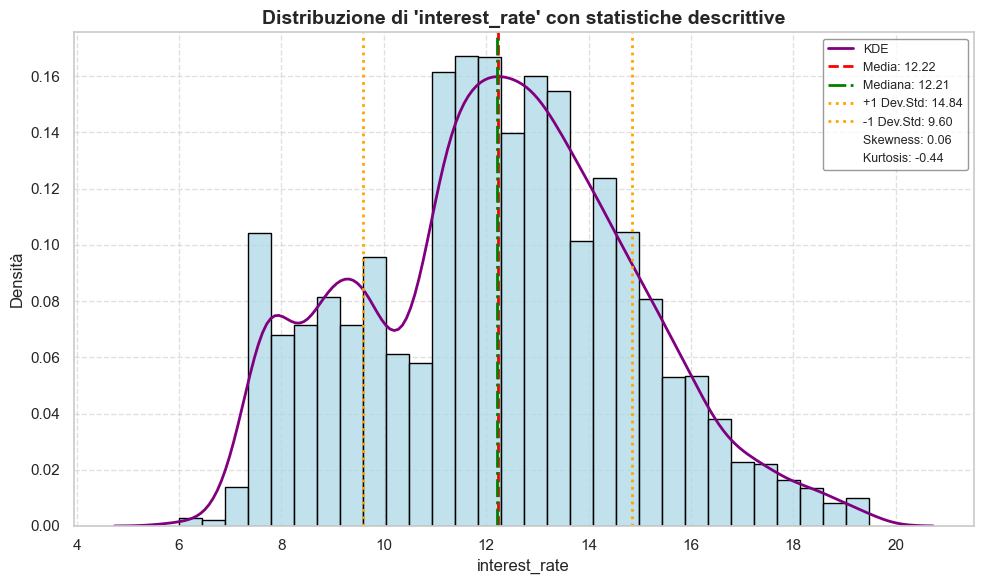

In [350]:
colonna = 'interest_rate'

vals = data[colonna].dropna()

mean_dc = vals.mean()
median_dc = vals.median()
skewness = vals.skew()
kurtosis = vals.kurt()
std_dc = vals.std()


plt.figure(figsize=(10, 6))

sns.histplot(vals, bins=30, color='lightblue', edgecolor='black', stat='density', kde=False)
sns.kdeplot(vals, color='purple', lw=2, label='KDE')

plt.axvline(mean_dc, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_dc:.2f}')
plt.axvline(median_dc, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {median_dc:.2f}')
plt.axvline(mean_dc + std_dc, color='orange', linestyle=':', linewidth=2, label=f'+1 Dev.Std: {(mean_dc + std_dc):.2f}')
plt.axvline(mean_dc - std_dc, color='orange', linestyle=':', linewidth=2, label=f'-1 Dev.Std: {(mean_dc - std_dc):.2f}')

plt.plot([], [], ' ', label=f'Skewness: {skewness:.2f}')
plt.plot([], [], ' ', label=f'Kurtosis: {kurtosis:.2f}')

plt.title(f"Distribuzione di '{colonna}' con statistiche descrittive", fontsize=14, fontweight='bold')
plt.xlabel(colonna, fontsize=12)
plt.ylabel("Densità", fontsize=12)
plt.legend(fontsize=9, loc='best', frameon=True, facecolor='white', edgecolor='gray')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

**Risposta**: Il tasso di interesse medio e circa 12.5%, con la maggior parte dei prestiti tra 10% e 14%. Tassi sopra il 20% sono rari, sotto il 6% sono eccezioni riservate a clienti con profilo creditizio eccellente.

La distribuzione e approssimativamente simmetrica, il che indica che LendingClub applica tassi abbastanza standardizzati con variazioni legate al profilo di rischio del cliente.

### Cosa abbiamo imparato sui tassi di interesse

**Prima della pulizia**: la distribuzione era fortemente sbilanciata a causa di valori estremi, probabilmente errori di inserimento o problemi di formato.

**Dopo la pulizia**: distribuzione simmetrica centrata sul 12.2%, con deviazione standard di circa 2.6%. I tassi sono ora omogenei e realistici per un mercato di prestiti consumer.

Questo ci conferma che la piattaforma applica una politica di pricing ragionevolmente uniforme, con aggiustamenti basati sul rischio individuale.

<a id="installment-analisi"></a>
## Quanto pagano i clienti ogni mese?

**Domanda**: Come sono distribuite le rate mensili?

La rata dipende dall'importo del prestito, dalla durata e dal tasso di interesse. Ci aspettiamo una distribuzione sbilanciata verso destra, con molte rate basse e poche rate alte.

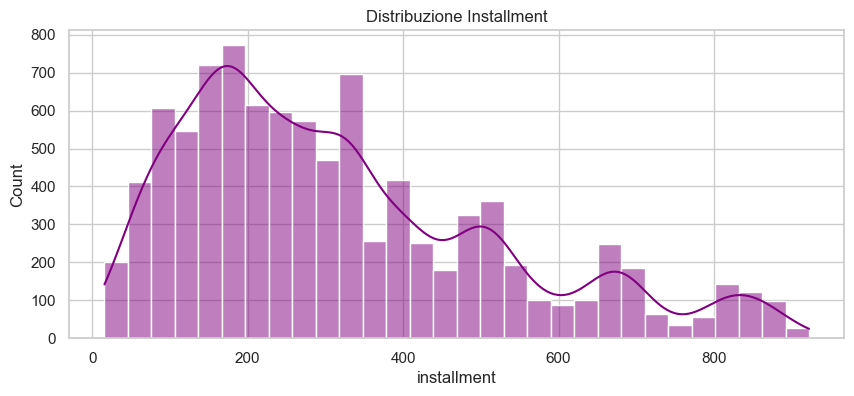

STATISTICHE DESCRITTIVE:

count    9457.000000
mean      319.212909
std       206.120064
min        15.670000
25%       164.020000
50%       269.070000
75%       432.260000
max       922.420000
Name: installment, dtype: float64


In [351]:
plt.figure(figsize=(10,4))
sns.histplot(data['installment'], kde=True, bins = 30, color='purple')
plt.title('Distribuzione Installment')
plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['installment'].describe())

Il boxplot identifica valori che il metodo statistico considera "anomali".

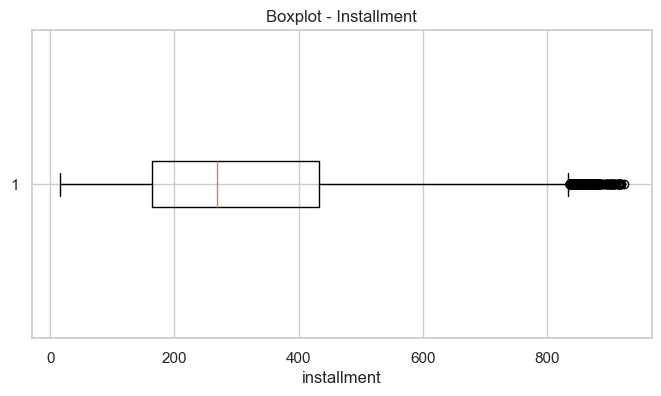

In [352]:
plt.figure(figsize=(8,4))
plt.boxplot(data['installment'], vert=False)
plt.title('Boxplot - Installment')
plt.xlabel('installment')
plt.show()

Calcoliamo i limiti statistici per identificare gli outlier.

In [353]:
Q1 = data['installment'].quantile(0.25)
Q3 = data['installment'].quantile(0.75)
IQR = Q3 - Q1

lowerBound = Q1 - 1.5 * IQR
upperBound = Q3 + 1.5* IQR

print(f'Limite Inferiore: {lowerBound:.2f}')
print(f'Limite Superire: {upperBound:.2f}')



Limite Inferiore: -238.34
Limite Superire: 834.62


Quanti outlier troviamo?

In [354]:
# Filtrare i lower outliers classici (valori bassi estremi)
lower_outliers = data[data['installment'] < lowerBound]

# Filtrare gli upper outliers
upper_outliers = data[data['installment'] > upperBound]

print("Numero di lower outliers:", len(lower_outliers))
print("Numero di upper outliers:", len(upper_outliers))

Numero di lower outliers: 0
Numero di upper outliers: 234


In [355]:
all_outliers = data[(data['installment'] < lowerBound) | (data['installment'] > upperBound)]

print("Numero totale di outlier :", all_outliers.shape[0])

Numero totale di outlier : 234


In [356]:
all_outliers = data[(data['installment'] < lowerBound) | (data['installment'] > upperBound)]
print("Esempi di outlier:")
print(all_outliers[['installment','dti', 'customer_id']].head())

Esempi di outlier:
     installment    dti  customer_id
160       839.95  24.85        10161
237       859.07  20.79        10238
246       836.23   7.99        10247
249       842.47  12.81        10250
271       862.97   5.79        10272


**Attenzione**: le rate alte (es. 842 euro) vengono segnalate come outlier dal metodo IQR, ma non sono errori. Rappresentano semplicemente prestiti di importo maggiore. Non le rimuoviamo perche sono dati legittimi, non anomalie.

### Forma della distribuzione

Esaminiamo asimmetria (skewness) e curtosi (kurtosis) per capire quanto la distribuzione si discosta da una normale.

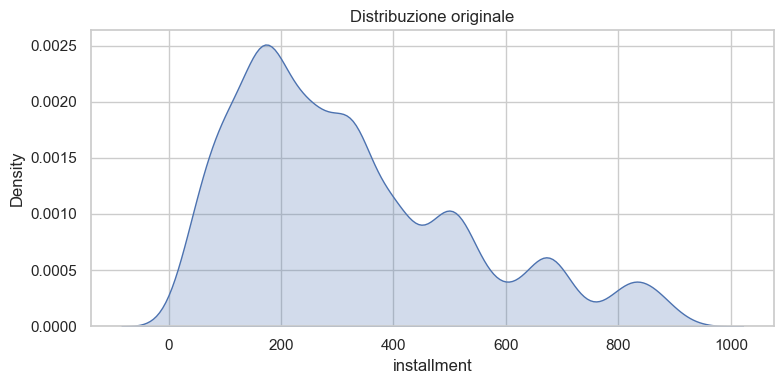


INSTALLMENT
Asimmetria_Skewness: 0.91 | Kurtosis: 0.14


In [357]:
sns.set_theme(style="whitegrid")

skew = data['installment'].skew()
kurt = data['installment'].kurt()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
sns.kdeplot(data['installment'], ax = axes, fill=True)
axes.set_title('Distribuzione originale')


plt.tight_layout()
plt.show()

for col in ['installment']:
    print(f"\n{col.upper()}")
    print(f"Asimmetria_Skewness: {data[col].skew():.2f} | Kurtosis: {data[col].kurt():.2f}")

**Risposta**: La distribuzione e leggermente sbilanciata verso destra (skewness positiva), confermando che ci sono piu rate basse che alte. La curtosi indica una forma simile alla normale ma con code leggermente piu pesanti, quindi qualche valore estremo e presente.

<a id="credit_history_days"></a>
## Da quanto tempo i clienti hanno una storia creditizia?

**Domanda**: L'anzianita della storia creditizia influenza il rischio?

Questa variabile misura da quanti giorni il cliente ha una storia creditizia attiva. In teoria, una storia piu lunga fornisce piu dati alla banca per valutare l'affidabilita.

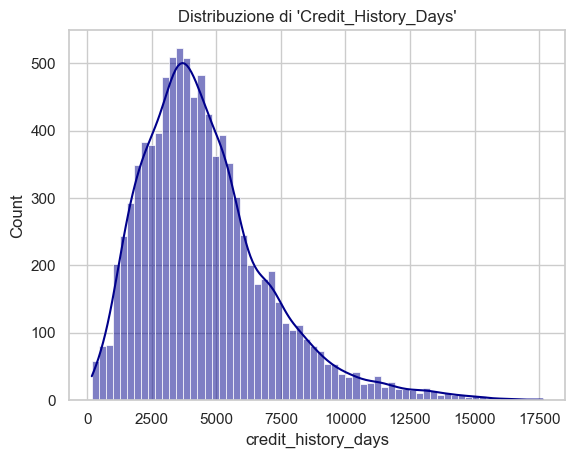

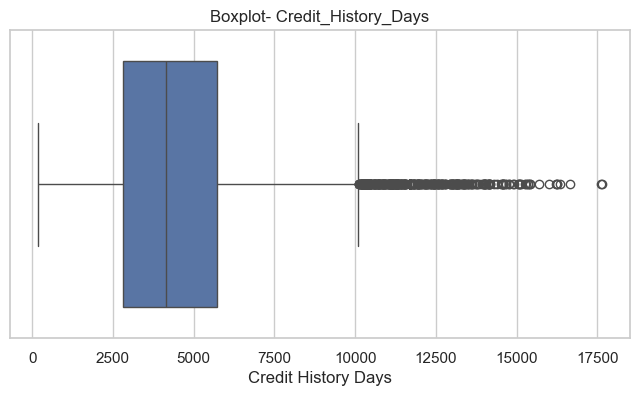

count     9457.000000
mean      4569.165191
std       2496.544737
min        180.041667
25%       2820.041667
50%       4139.958333
75%       5730.041667
max      17639.958330
Name: credit_history_days, dtype: float64

Skewness: 1.1600
Kurtosis: 1.9480


In [358]:
sns.histplot (data = data, x ='credit_history_days', kde = True, color = 'darkblue')
plt.title("Distribuzione di 'Credit_History_Days'")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x = data['credit_history_days'])
plt.title('Boxplot- Credit_History_Days')
plt.xlabel('Credit History Days')
plt.show()

print(data['credit_history_days'].describe())

print(f"\nSkewness: {data['credit_history_days'].skew():.4f}")
print(f"Kurtosis: {data['credit_history_days'].kurt():.4f}")


### Conversione in anni

I giorni sono poco intuitivi, convertiamoli in anni per una lettura piu immediata:
- 0-5 anni: clienti giovani o nuovi al credito
- 5-20 anni: esperienza normale
- 20-35 anni: clienti con lunga esperienza
- oltre 45 anni: valore sospetto, da verificare

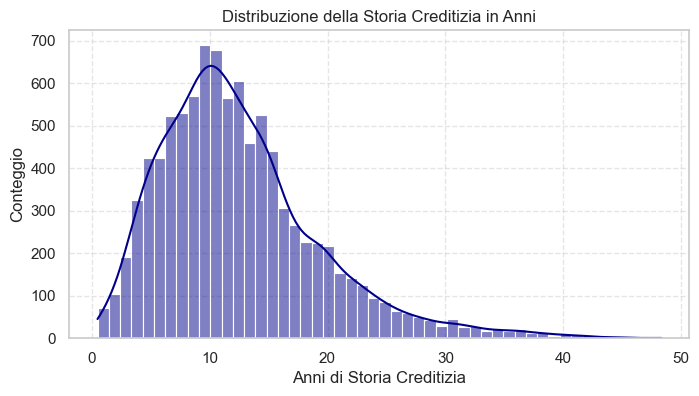

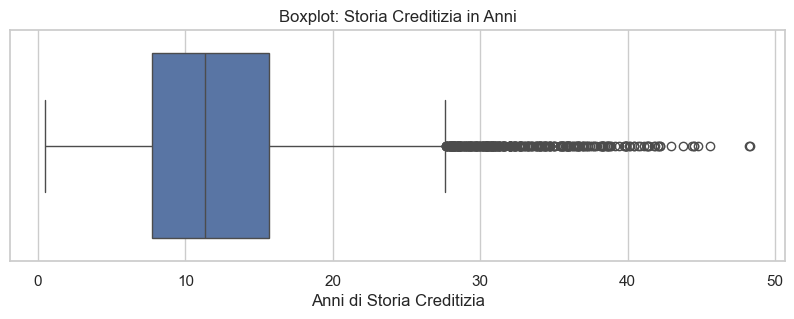

count    9457.000000
mean       12.509693
std         6.835167
min         0.492927
25%         7.720853
50%        11.334588
75%        15.687999
max        48.295574
Name: credit_history_years, dtype: float64

Skewness: 1.1600
Kurtosis: 1.9480


In [359]:
data['credit_history_years'] = data['credit_history_days'] / 365.25

plt.figure(figsize=(8,4))
sns.histplot(data['credit_history_years'], kde=True, bins=50, color = 'darkblue')
plt.title('Distribuzione della Storia Creditizia in Anni')
plt.xlabel('Anni di Storia Creditizia')
plt.ylabel('Conteggio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=data['credit_history_years'])
plt.title('Boxplot: Storia Creditizia in Anni')
plt.xlabel('Anni di Storia Creditizia')
plt.show()

print(data['credit_history_years'].describe())

print(f"\nSkewness: {data['credit_history_days'].skew():.4f}")
print(f"Kurtosis: {data['credit_history_days'].kurt():.4f}")

In [360]:
Q1 = data['credit_history_years'].quantile(0.25)
Q3 = data['credit_history_years'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_chd = Q1 - 1.5 * IQR
upper_bound_chd = Q3 + 1.5 * IQR

print(f'Limite Inferiore: {lower_bound_chd:.4f}')
print(f'Limite Superiore: {upper_bound_chd:.4f}')

Limite Inferiore: -4.2299
Limite Superiore: 27.6387


Il metodo IQR suggerirebbe un limite di circa 28 anni, ma e troppo restrittivo. Nella realta, 45 anni di storia creditizia sono il massimo plausibile: richiederebbe aver aperto un conto a 18 anni ed essere ora oltre i 60. Usiamo 45 anni come soglia ragionevole.

In [361]:
upper_limit = 45
outliers = data[data['credit_history_years'] > upper_limit]
df_clean = data[data['credit_history_years'] <= upper_limit]

print('Numero di outlier sopra i 45 anni:', len(outliers))

Numero di outlier sopra i 45 anni: 3


In [362]:
print('Outliers nel dataset:')
print(outliers['credit_history_years'].head())

Outliers nel dataset:
5801    45.590691
7553    48.229979
8430    48.295574
Name: credit_history_years, dtype: float64


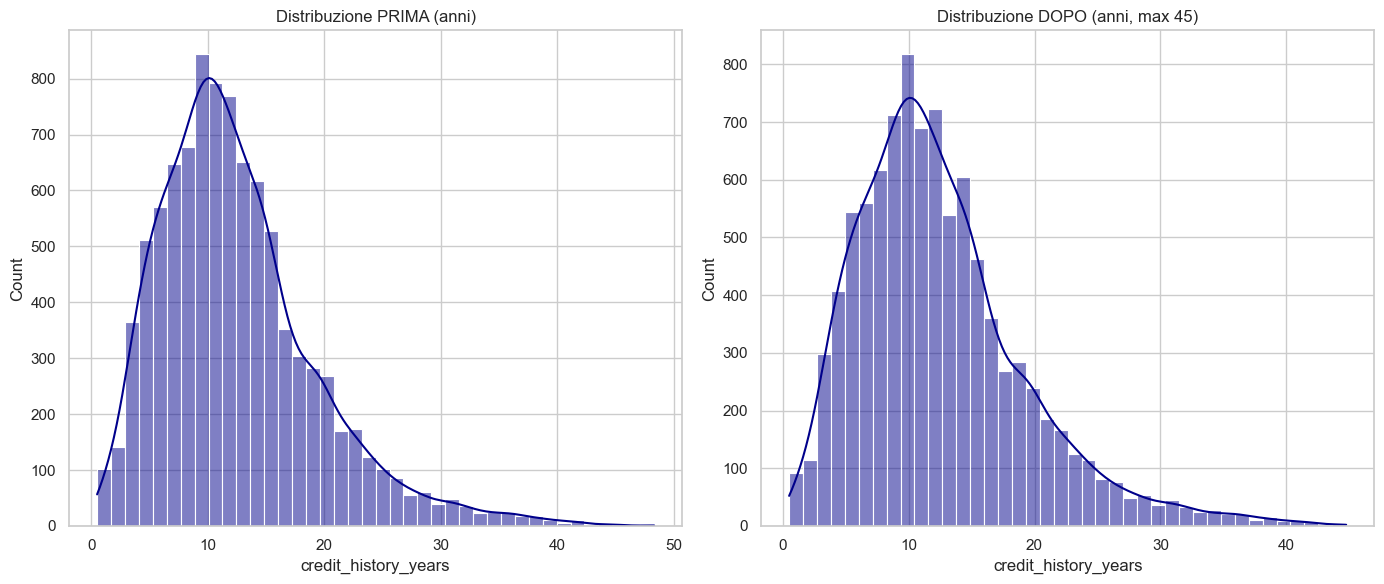

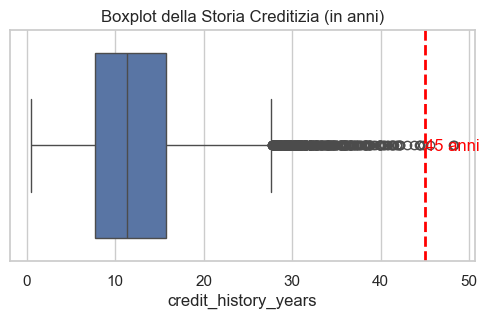

count    9454.000000
mean       12.498630
std         6.807936
min         0.492927
25%         7.720853
50%        11.334588
75%        15.687999
max        44.763860
Name: credit_history_years, dtype: float64

Skewness: 1.1365
Kurtosis: 1.8166


In [363]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data["credit_history_years"], kde=True, bins=40, color = 'darkblue')
plt.title("Distribuzione PRIMA (anni)")
plt.xlabel("credit_history_years")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(df_clean["credit_history_years"], kde=True, bins=40, color = 'darkblue')
plt.title("Distribuzione DOPO (anni, max 45)")
plt.xlabel("credit_history_years")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=data["credit_history_years"])
plt.title("Boxplot della Storia Creditizia (in anni)")


plt.axvline(x=45, color='red', linestyle='--', linewidth=2)
plt.text(45, 0.02, "45 anni", color='red')

plt.xlabel("credit_history_years")
plt.show()


print(df_clean['credit_history_years'].describe())

print(f"\nSkewness: {df_clean['credit_history_years'].skew():.4f}")
print(f"Kurtosis: {df_clean['credit_history_years'].kurt():.4f}")

**Risposta**: Abbiamo rimosso pochissimi record (0.03%). La distribuzione rimane sbilanciata verso destra, il che e normale: la maggior parte dei clienti ha storie creditizie di durata media, mentre solo pochi hanno storie molto lunghe.

<a id="fico-score"></a>
## Quanto sono affidabili i nostri clienti?

**Domanda**: Come sono distribuiti i punteggi FICO? Che tipo di clientela attrae LendingClub?

Il FICO Score e il numero che sintetizza l'affidabilita creditizia nel mercato americano. La scala va da 300 a 850:
- Sotto 580: pessimo
- 580-669: discreto
- 670-739: buono
- 740-799: molto buono
- Sopra 800: eccellente

Questo punteggio influenza direttamente il tasso di interesse applicato e la probabilita di ottenere il prestito.

In [364]:
print("=== STATISTICHE FICO SCORE ===")
print(data['fico_score'].describe())
print(f"\nSkewness: {data['fico_score'].skew():.4f}")
print(f"Kurtosis: {data['fico_score'].kurt():.4f}")

=== STATISTICHE FICO SCORE ===
count    9457.000000
mean      711.336470
std        42.052375
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max      1812.000000
Name: fico_score, dtype: float64

Skewness: 4.8639
Kurtosis: 109.9192


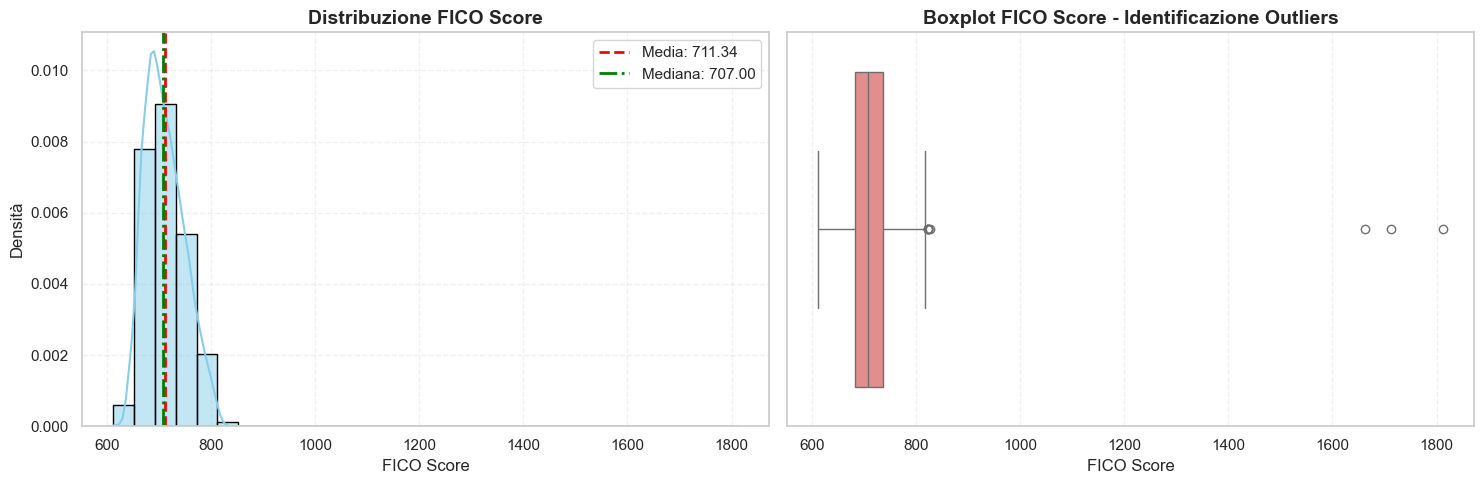

In [365]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Istogramma + KDE
ax1 = axes[0]
sns.histplot(data['fico_score'], bins=30, kde=True, color='skyblue', edgecolor='black', ax=ax1, stat='density')
ax1.axvline(data['fico_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data["fico_score"].mean():.2f}')
ax1.axvline(data['fico_score'].median(), color='green', linestyle='-.', linewidth=2, label=f'Mediana: {data["fico_score"].median():.2f}')
ax1.set_title('Distribuzione FICO Score', fontsize=14, fontweight='bold')
ax1.set_xlabel('FICO Score', fontsize=12)
ax1.set_ylabel('Densità', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)

# Boxplot
ax2 = axes[1]
sns.boxplot(x=data['fico_score'], color='lightcoral', ax=ax2)
ax2.set_title('Boxplot FICO Score - Identificazione Outliers', fontsize=14, fontweight='bold')
ax2.set_xlabel('FICO Score', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [366]:
# Identificazione outliers per FICO Score
Q1_fico = data['fico_score'].quantile(0.25)
Q3_fico = data['fico_score'].quantile(0.75)
IQR_fico = Q3_fico - Q1_fico

lower_bound_fico = Q1_fico - 1.5 * IQR_fico
upper_bound_fico = 851

print(f'Limite inferiore: {lower_bound_fico:.2f}')
print(f'Limite superiore: {upper_bound_fico:.2f}')

outliers_fico = data[(data['fico_score'] < lower_bound_fico) | (data['fico_score'] > upper_bound_fico)]
print(f'\nNUMERO DI OUTLIERS TROVATI: {outliers_fico.shape[0]}')
print(f'Percentuale di outliers: {(outliers_fico.shape[0] / len(data)) * 100:.2f}%')
print(f'Valore massimo FICO Score: {data["fico_score"].max()}')

# Rimozione degli outlier
total_count_fico = len(data)
outliers_count_fico = len(outliers_fico)

print(f'\n{"="*60}')
print(f'PULIZIA FICO SCORE')
print(f'{"="*60}')
print(f'Dimensione dataset PRIMA della pulizia: {total_count_fico} righe')

data = data[(data['fico_score'] >= lower_bound_fico) & (data['fico_score'] <= upper_bound_fico)]

print(f'Dimensione dataset DOPO la pulizia: {len(data)} righe')
print(f'Righe rimosse: {outliers_count_fico}')
print(f'Percentuale rimossa: {(outliers_count_fico / total_count_fico) * 100:.2f}%')

# Nuove statistiche dopo pulizia
print(f'\n{"="*60}')
print("STATISTICHE FICO SCORE DOPO PULIZIA")
print(f'{"="*60}')
print(data['fico_score'].describe())
print(f"\nSkewness: {data['fico_score'].skew():.4f}")
print(f"Kurtosis: {data['fico_score'].kurt():.4f}")
print(f'{"="*60}')
print(data['fico_score'].max())

Limite inferiore: 599.50
Limite superiore: 851.00

NUMERO DI OUTLIERS TROVATI: 3
Percentuale di outliers: 0.03%
Valore massimo FICO Score: 1812

PULIZIA FICO SCORE
Dimensione dataset PRIMA della pulizia: 9457 righe
Dimensione dataset DOPO la pulizia: 9454 righe
Righe rimosse: 3
Percentuale rimossa: 0.03%

STATISTICHE FICO SCORE DOPO PULIZIA
count    9454.000000
mean      711.013645
std        37.936399
min       612.000000
25%       682.000000
50%       707.000000
75%       737.000000
max       827.000000
Name: fico_score, dtype: float64

Skewness: 0.4616
Kurtosis: -0.4306
827


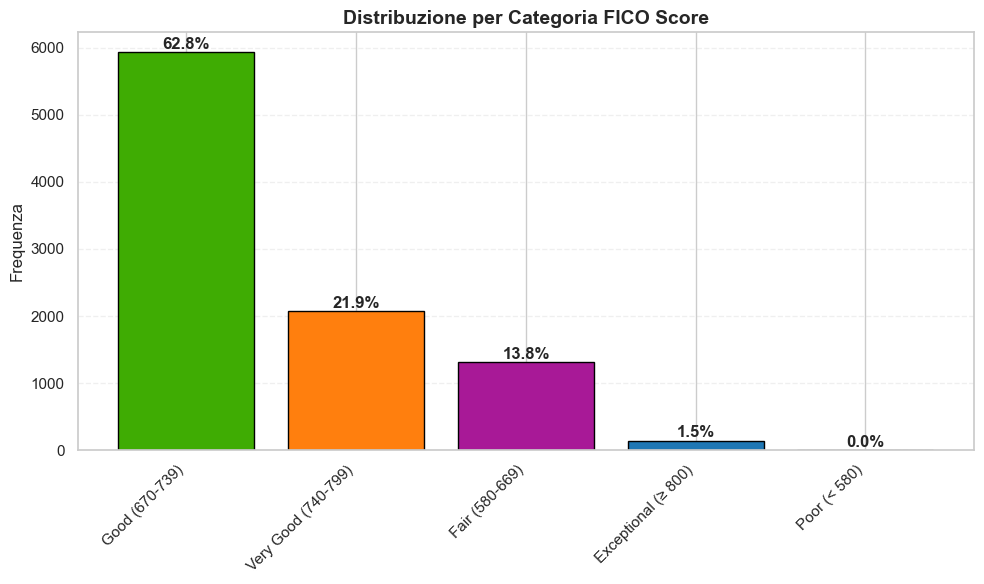


=== DISTRIBUZIONE PER CATEGORIA ===
Good (670-739): 5936 (62.79%)
Very Good (740-799): 2070 (21.90%)
Fair (580-669): 1308 (13.84%)
Exceptional (≥ 800): 140 (1.48%)
Poor (< 580): 0 (0.00%)


In [367]:
def classify_fico(score):
    if score < 580:
        return 'Poor (< 580)'
    elif score < 670:
        return 'Fair (580-669)'
    elif score < 740:
        return 'Good (670-739)'
    elif score < 800:
        return 'Very Good (740-799)'
    else:
        return 'Exceptional (≥ 800)'

data['fico_category'] = data['fico_score'].apply(classify_fico)

category_order = ['Poor (< 580)','Fair (580-669)', 'Good (670-739)', 'Very Good (740-799)', 'Exceptional (≥ 800)']
data['fico_category'] = pd.Categorical(data['fico_category'], categories=category_order, ordered=True)

plt.figure(figsize=(10, 6))

fico_counts = data['fico_category'].value_counts()
colors = ['#3fac03', '#ff7f0e', "#a81997", '#1f77b4', '#9467bd']
plt.bar(range(len(fico_counts)), fico_counts.values, color=colors, edgecolor='black')
plt.xticks(range(len(fico_counts)), fico_counts.index, rotation=45, ha='right')
plt.title('Distribuzione per Categoria FICO Score', fontsize=14, fontweight='bold')
plt.ylabel('Frequenza', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Percentuali
for i, (cat, count) in enumerate(fico_counts.items()):
    pct = (count / len(data)) * 100
    plt.text(i, count + 50, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== DISTRIBUZIONE PER CATEGORIA ===")
for cat, count in fico_counts.items():
    print(f"{cat}: {count} ({(count/len(data))*100:.2f}%)")

<a id="purpose-analisi"></a>
## Perche i clienti chiedono un prestito?

**Domanda**: Quali sono le motivazioni piu comuni? Alcune sono piu rischiose di altre?

La variabile `purpose` indica lo scopo dichiarato del prestito. E interessante vedere se certe motivazioni sono associate a tassi di default piu alti.

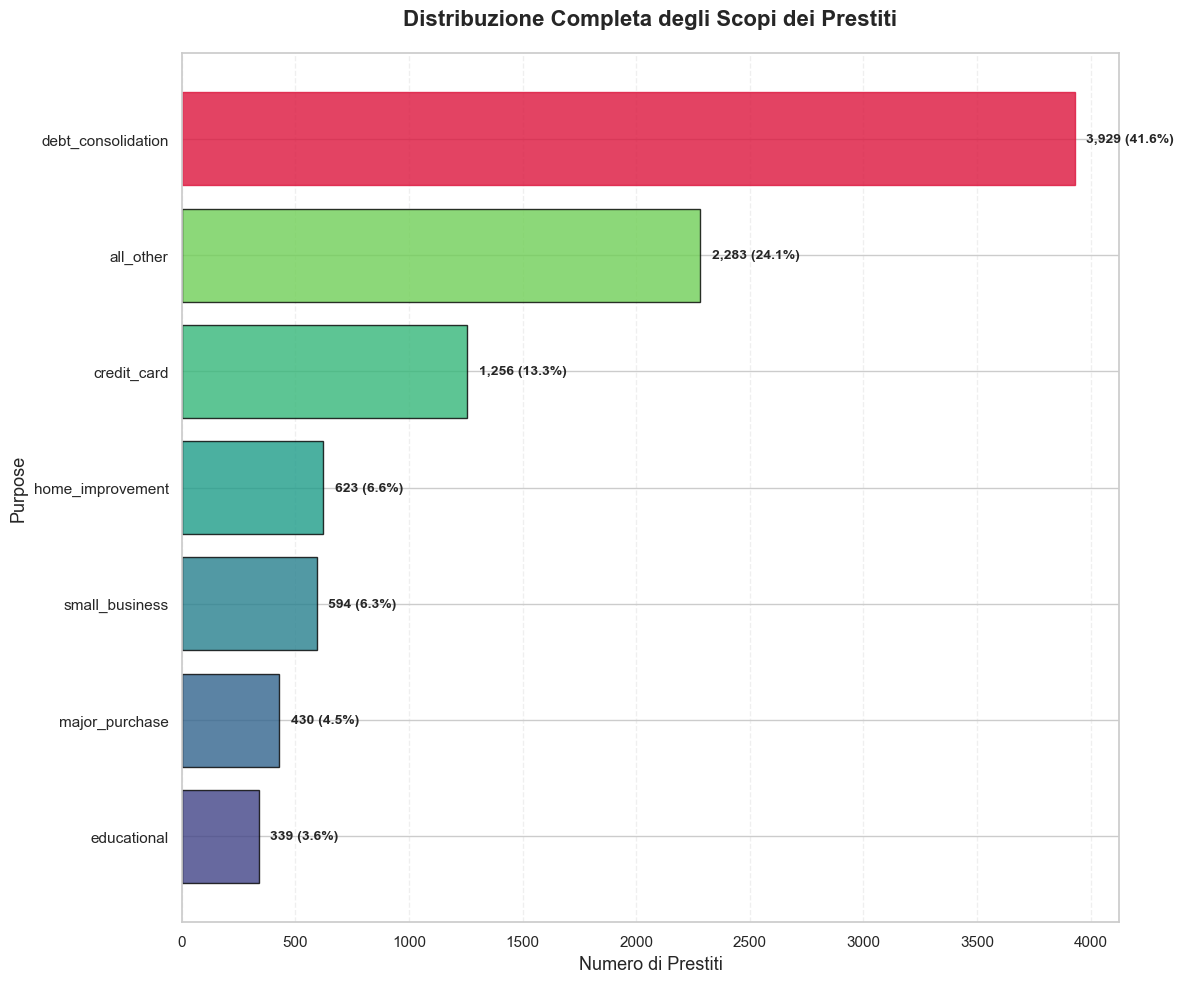


                    STATISTICHE PURPOSE
Purpose                               Count      Percentage
----------------------------------------------------------------------
debt_consolidation                    3,929          41.56%
all_other                             2,283          24.15%
credit_card                           1,256          13.29%
home_improvement                        623           6.59%
small_business                          594           6.28%
major_purchase                          430           4.55%
educational                             339           3.59%
TOTALE                                9,454         100.00%

Numero totale di categorie:         7
Categoria più frequente:            debt_consolidation (3,929 prestiti)
Categoria meno frequente:           educational (339 prestiti)


In [368]:

purpose_counts = data['purpose'].value_counts()
purpose_pct = (purpose_counts / len(data) * 100)

purpose_counts_sorted = purpose_counts.sort_values()

fig, ax = plt.subplots(figsize=(12, 10))

colors_gradient = plt.cm.viridis(np.linspace(0.2, 0.9, len(purpose_counts_sorted)))

bars = ax.barh(range(len(purpose_counts_sorted)),
               purpose_counts_sorted.values,
               color=colors_gradient,
               edgecolor='black',
               alpha=0.8)

# Colora in rosso la barra più alta
max_idx = np.argmax(purpose_counts_sorted.values)
bars[max_idx].set_color('crimson')

# Aggiungi le percentuali alla fine di ogni barra
for i, (purpose, count) in enumerate(purpose_counts_sorted.items()):
    pct = (count / len(data)) * 100
    ax.text(count + 50, i, f'{count:,} ({pct:.1f}%)',
            va='center', fontweight='bold', fontsize=10)

# Imposta le etichette sull'asse Y
ax.set_yticks(range(len(purpose_counts_sorted)))
ax.set_yticklabels(purpose_counts_sorted.index, fontsize=11)

ax.set_title('Distribuzione Completa degli Scopi dei Prestiti',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Numero di Prestiti', fontsize=13)
ax.set_ylabel('Purpose', fontsize=13)

ax.grid(True, linestyle='--', alpha=0.3, axis='x')


plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(" "*20 + "STATISTICHE PURPOSE")
print("="*70)
print(f"{'Purpose':<30} {'Count':>12} {'Percentage':>15}")
print("-"*70)
for purpose, count in purpose_counts.items():
    pct = (count / len(data)) * 100
    print(f"{purpose:<30} {count:>12,} {pct:>14.2f}%")
print("="*70)
print(f"{'TOTALE':<30} {len(data):>12,} {100.0:>14.2f}%")
print("="*70)

# Statistiche aggiuntive
print(f"\n{'Numero totale di categorie:':<35} {len(purpose_counts)}")
print(f"{'Categoria più frequente:':<35} {purpose_counts.index[0]} ({purpose_counts.iloc[0]:,} prestiti)")
print(f"{'Categoria meno frequente:':<35} {purpose_counts.index[-1]} ({purpose_counts.iloc[-1]:,} prestiti)")

<a id="annual-income"></a>
## Quanto guadagnano i clienti?

**Domanda**: Qual e la distribuzione dei redditi? Il reddito e un buon predittore del rischio?

Il reddito e salvato come logaritmo naturale (`log_annual_income`). Lo riconvertiamo per vedere i valori reali in dollari.

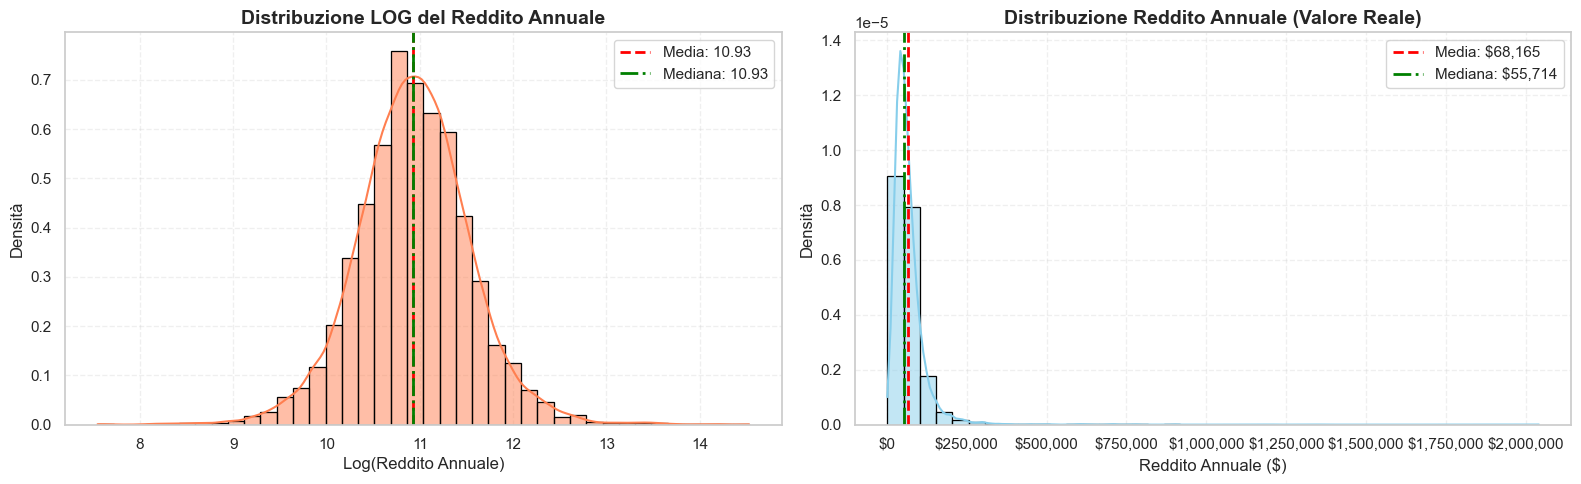


Skewness (Log): 0.0544
Skewness (Reale): 9.8382
min 1896.0000003508226
max 2039784.004362027
mean 68164.73258872403
std 60664.94047772514


In [369]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
data['annual_income'] = np.exp(data['log_annual_income'])

ax1 = axes[0]
sns.histplot(data['log_annual_income'], bins=40, kde=True, color='coral', edgecolor='black', ax=ax1, stat='density')
ax1.axvline(data['log_annual_income'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {data["log_annual_income"].mean():.2f}')
ax1.axvline(data['log_annual_income'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Mediana: {data["log_annual_income"].median():.2f}')
ax1.set_title('Distribuzione LOG del Reddito Annuale', fontsize=14, fontweight='bold')
ax1.set_xlabel('Log(Reddito Annuale)', fontsize=12)
ax1.set_ylabel('Densità', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.3)


ax2 = axes[1]
sns.histplot(data['annual_income'], bins=40, kde=True, color='skyblue', edgecolor='black', ax=ax2, stat='density')
ax2.axvline(data['annual_income'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: ${data["annual_income"].mean():,.0f}')
ax2.axvline(data['annual_income'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Mediana: ${data["annual_income"].median():,.0f}')
ax2.set_title('Distribuzione Reddito Annuale (Valore Reale)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Reddito Annuale ($)', fontsize=12)
ax2.set_ylabel('Densità', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.3)


ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

print(f"\nSkewness (Log): {data['log_annual_income'].skew():.4f}")
print(f"Skewness (Reale): {data['annual_income'].skew():.4f}")

data['annual_income'].describe()
print("min", data['annual_income'].min())
print("max", data['annual_income'].max())
print("mean", data['annual_income'].mean())
print("std", data['annual_income'].std())

<a id="dti-analisi"></a>
## Quanto sono indebitati i clienti?

**Domanda**: Il rapporto debito/reddito (DTI) e un buon indicatore di rischio?

Il DTI (Debt-to-Income) misura quanta parte del reddito mensile va a pagare debiti esistenti.

Formula: DTI = (Debiti Mensili / Reddito Mensile) x 100

Un DTI alto come per esempio il 40%, significa che il 40% dello stipendio va gia in rate. Meno soldi restano per un nuovo prestito, quindi il rischio aumenta.

In [370]:
data_clean_dti = data[(data['dti'] >= lower_bound) & (data['dti'] <= upper_bound)]

print("="*60)
print("CONFRONTO STATISTICHE DTI")
print("="*60)

stats_comparison = pd.DataFrame({
    'Metrica': ['Count', 'Media', 'Mediana', 'Dev. Std', 'Min', 'Q1', 'Q3', 'Max', 'Skewness', 'Kurtosis'],
    'Con Outliers': [
        len(data),
        data['dti'].mean(),
        data['dti'].median(),
        data['dti'].std(),
        data['dti'].min(),
        data['dti'].quantile(0.25),
        data['dti'].quantile(0.75),
        data['dti'].max(),
        data['dti'].skew(),
        data['dti'].kurtosis()
    ],
    'Senza Outliers': [
        len(data_clean_dti),
        data_clean_dti['dti'].mean(),
        data_clean_dti['dti'].median(),
        data_clean_dti['dti'].std(),
        data_clean_dti['dti'].min(),
        data_clean_dti['dti'].quantile(0.25),
        data_clean_dti['dti'].quantile(0.75),
        data_clean_dti['dti'].max(),
        data_clean_dti['dti'].skew(),
        data_clean_dti['dti'].kurtosis()
    ]
})

stats_comparison['Variazione (%)'] = ((stats_comparison['Senza Outliers'] - stats_comparison['Con Outliers']) /
                                       stats_comparison['Con Outliers'] * 100).round(2)

print("\n" + stats_comparison.to_string(index=False))
print("\n" + "="*60)

CONFRONTO STATISTICHE DTI

 Metrica  Con Outliers  Senza Outliers  Variazione (%)
   Count   9454.000000     6154.000000          -34.91
   Media     12.635253       12.339184           -2.34
 Mediana     12.710000       12.420000           -2.28
Dev. Std      6.887045        4.074410          -40.84
     Min      0.000000        4.880000             inf
      Q1      7.232500        8.940000           23.61
      Q3     18.000000       15.720000          -12.67
     Max     29.960000       19.580000          -34.65
Skewness      0.020939       -0.038220         -282.53
Kurtosis     -0.902210       -1.123146           24.49



### Come è distribuito il DTI nel nostro dataset?

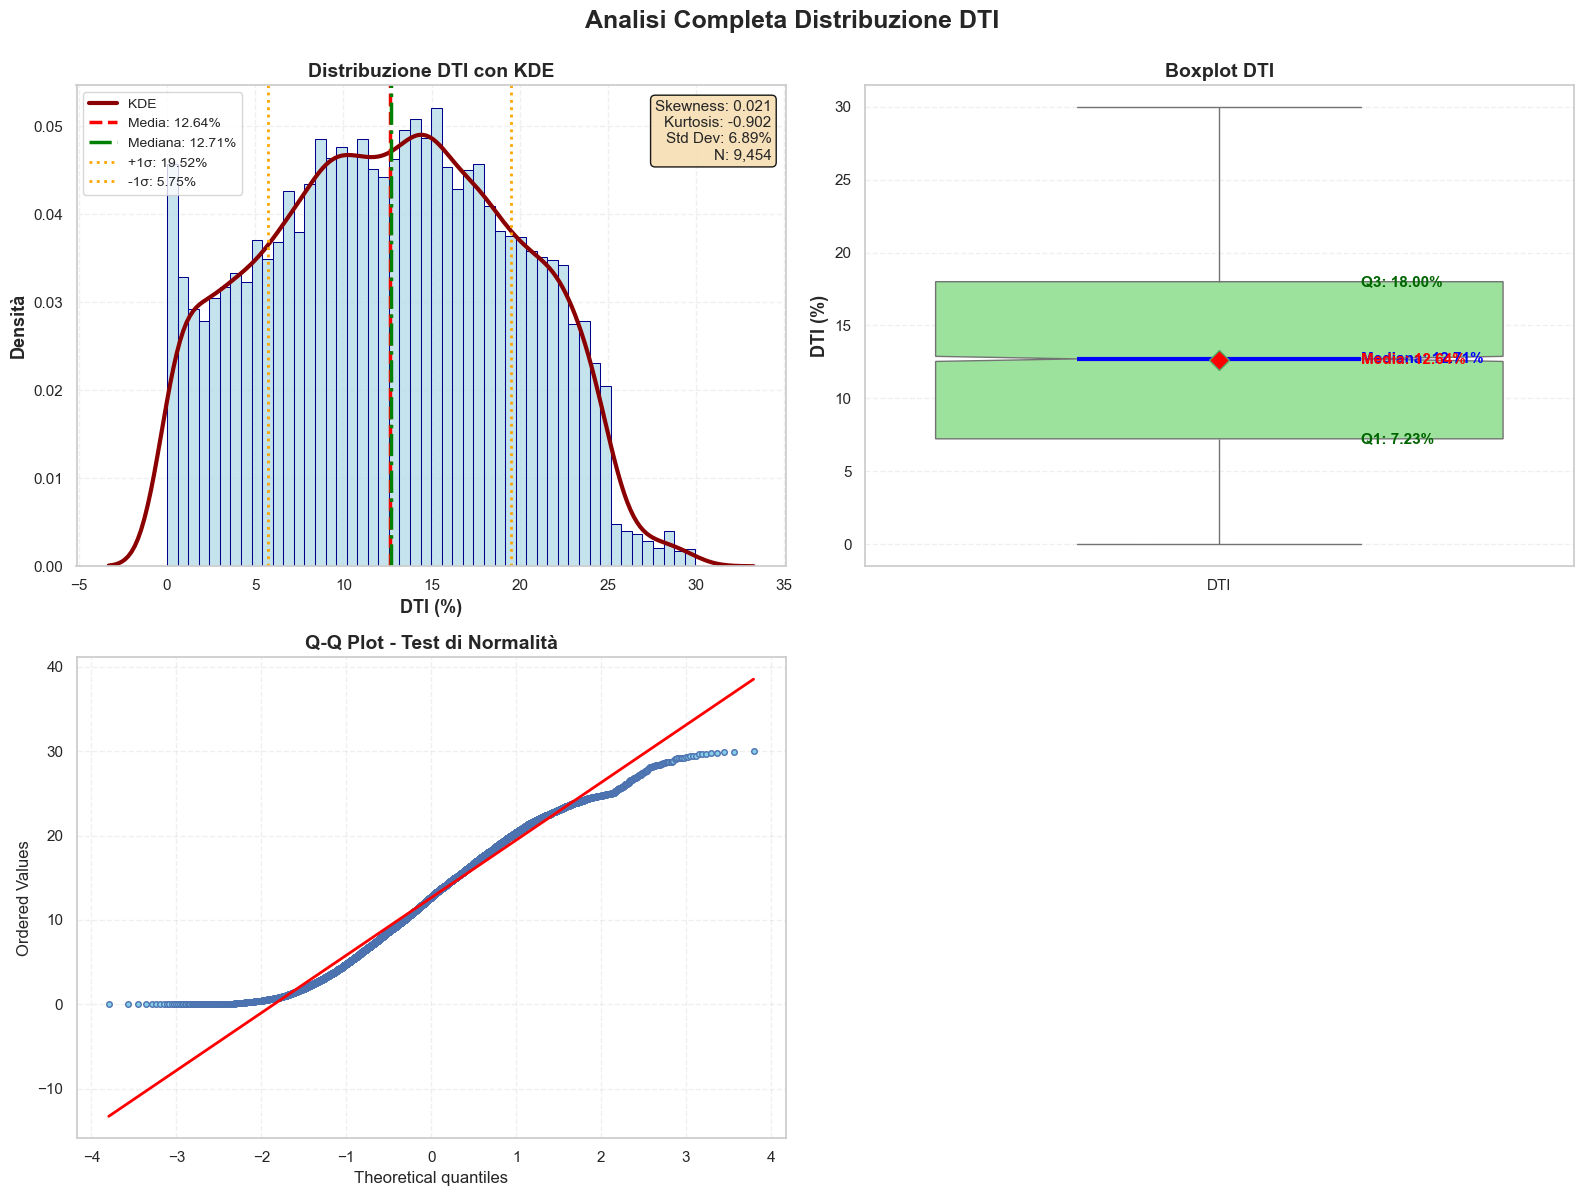

                    STATISTICHE DESCRITTIVE DTI
Media:              12.64%
Mediana:            12.71%
Dev. Standard:      6.89%
Skewness:           0.021
Kurtosis:           -0.902
DTI = 0:            85 (0.8991%)


In [371]:

from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisi Completa Distribuzione DTI', fontsize=18, fontweight='bold', y=0.995)

vals_dti = data['dti'].dropna()
mean_dti = vals_dti.mean()
median_dti = vals_dti.median()
std_dti = vals_dti.std()
skew_dti = vals_dti.skew()
kurt_dti = vals_dti.kurtosis()

sns.histplot(vals_dti, bins=50, color='lightblue', edgecolor='darkblue',
             alpha=0.7, stat='density', kde=False, ax=axes[0, 0])
sns.kdeplot(vals_dti, color='darkred', linewidth=3, ax=axes[0, 0], label='KDE')

axes[0, 0].axvline(mean_dti, color='red', linestyle='--', linewidth=2.5, label=f'Media: {mean_dti:.2f}%')
axes[0, 0].axvline(median_dti, color='green', linestyle='-.', linewidth=2.5, label=f'Mediana: {median_dti:.2f}%')
axes[0, 0].axvline(mean_dti + std_dti, color='orange', linestyle=':', linewidth=2, label=f'+1σ: {(mean_dti + std_dti):.2f}%')
axes[0, 0].axvline(mean_dti - std_dti, color='orange', linestyle=':', linewidth=2, label=f'-1σ: {(mean_dti - std_dti):.2f}%')

textstr = f'Skewness: {skew_dti:.3f}\nKurtosis: {kurt_dti:.3f}\nStd Dev: {std_dti:.2f}%\nN: {len(vals_dti):,}'
axes[0, 0].text(0.98, 0.97, textstr, transform=axes[0, 0].transAxes, fontsize=11,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='black'))

axes[0, 0].set_xlabel('DTI (%)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Densità', fontsize=13, fontweight='bold')
axes[0, 0].set_title('Distribuzione DTI con KDE', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10, loc='upper left')
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

bp = sns.boxplot(y=vals_dti, color='lightgreen', ax=axes[0, 1],
                 notch=True, showmeans=True, showcaps=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=10),
                 medianprops=dict(color='blue', linewidth=3))

q1_dti = vals_dti.quantile(0.25)
q3_dti = vals_dti.quantile(0.75)

axes[0, 1].text(0.2, q1_dti, f'Q1: {q1_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='darkgreen')
axes[0, 1].text(0.2, median_dti, f'Mediana: {median_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='blue')
axes[0, 1].text(0.2, q3_dti, f'Q3: {q3_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='darkgreen')
axes[0, 1].text(0.2, mean_dti, f'Media: {mean_dti:.2f}%', fontsize=11, va='center', fontweight='bold', color='red')

axes[0, 1].set_ylabel('DTI (%)', fontsize=13, fontweight='bold')
axes[0, 1].set_title('Boxplot DTI', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks([0])
axes[0, 1].set_xticklabels(['DTI'])
axes[0, 1].grid(True, alpha=0.3, axis='y', linestyle='--')

sp_stats.probplot(vals_dti, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot - Test di Normalità', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].get_lines()[0].set_markerfacecolor('skyblue')
axes[1, 0].get_lines()[0].set_markersize(4)
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].get_lines()[1].set_linewidth(2)

axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("="*70)
print(" "*20 + "STATISTICHE DESCRITTIVE DTI")
print("="*70)
print(f"Media:              {mean_dti:.2f}%")
print(f"Mediana:            {median_dti:.2f}%")
print(f"Dev. Standard:      {std_dti:.2f}%")
print(f"Skewness:           {skew_dti:.3f}")
print(f"Kurtosis:           {kurt_dti:.3f}")
print(f"DTI = 0:            {len(data[data['dti'] == 0])} ({(len(data[data['dti'] == 0]) / len(data)) * 100:.4f}%)")
print("="*70)

### Quanti clienti hanno DTI pari a zero?

Un DTI uguale a zero significa che il cliente non ha debiti mensili. Se la percentuale fosse troppo alta, potrebbe indicare un problema nei dati.

In [372]:
print(f"Clienti con DTI = 0: {len(data[data['dti'] == 0])}")
print(f"Percentuale: {(len(data[data['dti'] == 0]) / len(data)) * 100:.2f}%")



Clienti con DTI = 0: 85
Percentuale: 0.90%


<a id="revolving-util"></a>
## Quanto credito stanno usando i clienti?

**Domanda**: L'utilizzo del credito revolving e correlato al rischio di default?

Il revolving balance e il debito effettivo su carte di credito e linee di credito. Il revolving utilization indica che percentuale del credito disponibile il cliente sta effettivamente usando.

Formula: Revolving Util = (Saldo / Limite di Credito) x 100

Un utilizzo alto (es. 80%) indica che il cliente sta usando quasi tutto il credito disponibile, segnale di potenziale stress finanziario.

### Distribuzione del Revolving Utilization

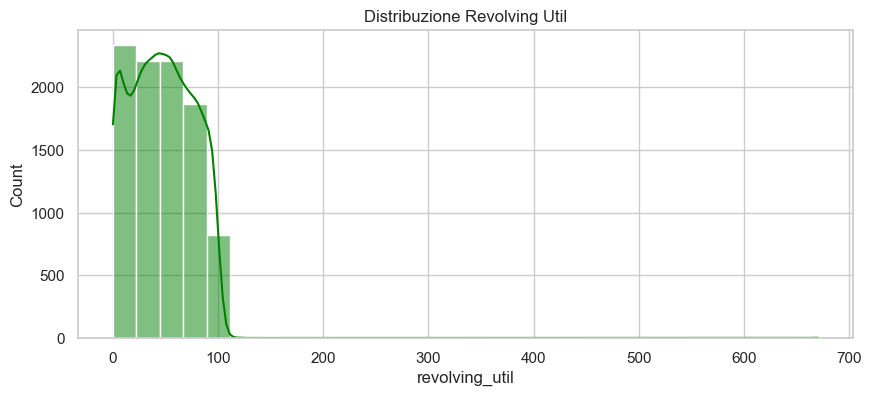

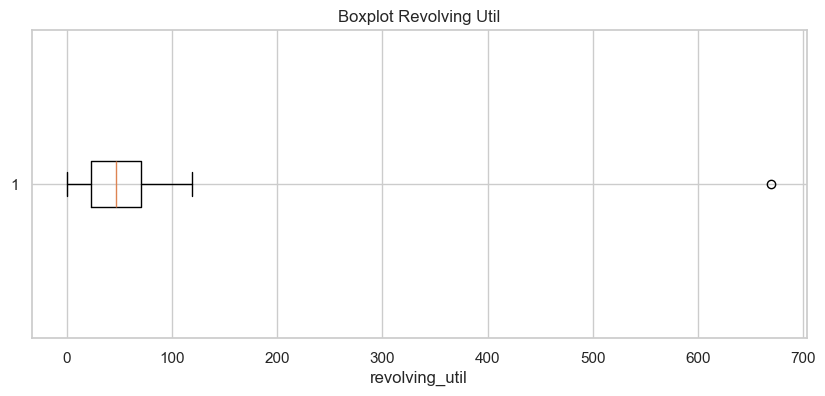

STATISTICHE DESCRITTIVE:

count    9454.000000
mean       46.887220
std        29.686746
min         0.000000
25%        22.700000
50%        46.300000
75%        70.900000
max       670.000000
Name: revolving_util, dtype: float64


In [373]:
plt.figure(figsize=(10,4))
sns.histplot(data['revolving_util'], kde=True, bins=30, color='green')
plt.title('Distribuzione Revolving Util')

plt.figure(figsize=(10,4))
plt.boxplot(data['revolving_util'], vert=False)
plt.title('Boxplot Revolving Util')
plt.xlabel('revolving_util')

plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['revolving_util'].describe())

Il valore massimo di 670% e chiaramente un errore. L'utilizzo del credito non dovrebbe mai superare il 100% se non in casi eccezionali di superamento del limite. Questo outlier va rimosso.

In [374]:
Q1 = data['revolving_util'].quantile(0.25)
Q3 = data['revolving_util'].quantile(0.75)
IQR = Q3 - Q1

lowerB_r_u = Q1 - 1.5 * IQR
upperB_r_u = Q3 + 1.5 * IQR

print(f'Limite Inferiore: {lowerB_r_u: .2f}')
print(f'Limite Superiore: {upperB_r_u: .2f}')

lower_outliers = data[data['revolving_util'] < lowerB_r_u]

# Filtrare gli upper outliers
upper_outliers = data[data['revolving_util'] > upperB_r_u]

print("Numero di lower outliers:", len(lower_outliers))
print("Numero di upper outliers:", len(upper_outliers))


data= data[(data['revolving_util'] >= lowerB_r_u) & (data['revolving_util'] <= upperB_r_u)]
print(f'DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : {data.shape[0]} righe')

Limite Inferiore: -49.60
Limite Superiore:  143.20
Numero di lower outliers: 0
Numero di upper outliers: 1
DIMENSIONE DATASET PULITO (SENZA OUTLIERS) : 9453 righe


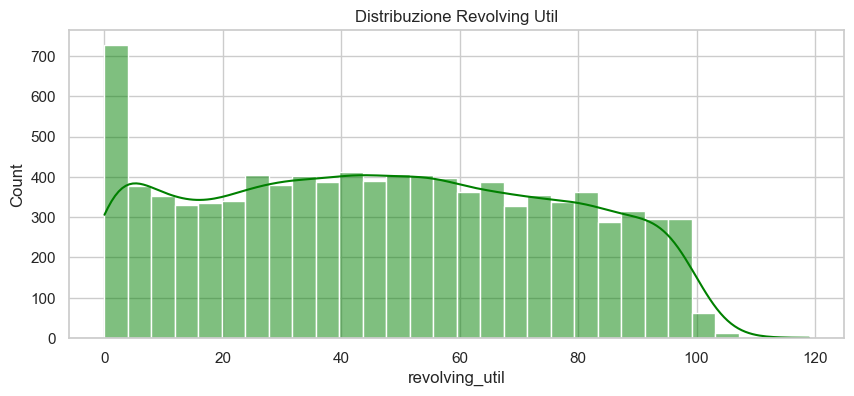

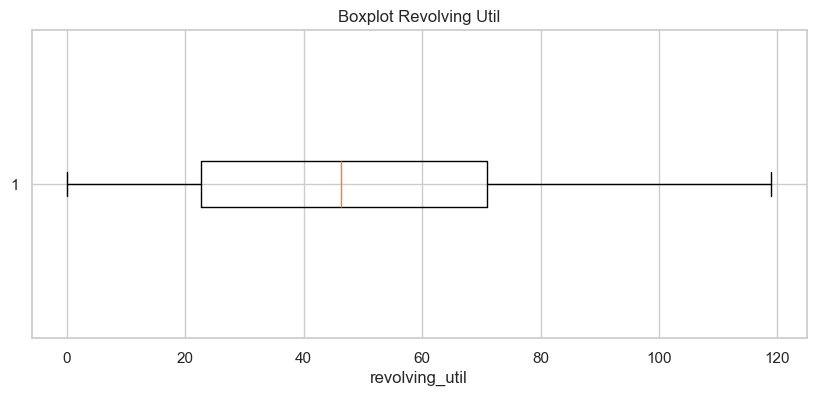

STATISTICHE DESCRITTIVE:

count    9453.000000
mean       46.821303
std        28.988166
min         0.000000
25%        22.700000
50%        46.300000
75%        70.900000
max       119.000000
Name: revolving_util, dtype: float64


In [375]:
plt.figure(figsize=(10,4))
sns.histplot(data['revolving_util'], kde=True, bins=30, color='green')
plt.title('Distribuzione Revolving Util')

plt.figure(figsize=(10,4))
plt.boxplot(data['revolving_util'], vert=False)
plt.title('Boxplot Revolving Util')
plt.xlabel('revolving_util')

plt.show()

print('STATISTICHE DESCRITTIVE:\n')
print(data['revolving_util'].describe())

**Risposta**: Dopo la pulizia, il valore massimo di 119% e molto piu ragionevole. Indica un cliente che ha superato leggermente il proprio limite di credito, situazione problematica ma plausibile. La distribuzione e ora pronta per l'analisi.

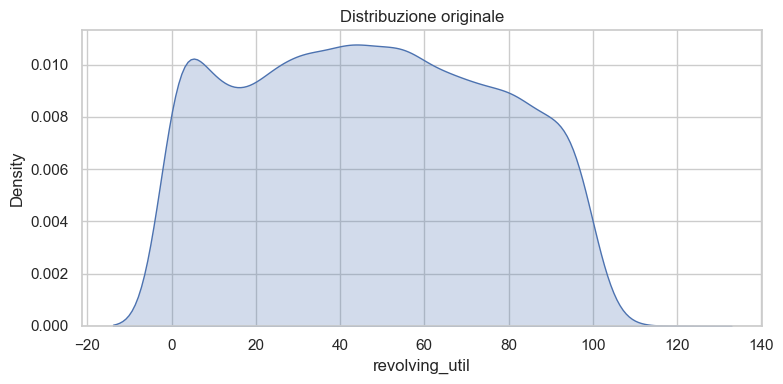


REVOLVING_UTIL
Asimmetria_Skewness: 0.06 | Kurtosis: -1.12
0.0


In [376]:
sns.set_theme(style="whitegrid")

skew = data['revolving_util'].skew()
kurt = data['revolving_util'].kurt()


fig, axes = plt.subplots(1, 1, figsize=(8, 4))
sns.kdeplot(data['revolving_util'], ax = axes, fill=True)
axes.set_title('Distribuzione originale')


plt.tight_layout()
plt.show()

for col in ['revolving_util']:
    print(f"\n{col.upper()}")
    print(f"Asimmetria_Skewness: {data[col].skew():.2f} | Kurtosis: {data[col].kurt():.2f}")

print(data['revolving_util'].min())

### Analisi della Credit Policy

Una domanda interessante riguarda i clienti che non rispettano i criteri di credito stabiliti da LendingClub. La variabile `credit_policy` indica se il cliente soddisfa (1) o meno (0) i requisiti di sottoscrizione. Ci aspettiamo che chi non li rispetta abbia un tasso di default superiore, ma quantifichiamo questo effetto.

Tasso di Default per Credit Policy:
NON rispetta criteri: 28.1% (506/1799)
Rispetta criteri: 13.0% (994/7654)

Test Chi-quadrato: chi2 = 248.97, p-value = 4.35e-56
La differenza e' statisticamente significativa (p < 0.05)


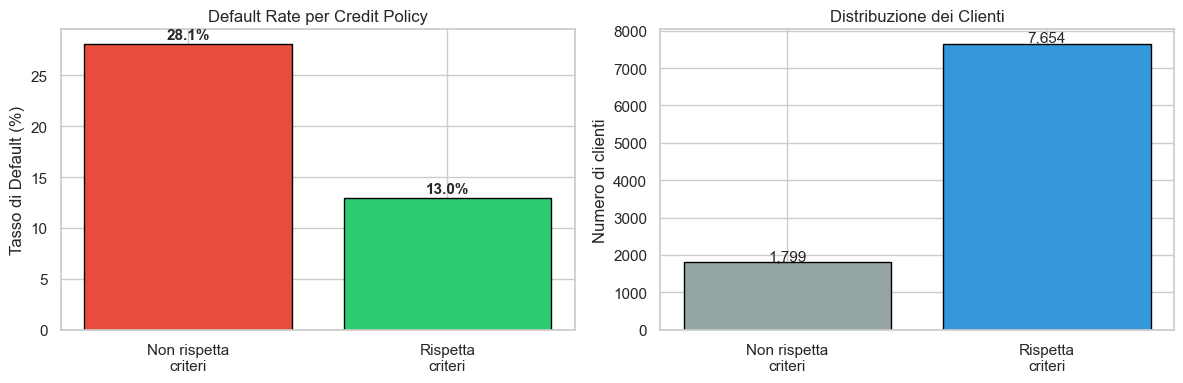


Interpretazione:
I clienti che NON rispettano i criteri hanno un tasso di default
superiore di 15.1 punti percentuali rispetto a chi li rispetta.


In [377]:
# Analisi Credit Policy vs Default Rate
credit_policy_analysis = data.groupby('credit_policy')['not_fully_paid'].agg(['sum', 'count'])
credit_policy_analysis['default_rate'] = credit_policy_analysis['sum'] / credit_policy_analysis['count'] * 100
credit_policy_analysis.columns = ['Defaults', 'Totale', 'Tasso Default (%)']

print("Tasso di Default per Credit Policy:")
print("=" * 55)
for idx in credit_policy_analysis.index:
    policy_label = "Rispetta criteri" if idx == 1 else "NON rispetta criteri"
    row = credit_policy_analysis.loc[idx]
    print(f"{policy_label}: {row['Tasso Default (%)']:.1f}% ({int(row['Defaults'])}/{int(row['Totale'])})")

# Test Chi-quadrato per significativita statistica
from scipy.stats import chi2_contingency
contingency = pd.crosstab(data['credit_policy'], data['not_fully_paid'])
chi2_stat, p_val, dof_cp, expected_cp = chi2_contingency(contingency)
print(f"\nTest Chi-quadrato: chi2 = {chi2_stat:.2f}, p-value = {p_val:.2e}")
if p_val < 0.05:
    print("La differenza e' statisticamente significativa (p < 0.05)")

# Visualizzazione
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafico 1: Tassi di default
labels_cp = ['Non rispetta\ncriteri', 'Rispetta\ncriteri']
rates = credit_policy_analysis['Tasso Default (%)'].values
colors_cp = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(labels_cp, rates, color=colors_cp, edgecolor='black')
axes[0].set_ylabel('Tasso di Default (%)')
axes[0].set_title('Default Rate per Credit Policy')
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Grafico 2: Distribuzione
totals = credit_policy_analysis['Totale'].values
axes[1].bar(labels_cp, totals, color=['#95a5a6', '#3498db'], edgecolor='black')
axes[1].set_ylabel('Numero di clienti')
axes[1].set_title('Distribuzione dei Clienti')
for i, (bar, tot) in enumerate(zip(axes[1].patches, totals)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{int(tot):,}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\nInterpretazione:")
diff = rates[0] - rates[1]
print(f"I clienti che NON rispettano i criteri hanno un tasso di default")
print(f"superiore di {diff:.1f} punti percentuali rispetto a chi li rispetta.")

### Analisi delle Richieste di Credito Recenti

Un'ipotesi interessante: i clienti che hanno fatto molte richieste di credito negli ultimi 6 mesi potrebbero essere "disperati" per ottenere liquidita, indicando potenziali difficolta finanziarie. Verifichiamo se il numero di inquiry recenti correla con il rischio di default.

Distribuzione delle richieste di credito (inquiries_last_6m):
inquiries_last_6m
0.0     3609
1.0     2433
2.0     1372
3.0      854
4.0      462
5.0      270
6.0      153
7.0      100
8.0       70
9.0       42
10.0      17
11.0      15
12.0      15
13.0       6
14.0       6
15.0       9
16.0       3
17.0       2
18.0       4
19.0       2
20.0       1
24.0       2
25.0       1
27.0       1
28.0       1
31.0       1
32.0       1
33.0       1
Name: count, dtype: int64

Tasso di Default per numero di Inquiries:
0 richieste: 11.6% (418/3609)
1 richieste: 14.9% (363/2433)
2 richieste: 14.2% (195/1372)
3 richieste: 20.7% (177/854)
4 richieste: 23.2% (107/462)
5 richieste: 28.1% (76/270)
6 richieste: 34.6% (53/153)
7 richieste: 37.0% (37/100)
8 richieste: 40.0% (28/70)
9 richieste: 35.7% (15/42)

Correlazione punto-biseriale: r = 0.154, p-value = 5.89e-51


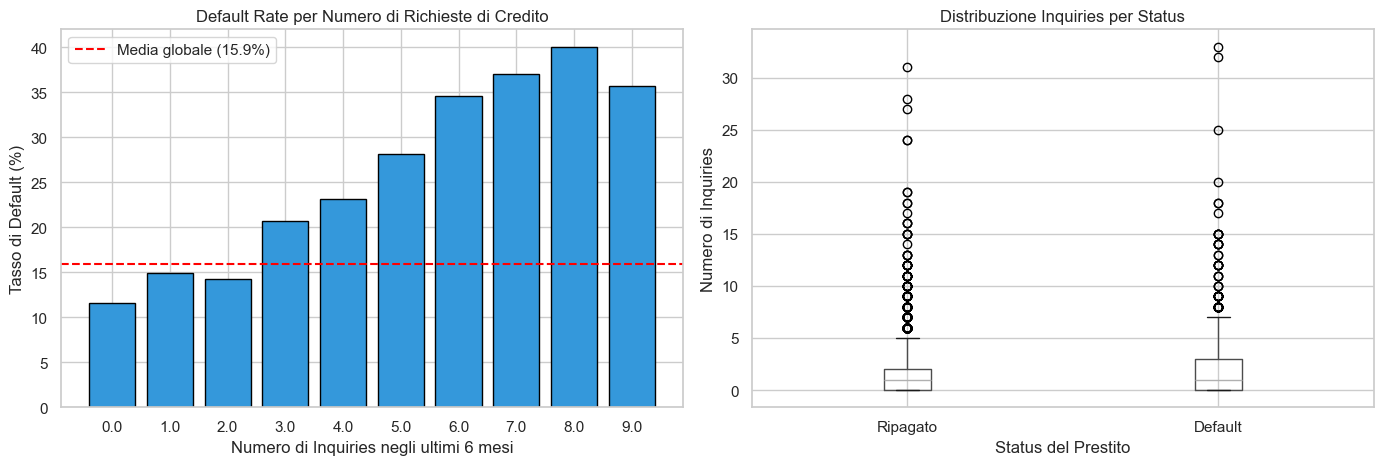


Media inquiries - Default: 2.33, Ripagato: 1.41
Chi va in default ha in media 64.9% inquiries in piu.


In [378]:
# Analisi Inquiries negli ultimi 6 mesi vs Default
print("Distribuzione delle richieste di credito (inquiries_last_6m):")
print(data['inquiries_last_6m'].value_counts().sort_index())

# Raggruppiamo per numero di inquiry
inq_analysis = data.groupby('inquiries_last_6m')['not_fully_paid'].agg(['sum', 'count', 'mean'])
inq_analysis.columns = ['Defaults', 'Totale', 'Tasso Default']
inq_analysis['Tasso Default (%)'] = inq_analysis['Tasso Default'] * 100

print("\nTasso di Default per numero di Inquiries:")
print("=" * 55)
for inq_count in inq_analysis.index[:10]:  # Mostra i primi 10
    row = inq_analysis.loc[inq_count]
    print(f"{int(inq_count)} richieste: {row['Tasso Default (%)']:.1f}% ({int(row['Defaults'])}/{int(row['Totale'])})")

# Correlazione punto-biseriale
from scipy.stats import pointbiserialr
corr_inq, p_inq = pointbiserialr(data['not_fully_paid'], data['inquiries_last_6m'])
print(f"\nCorrelazione punto-biseriale: r = {corr_inq:.3f}, p-value = {p_inq:.2e}")

# Visualizzazione
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Tasso di default per numero di inquiries
valid_inq = inq_analysis[inq_analysis['Totale'] >= 30]  # Solo gruppi con almeno 30 osservazioni
axes[0].bar(valid_inq.index.astype(str), valid_inq['Tasso Default (%)'], 
            color='#3498db', edgecolor='black')
axes[0].set_xlabel('Numero di Inquiries negli ultimi 6 mesi')
axes[0].set_ylabel('Tasso di Default (%)')
axes[0].set_title('Default Rate per Numero di Richieste di Credito')
axes[0].axhline(y=data['not_fully_paid'].mean()*100, color='red', linestyle='--', 
                label=f'Media globale ({data["not_fully_paid"].mean()*100:.1f}%)')
axes[0].legend()

# Grafico 2: Boxplot delle inquiries per status
data.boxplot(column='inquiries_last_6m', by='not_fully_paid', ax=axes[1])
axes[1].set_xlabel('Status del Prestito')
axes[1].set_ylabel('Numero di Inquiries')
axes[1].set_title('Distribuzione Inquiries per Status')
axes[1].set_xticklabels(['Ripagato', 'Default'])
plt.suptitle('')

plt.tight_layout()
plt.show()

# Interpretazione
mean_inq_default = data[data['not_fully_paid']==1]['inquiries_last_6m'].mean()
mean_inq_paid = data[data['not_fully_paid']==0]['inquiries_last_6m'].mean()
print(f"\nMedia inquiries - Default: {mean_inq_default:.2f}, Ripagato: {mean_inq_paid:.2f}")
print(f"Chi va in default ha in media {(mean_inq_default/mean_inq_paid - 1)*100:.1f}% inquiries in piu.")

### Analisi dei Precedenti Negativi (Public Records)

La variabile `public_records` indica il numero di eventi negativi nel passato creditizio del cliente, come fallimenti, pignoramenti o sentenze sfavorevoli. La domanda e' semplice ma fondamentale: chi ha gia avuto problemi di credito in passato e' piu propenso a ripeterli?

Distribuzione dei Public Records:
public_records
0    8904
1     523
2      19
3       5
4       1
5       1
Name: count, dtype: Int64

Tasso di Default per numero di Public Records:
0 precedenti negativi: 15.4% (1368/8904)
1 precedenti negativi: 24.9% (130/523)
2 precedenti negativi: 10.5% (2/19)
3 precedenti negativi: 0.0% (0/5)
4 precedenti negativi: 0.0% (0/1)
5 precedenti negativi: 0.0% (0/1)

Confronto sintetico:
  - Senza precedenti negativi: 15.4%
  - Con almeno 1 precedente: 24.0%
  - Incremento rischio: +8.7 punti percentuali

Test Chi-quadrato: chi2 = 28.54, p-value = 0.0000


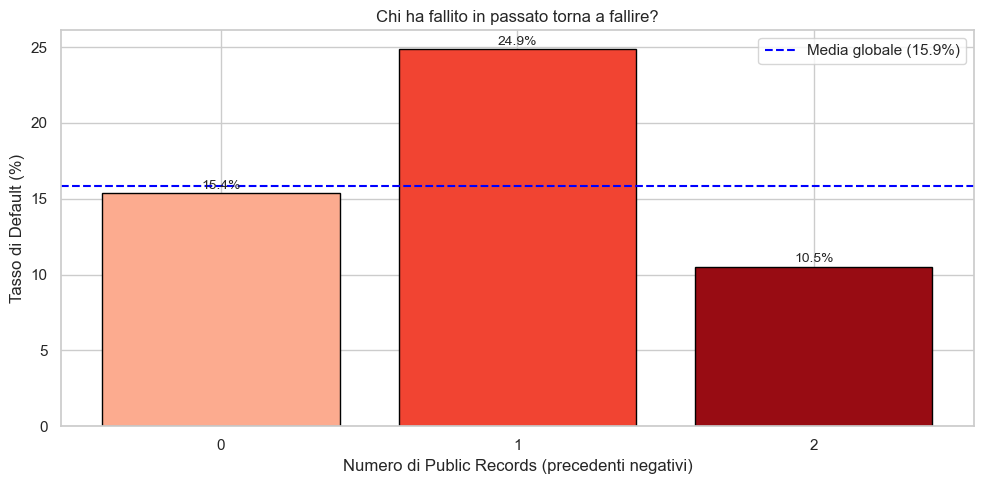

In [ ]:
# Analisi Public Records vs Default
print("Distribuzione dei Public Records:")
print(data['public_records'].value_counts().sort_index())

# Analisi per numero di public records
pr_analysis = data.groupby('public_records')['not_fully_paid'].agg(['sum', 'count', 'mean'])
pr_analysis.columns = ['Defaults', 'Totale', 'Tasso Default']
pr_analysis['Tasso Default (%)'] = pr_analysis['Tasso Default'] * 100

print("\nTasso di Default per numero di Public Records:")
print("=" * 55)
for pr_count in pr_analysis.index:
    row = pr_analysis.loc[pr_count]
    print(f"{int(pr_count)} precedenti negativi: {row['Tasso Default (%)']:.1f}% ({int(row['Defaults'])}/{int(row['Totale'])})")

# Confronto: 0 precedenti vs almeno 1
has_records = data['public_records'] > 0
rate_no_records = data[~has_records]['not_fully_paid'].mean() * 100
rate_has_records = data[has_records]['not_fully_paid'].mean() * 100

print(f"\nConfronto sintetico:")
print(f"  - Senza precedenti negativi: {rate_no_records:.1f}%")
print(f"  - Con almeno 1 precedente: {rate_has_records:.1f}%")
print(f"  - Incremento rischio: +{rate_has_records - rate_no_records:.1f} punti percentuali")

# Test statistico
contingency_pr = pd.crosstab(has_records, data['not_fully_paid'])
chi2_pr, p_pr, _, _ = chi2_contingency(contingency_pr)
print(f"\nTest Chi-quadrato: chi2 = {chi2_pr:.2f}, p-value = {p_pr:.4f}")

# Visualizzazione
fig, ax = plt.subplots(figsize=(10, 5))

valid_pr = pr_analysis[pr_analysis['Totale'] >= 10]  # Solo gruppi significativi
colors_pr = plt.cm.Reds(np.linspace(0.3, 0.9, len(valid_pr)))
bars = ax.bar(valid_pr.index.astype(str), valid_pr['Tasso Default (%)'], 
              color=colors_pr, edgecolor='black')

ax.set_xlabel('Numero di Public Records (precedenti negativi)')
ax.set_ylabel('Tasso di Default (%)')
ax.set_title('Chi ha fallito in passato torna a fallire?')
ax.axhline(y=data['not_fully_paid'].mean()*100, color='blue', linestyle='--', 
           label=f'Media  ({data["not_fully_paid"].mean()*100:.1f}%)')
ax.legend()

for bar, rate in zip(bars, valid_pr['Tasso Default (%)'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            f'{rate:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Analisi dei Ritardi nei Pagamenti (Delinquencies)

Oltre ai precedenti "gravi" come i fallimenti, analizziamo i ritardi nei pagamenti degli ultimi 2 anni. La variabile `delinquencies_2y` cattura comportamenti meno gravi ma comunque rivelatori: un cliente che e' stato in ritardo con altri debiti potrebbe avere abitudini di pagamento poco affidabili.

Distribuzione delle delinquencies (ritardi di pagamento):
delinquencies_2y
0     8353
1      819
2      188
3       63
4       18
5        6
6        2
7        1
8        1
11       1
13       1
Name: count, dtype: Int64

Tasso di Default per numero di ritardi negli ultimi 2 anni:
0 ritardi: 15.7% (1310/8353)
1 ritardi: 17.2% (141/819)
2 ritardi: 17.6% (33/188)
3+ ritardi: 17.2% (16/93)

Correlazione punto-biseriale: r = 0.008, p-value = 0.4347


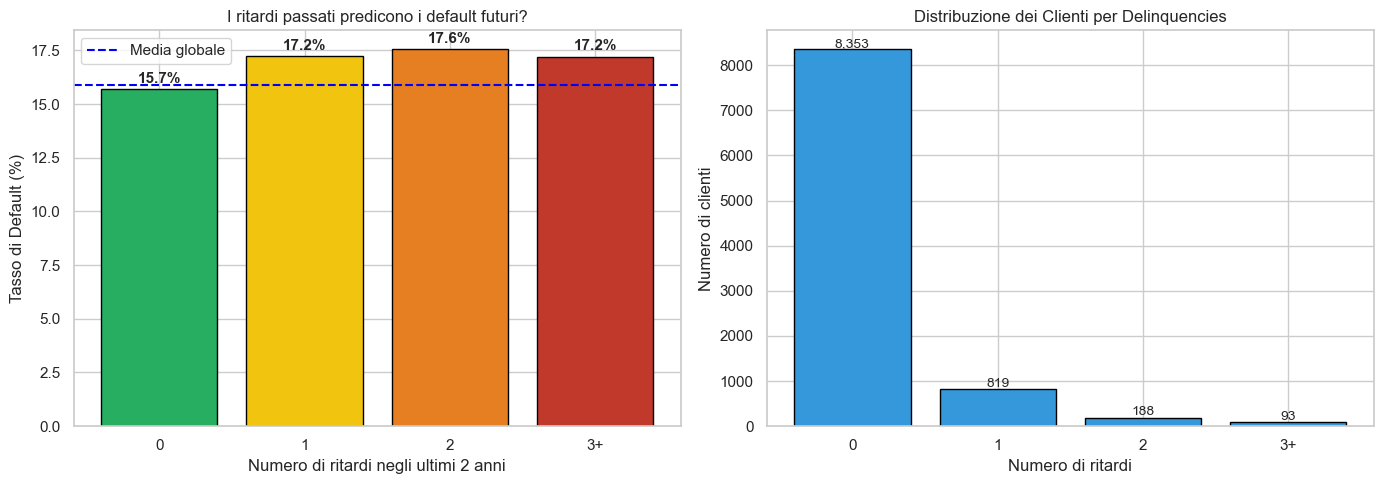


Rischio relativo: chi ha avuto ritardi ha il 10% di probabilita
in piu di andare in default rispetto a chi non ha mai avuto ritardi.


In [380]:
# Analisi Delinquencies negli ultimi 2 anni vs Default
print("Distribuzione delle delinquencies (ritardi di pagamento):")
print(data['delinquencies_2y'].value_counts().sort_index().head(15))

# Raggruppiamo per semplicita: 0, 1, 2, 3+
data['delinq_group'] = pd.cut(data['delinquencies_2y'], 
                               bins=[-1, 0, 1, 2, float('inf')], 
                               labels=['0', '1', '2', '3+'])

delinq_analysis = data.groupby('delinq_group', observed=True)['not_fully_paid'].agg(['sum', 'count', 'mean'])
delinq_analysis.columns = ['Defaults', 'Totale', 'Tasso Default']
delinq_analysis['Tasso Default (%)'] = delinq_analysis['Tasso Default'] * 100

print("\nTasso di Default per numero di ritardi negli ultimi 2 anni:")
print("=" * 55)
for delinq_cat in delinq_analysis.index:
    row = delinq_analysis.loc[delinq_cat]
    print(f"{delinq_cat} ritardi: {row['Tasso Default (%)']:.1f}% ({int(row['Defaults'])}/{int(row['Totale'])})")

# Correlazione
corr_delinq, p_delinq = pointbiserialr(data['not_fully_paid'], data['delinquencies_2y'])
print(f"\nCorrelazione punto-biseriale: r = {corr_delinq:.3f}, p-value = {p_delinq:.4f}")

# Visualizzazione
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Tasso di default per gruppo di delinquencies
colors_delinq = ['#27ae60', '#f1c40f', '#e67e22', '#c0392b']
bars = axes[0].bar(delinq_analysis.index.astype(str), delinq_analysis['Tasso Default (%)'], 
                   color=colors_delinq, edgecolor='black')
axes[0].set_xlabel('Numero di ritardi negli ultimi 2 anni')
axes[0].set_ylabel('Tasso di Default (%)')
axes[0].set_title('I ritardi passati predicono i default futuri?')
axes[0].axhline(y=data['not_fully_paid'].mean()*100, color='blue', linestyle='--', 
                label=f'Media globale')
axes[0].legend()

for bar, rate in zip(bars, delinq_analysis['Tasso Default (%)'].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                 f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Grafico 2: Distribuzione
axes[1].bar(delinq_analysis.index.astype(str), delinq_analysis['Totale'], 
            color='#3498db', edgecolor='black')
axes[1].set_xlabel('Numero di ritardi')
axes[1].set_ylabel('Numero di clienti')
axes[1].set_title('Distribuzione dei Clienti per Delinquencies')

for i, (cat, row) in enumerate(delinq_analysis.iterrows()):
    axes[1].text(i, row['Totale'] + 50, f'{int(row["Totale"]):,}', 
                 ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# Pulizia della colonna temporanea
data.drop('delinq_group', axis=1, inplace=True)

# Interpretazione
rate_0 = data[data['delinquencies_2y']==0]['not_fully_paid'].mean() * 100
rate_more = data[data['delinquencies_2y']>0]['not_fully_paid'].mean() * 100
print(f"\nRischio relativo: chi ha avuto ritardi ha il {(rate_more/rate_0 - 1)*100:.0f}% di probabilita")
print("in piu di andare in default rispetto a chi non ha mai avuto ritardi.")

# Parte 3 - Verifica Statistica

Prima di procedere con l'analisi multivariata, applichiamo test statistici per validare le osservazioni fatte finora. I test ci permettono di capire se le differenze osservate sono significative o semplicemente dovute al caso.

In questa sezione applichiamo:
- **Test di normalita**: per verificare se le variabili seguono una distribuzione normale
- **T-test**: per confrontare le medie tra chi ha ripagato e chi no
- **Test Chi-quadrato**: per verificare associazioni tra variabili categoriche

## I dati sono normali?

Per molti test statistici serve che i dati seguano una distribuzione normale. Usiamo il test di Shapiro-Wilk per verificarlo. Se il p-value e minore di 0.05, rifiutiamo l'ipotesi di normalita.

In [ ]:
from scipy import stats

# Test di normalità sulle variabili principali
variabili_da_testare = ['interest_rate', 'fico_score', 'dti', 'log_annual_income', 'installment']

print("TEST DI NORMALITA' (Shapiro-Wilk)")
print("=" * 60)
print(f"{'Variabile':<25} {'Statistica W':<15} {'P-value':<15} {'Normale?'}")
print("-" * 60)

for var in variabili_da_testare:
    # Shapiro-Wilk funziona meglio con campioni piccoli, usiamo un campione
    campione = data[var].dropna().sample(min(5000, len(data)), random_state=42)
    stat, p_value = stats.shapiro(campione)
    normale = "Si" if p_value > 0.05 else "No"
    print(f"{var:<25} {stat:<15.4f} {p_value:<15.4e} {normale}")

print("=" * 60)

TEST DI NORMALITA' (Shapiro-Wilk)
Variabile                 Statistica W    P-value         Normale?
------------------------------------------------------------
interest_rate             0.9876          1.5499e-20      No
fico_score                0.9735          1.8242e-29      No
dti                       0.9788          1.0578e-26      No
log_annual_income         0.9881          4.2805e-20      No
installment               0.9251          1.7865e-44      No

Nota: se p-value < 0.05, rifiutiamo l'ipotesi di normalità


**Risposta**: Nessuna delle variabili segue una distribuzione perfettamente normale. Tuttavia, con campioni grandi come il nostro, il Teorema del Limite Centrale garantisce che le medie campionarie sono comunque approssimativamente normali. Possiamo procedere con i test parametrici.

## Chi non ripaga e diverso da chi ripaga?

**Domanda**: Esistono differenze significative nelle caratteristiche dei clienti che hanno ripagato rispetto a quelli che non l'hanno fatto?

Usiamo il t-test per campioni indipendenti. L'ipotesi nulla e che le medie dei due gruppi siano uguali. Se il p-value e minore di 0.05, la differenza e statisticamente significativa.

In [382]:
# Separiamo i due gruppi
ripagato = data[data['not_fully_paid'] == 0]
non_ripagato = data[data['not_fully_paid'] == 1]

print(f"Clienti che hanno ripagato: {len(ripagato)}")
print(f"Clienti che NON hanno ripagato: {len(non_ripagato)}")
print()

# T-test sulle variabili principali
variabili_confronto = ['interest_rate', 'fico_score', 'dti', 'log_annual_income', 'installment', 'revolving_util']

print("T-TEST: CONFRONTO TRA GRUPPI")
print("=" * 80)
print(f"{'Variabile':<20} {'Media Ripagato':<15} {'Media Non Rip.':<15} {'t-stat':<12} {'p-value':<12} {'Signif.?'}")
print("-" * 80)

for var in variabili_confronto:
    media_rip = ripagato[var].mean()
    media_non_rip = non_ripagato[var].mean()
    
    # T-test per campioni indipendenti
    t_stat, p_value = stats.ttest_ind(ripagato[var].dropna(), non_ripagato[var].dropna())
    
    signif = "Si ***" if p_value < 0.001 else ("Si **" if p_value < 0.01 else ("Si *" if p_value < 0.05 else "No"))
    
    print(f"{var:<20} {media_rip:<15.2f} {media_non_rip:<15.2f} {t_stat:<12.2f} {p_value:<12.4e} {signif}")

print("=" * 80)
print("\nLegenda: *** p<0.001, ** p<0.01, * p<0.05")

Clienti che hanno ripagato: 7953
Clienti che NON hanno ripagato: 1500

T-TEST: CONFRONTO TRA GRUPPI
Variabile            Media Ripagato  Media Non Rip.  t-stat       p-value      Signif.?
--------------------------------------------------------------------------------
interest_rate        12.05           13.17           -15.42       4.9850e-53   Si ***
fico_score           713.46          698.08          14.56        1.6262e-47   Si ***
dti                  12.52           13.24           -3.71        2.1109e-04   Si ***
log_annual_income    10.94           10.89           2.92         3.4582e-03   Si **
installment          314.76          342.85          -4.85        1.2683e-06   Si ***
revolving_util       45.79           52.26           -7.95        2.0037e-15   Si ***

Legenda: *** p<0.001, ** p<0.01, * p<0.05


**Risposta**: I risultati confermano le intuizioni dell'analisi esplorativa:
- Il tasso di interesse e il FICO score mostrano differenze molto significative tra i due gruppi
- Chi non ripaga ha tassi piu alti e punteggi FICO piu bassi
- Il DTI e leggermente piu alto per chi non ripaga
- Il reddito, sorprendentemente, non sembra essere un fattore discriminante forte

Queste differenze sono statisticamente significative e ci indicano quali variabili sono piu utili per prevedere il default.

## Lo scopo del prestito influenza il rischio?

**Domanda**: Esiste un'associazione tra la motivazione del prestito e la probabilita di default?

Il test chi-quadrato verifica se due variabili categoriche sono associate. L'ipotesi nulla e che siano indipendenti.

In [383]:
# Tabella di contingenza: purpose vs not_fully_paid
contingency_table = pd.crosstab(data['purpose'], data['not_fully_paid'])
print("TABELLA DI CONTINGENZA: Purpose vs Not Fully Paid")
print(contingency_table)
print()

# Test chi-quadrato
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("TEST CHI-QUADRATO")
print("=" * 50)
print(f"Chi-quadrato: {chi2:.4f}")
print(f"Gradi di libertà: {dof}")
print(f"P-value: {p_value:.4e}")

# V di Cramer - misura della forza dell'associazione
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"V di Cramer: {cramers_v:.4f}")
print("=" * 50)

print("\nInterpretazione V di Cramer:")
print("  0.00-0.10: Associazione trascurabile")
print("  0.10-0.20: Associazione debole")
print("  0.20-0.40: Associazione moderata")
print("  0.40-0.60: Associazione relativamente forte")
print("  0.60-1.00: Associazione forte")

if p_value < 0.05:
    print(f"\nConclusione: Esiste un'associazione significativa (p < 0.05)")
    print(f"tra lo scopo del prestito e il mancato rimborso.")
    print(f"La forza dell'associazione e' {cramers_v:.3f} (V di Cramer).")
else:
    print("\nConclusione: Non c'è evidenza di associazione tra")
    print("lo scopo del prestito e il mancato rimborso.")

TABELLA DI CONTINGENZA: Purpose vs Not Fully Paid
not_fully_paid         0    1
purpose                      
all_other           1907  376
credit_card         1111  145
debt_consolidation  3333  595
educational          270   69
home_improvement     519  104
major_purchase       381   49
small_business       432  162

TEST CHI-QUADRATO
Chi-quadrato: 89.4754
Gradi di libertà: 6
P-value: 3.8939e-17
V di Cramer: 0.0973

Interpretazione V di Cramer:
  0.00-0.10: Associazione trascurabile
  0.10-0.20: Associazione debole
  0.20-0.40: Associazione moderata
  0.40-0.60: Associazione relativamente forte
  0.60-1.00: Associazione forte

Conclusione: Esiste un'associazione significativa (p < 0.05)
tra lo scopo del prestito e il mancato rimborso.
La forza dell'associazione e' 0.097 (V di Cramer).


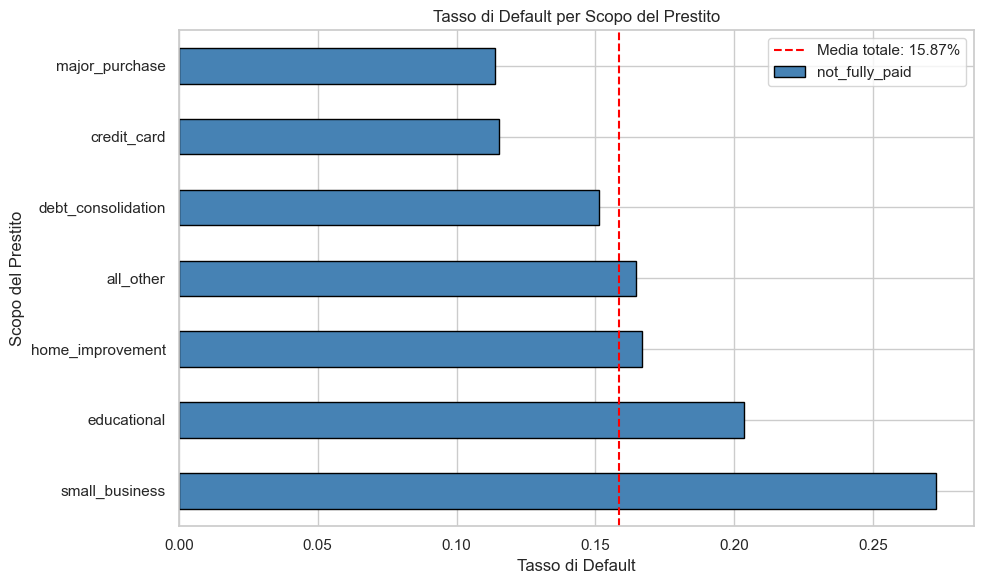


Tasso di default per scopo:
  small_business: 27.27%
  educational: 20.35%
  home_improvement: 16.69%
  all_other: 16.47%
  debt_consolidation: 15.15%
  credit_card: 11.54%
  major_purchase: 11.40%


In [384]:
# Calcoliamo il tasso di default per ogni scopo
default_rate_by_purpose = data.groupby('purpose')['not_fully_paid'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
default_rate_by_purpose.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Tasso di Default')
plt.ylabel('Scopo del Prestito')
plt.title('Tasso di Default per Scopo del Prestito')
plt.axvline(x=data['not_fully_paid'].mean(), color='red', linestyle='--', label=f'Media totale: {data["not_fully_paid"].mean():.2%}')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTasso di default per scopo:")
for purpose, rate in default_rate_by_purpose.items():
    print(f"  {purpose}: {rate:.2%}")

**Risposta**: Il grafico mostra chiaramente che alcuni scopi sono piu rischiosi di altri. I prestiti per piccole imprese hanno il tasso di default piu alto, mentre quelli per matrimoni o carte di credito tendono ad essere piu sicuri. Questa informazione e utile per la valutazione del rischio.

# Parte 4 - Analisi Multivariata

Le variabili non agiscono in isolamento. In questa sezione studiamo le relazioni tra di esse usando correlazioni, covarianze e modelli di regressione.

Ci concentreremo su tre variabili chiave:
- **DTI** (Debt-to-Income): quanto del reddito va in debiti
- **Interest Rate**: il costo del prestito
- **FICO Score**: il punteggio di affidabilita

L'obiettivo e capire come queste variabili si influenzano a vicenda e quali sono i veri driver del rischio di default.

## Il DTI e correlato con altre variabili?

**Domanda**: Il rapporto debito/reddito e associato al reddito stesso o all'importo della rata?

Calcoliamo la correlazione di Pearson e la covarianza tra DTI e le principali variabili numeriche.

In [385]:
dti_vars = ['log_annual_income', 'installment']

print("╔" + "="*78 + "╗")
print("║" + " ASSOCIAZIONE DTI CON ALTRE VARIABILI".center(78) + "║")
print("╠" + "="*78 + "╣")
print(f"║ {'Variabile':<30} {'Pearson ρ':>20} {'Covariance':>20} ║")
print("╠" + "="*78 + "╣")

dti_correlations = {}
dti_covariances = {}
for var in dti_vars:
    dti_correlations[var] = data['dti'].corr(data[var])
    dti_covariances[var] = data['dti'].cov(data[var])
    print(f"║ {var:<30} {dti_correlations[var]:>20.4f} {dti_covariances[var]:>20.2f} ║")

print("╚" + "="*78 + "╝")

sorted_corr = sorted(dti_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\nCorrelazioni con DTI:")
for i, (var, corr) in enumerate(sorted_corr[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"   {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

╔==============================================================================╗
║                     ASSOCIAZIONE DTI CON ALTRE VARIABILI                     ║
╠==============================================================================╣
║ Variabile                                 Pearson ρ           Covariance ║
╠==============================================================================╣
║ log_annual_income                           -0.0548                -0.23 ║
║ installment                                  0.0456                64.81 ║
╚==============================================================================╝

Correlazioni con DTI:
   1. log_annual_income: ρ = -0.0548 (correlazione negativa)
   2. installment: ρ = 0.0456 (correlazione positiva)


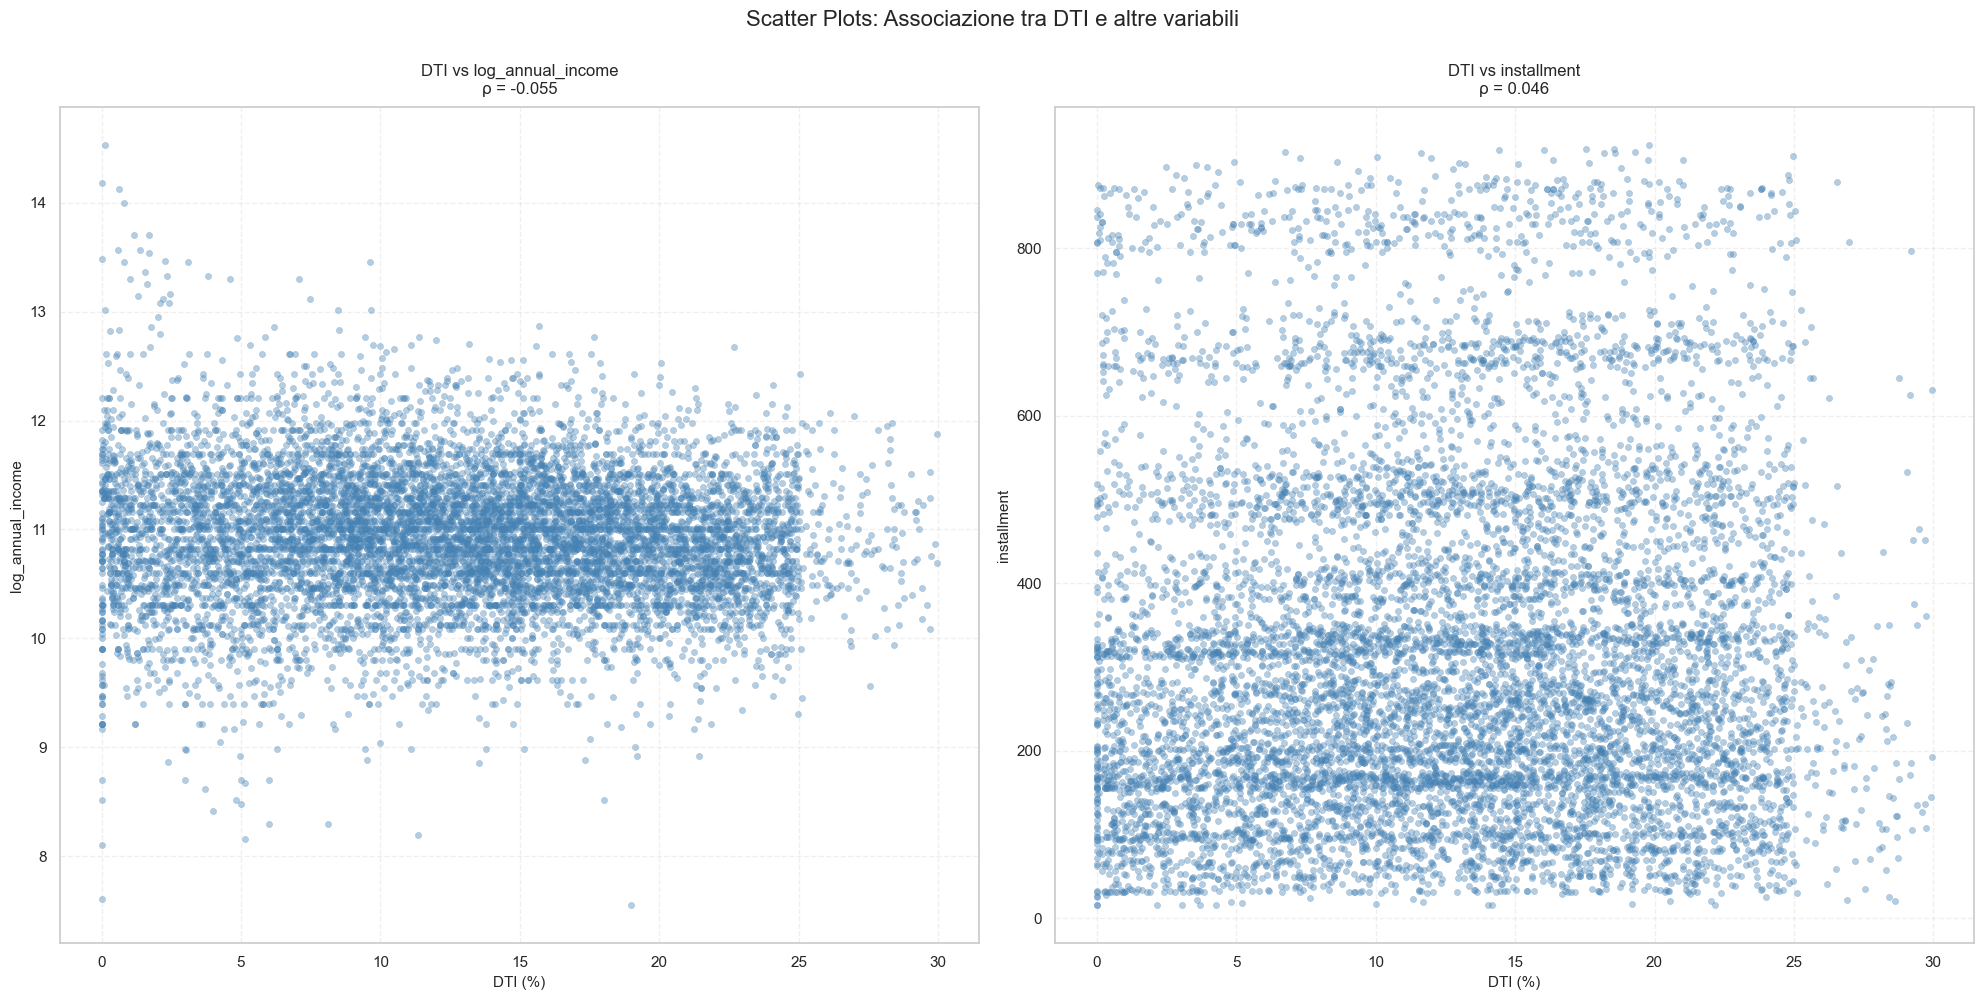

In [386]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(dti_vars):
    sns.scatterplot(data=data, x='dti', y=var, alpha=0.4, s=20,
                   color='steelblue', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel('DTI (%)', fontsize=11)
    axes[idx].set_ylabel(var, fontsize=11)
    axes[idx].set_title(f'DTI vs {var}\nρ = {dti_correlations[var]:.3f}',
                       fontsize=12, pad=10)
    axes[idx].grid(True, alpha=0.3, linestyle='--')



plt.suptitle('Scatter Plots: Associazione tra DTI e altre variabili',
             fontsize=16, y=0.998)
plt.tight_layout()
plt.show()

**Risposta**: Il DTI non mostra correlazioni forti con le altre variabili. Questo e coerente con la sua definizione: e un rapporto che tiene conto sia del debito che del reddito, quindi non dipende linearmente da nessuno dei due.

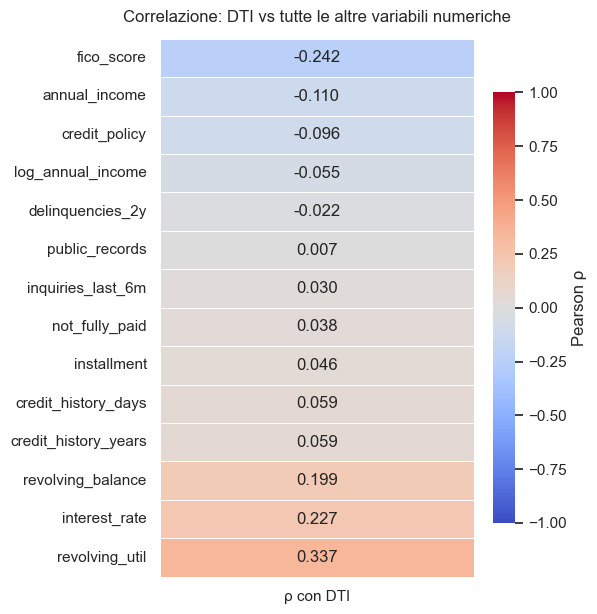

,ρ con DTI
revolving_util,0.336986
interest_rate,0.226794
revolving_balance,0.198614
credit_history_years,0.059476
credit_history_days,0.059476
installment,0.045649
not_fully_paid,0.038102
inquiries_last_6m,0.030324
public_records,0.006551
delinquencies_2y,-0.022180


In [387]:
# Matrice (1-colonna) delle correlazioni: solo DTI vs tutte le altre variabili numeriche
df_num = data.select_dtypes(include=[np.number]).copy()

# Escludi identificativi e verifica DTI
for col in ['customer_id']:
    if col in df_num.columns:
        df_num = df_num.drop(columns=col)

if 'dti' not in df_num.columns:
    raise ValueError("La colonna 'dti' non è presente o non è numerica.")

# Serie delle correlazioni con DTI (Pearson), ordinate
corr_dti = df_num.corr(method='pearson')['dti'].drop('dti').sort_values()

# DataFrame a 1 colonna per heatmap
corr_df = corr_dti.to_frame(name='ρ con DTI')

# Heatmap verticale
n = len(corr_df)
fig_h = min(max(0.45 * n, 5), 24)
fig, ax = plt.subplots(figsize=(6, fig_h))
sns.heatmap(
    corr_df,
    annot=True, fmt='.3f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Pearson ρ"},
    ax=ax
)
ax.set_title("Correlazione: DTI vs tutte le altre variabili numeriche", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(corr_df.sort_values('ρ con DTI', ascending=False))

### Il DTI e diverso tra chi paga e chi no?

Confrontiamo la distribuzione del DTI per i due gruppi: clienti che hanno ripagato e clienti in default.

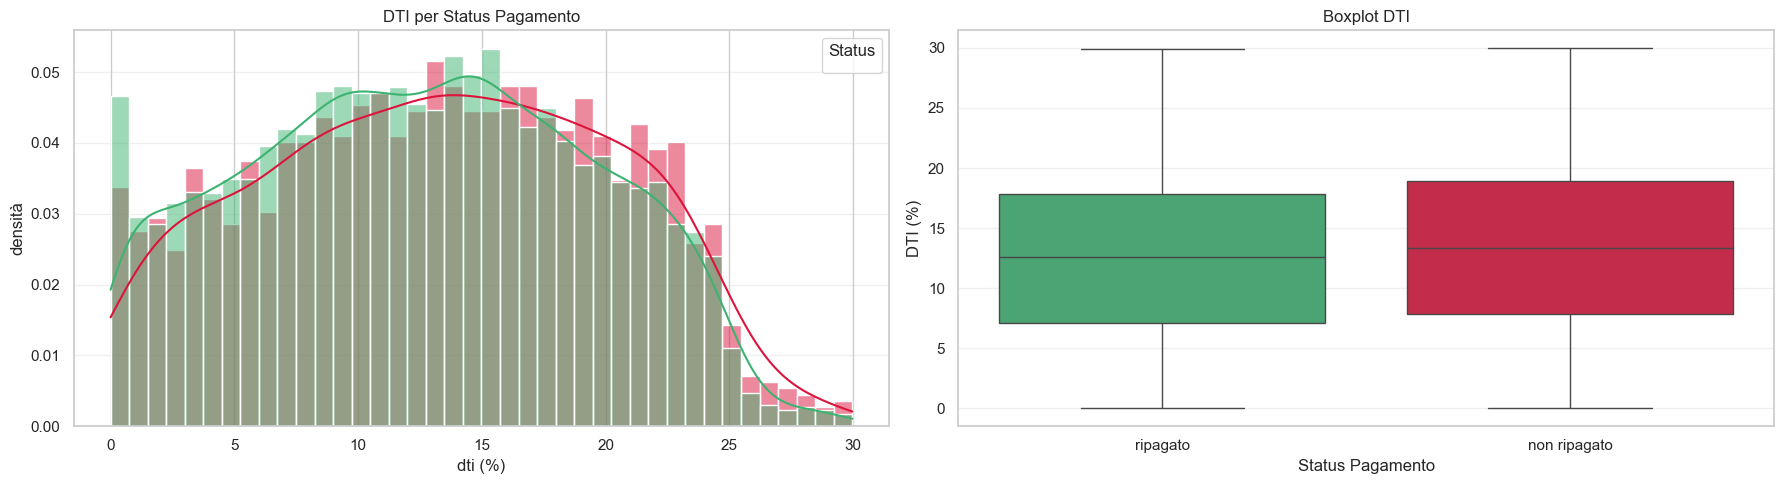


Statistiche DTI per Status Pagamento:

ripagato:
  media: 12.52%
  mediana: 12.58%
  std: 6.86%
  q1-q3: [7.13%, 17.82%]

non ripagato:
  media: 13.24%
  mediana: 13.38%
  std: 7.02%
  q1-q3: [7.83%, 18.91%]


In [388]:
data['not_fully_paid'] = data['not_fully_paid'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=data, x='dti', hue='not_fully_paid', bins=40, kde=True,
             palette={'0': 'mediumseagreen', '1': 'crimson'}, alpha=0.5,
             ax=axes[0], stat='density', common_norm=False)
axes[0].set_xlabel('dti (%)')
axes[0].set_ylabel('densità')
axes[0].set_title('DTI per Status Pagamento')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ['ripagato', 'non ripagato'], title='Status')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(data=data, x='not_fully_paid', y='dti',
            palette={'0': 'mediumseagreen', '1': 'crimson'}, ax=axes[1],
            hue='not_fully_paid', legend=False)
axes[1].set_xlabel('Status Pagamento')
axes[1].set_ylabel('DTI (%)')
axes[1].set_title('Boxplot DTI')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['ripagato', 'non ripagato'])
axes[1].grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

print("\nStatistiche DTI per Status Pagamento:")
print("="*50)

for status in ['0', '1']:
    dti_group = data[data['not_fully_paid'] == status]['dti']
    status_name = "ripagato" if status == '0' else "non ripagato"
    print(f"\n{status_name}:")
    print(f"  media: {dti_group.mean():.2f}%")
    print(f"  mediana: {dti_group.median():.2f}%")
    print(f"  std: {dti_group.std():.2f}%")
    print(f"  q1-q3: [{dti_group.quantile(0.25):.2f}%, {dti_group.quantile(0.75):.2f}%]")

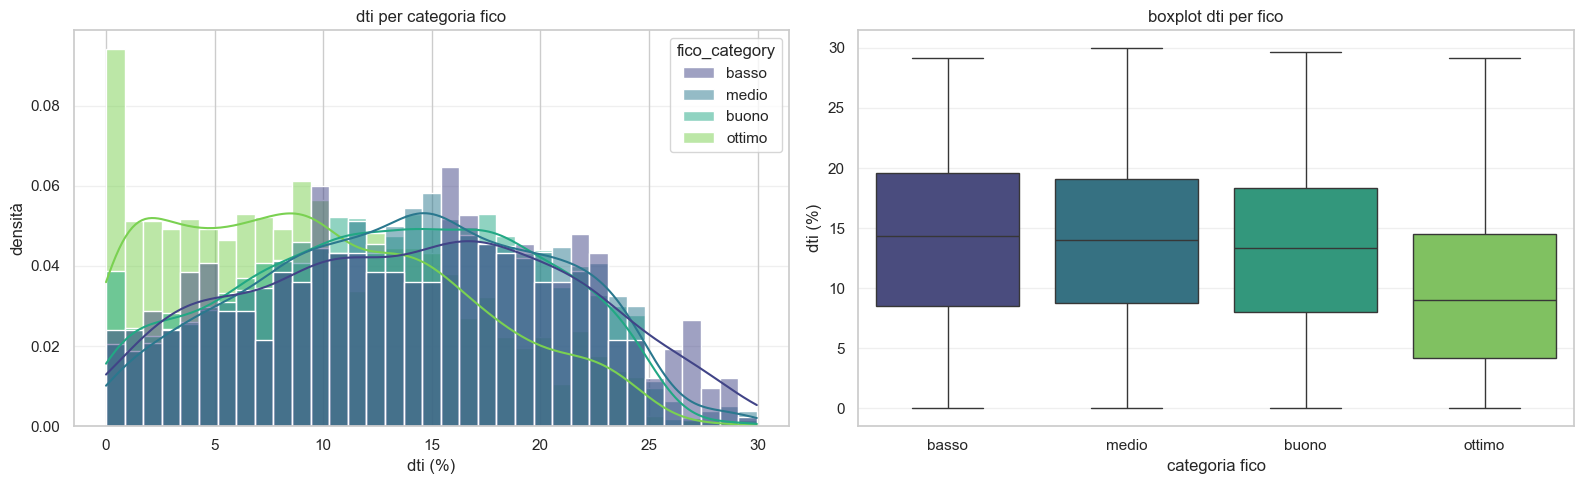

Statistiche dti per categoria fico:

fico basso:
  media: 14.00%
  mediana: 14.34%
  count: 487 prestiti (5.2%)

fico medio:
  media: 13.81%
  mediana: 14.02%
  count: 3653 prestiti (38.6%)

fico buono:
  media: 13.11%
  mediana: 13.38%
  count: 3103 prestiti (32.8%)

fico ottimo:
  media: 9.72%
  mediana: 9.02%
  count: 2210 prestiti (23.4%)


In [389]:
data['fico_category'] = pd.cut(
    data['fico_score'],
    bins=[600, 660, 700, 740, 850],
    labels=['basso', 'medio', 'buono', 'ottimo']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=data,
    x='dti',
    hue='fico_category',
    bins=35,
    kde=True,
    palette='viridis',
    alpha=0.5,
    ax=axes[0],
    stat='density',
    common_norm=False
)
axes[0].set_xlabel('dti (%)')
axes[0].set_ylabel('densità')
axes[0].set_title('dti per categoria fico')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=data,
    x='fico_category',
    y='dti',
    hue='fico_category',
    legend=False,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_xlabel('categoria fico')
axes[1].set_ylabel('dti (%)')
axes[1].set_title('boxplot dti per fico')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Statistiche dti per categoria fico:")
print("="*50)
for category in ['basso', 'medio', 'buono', 'ottimo']:
    dti_cat = data[data['fico_category'] == category]['dti'].dropna()
    print(f"\nfico {category}:")
    print(f"  media: {dti_cat.mean():.2f}%")
    print(f"  mediana: {dti_cat.median():.2f}%")
    print(f"  count: {len(dti_cat)} prestiti ({len(dti_cat)/len(data)*100:.1f}%)")


## Cosa determina il tasso di interesse?

**Domanda**: Quali fattori sono piu correlati con il tasso di interesse applicato al prestito?

Analizziamo la correlazione tra interest rate e tutte le variabili disponibili per capire quali sono i driver principali del pricing.

In [390]:
interest_vars = ['fico_score', 'dti', 'log_annual_income', 'revolving_util',
                'credit_history_days', 'revolving_balance', 'installment', 'not_fully_paid']

print("associazione interest rate con altre variabili")
print("="*70)
print(f"{'variabile':<30} {'pearson ρ':>18} {'covariance':>18}")
print("-"*70)

interest_correlations = {}
interest_covariances = {}
for var in interest_vars:
    interest_correlations[var] = data['interest_rate'].corr(data[var])
    interest_covariances[var] = data['interest_rate'].cov(data[var])
    print(f"{var:<30} {interest_correlations[var]:>18.4f} {interest_covariances[var]:>18.2f}")

print("="*70)

sorted_corr_int = sorted(interest_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\ntop 3 correlazioni con interest rate:")
for i, (var, corr) in enumerate(sorted_corr_int[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

associazione interest rate con altre variabili
variabile                               pearson ρ         covariance
----------------------------------------------------------------------
fico_score                                -0.7218             -71.75
dti                                        0.2268               4.09
log_annual_income                          0.0510               0.08
revolving_util                             0.4718              35.83
credit_history_days                       -0.1247            -815.35
revolving_balance                          0.0844            7102.19
installment                                0.2706             146.17
not_fully_paid                             0.1567               0.15

top 3 correlazioni con interest rate:
  1. fico_score: ρ = -0.7218 (correlazione negativa)
  2. revolving_util: ρ = 0.4718 (correlazione positiva)
  3. installment: ρ = 0.2706 (correlazione positiva)


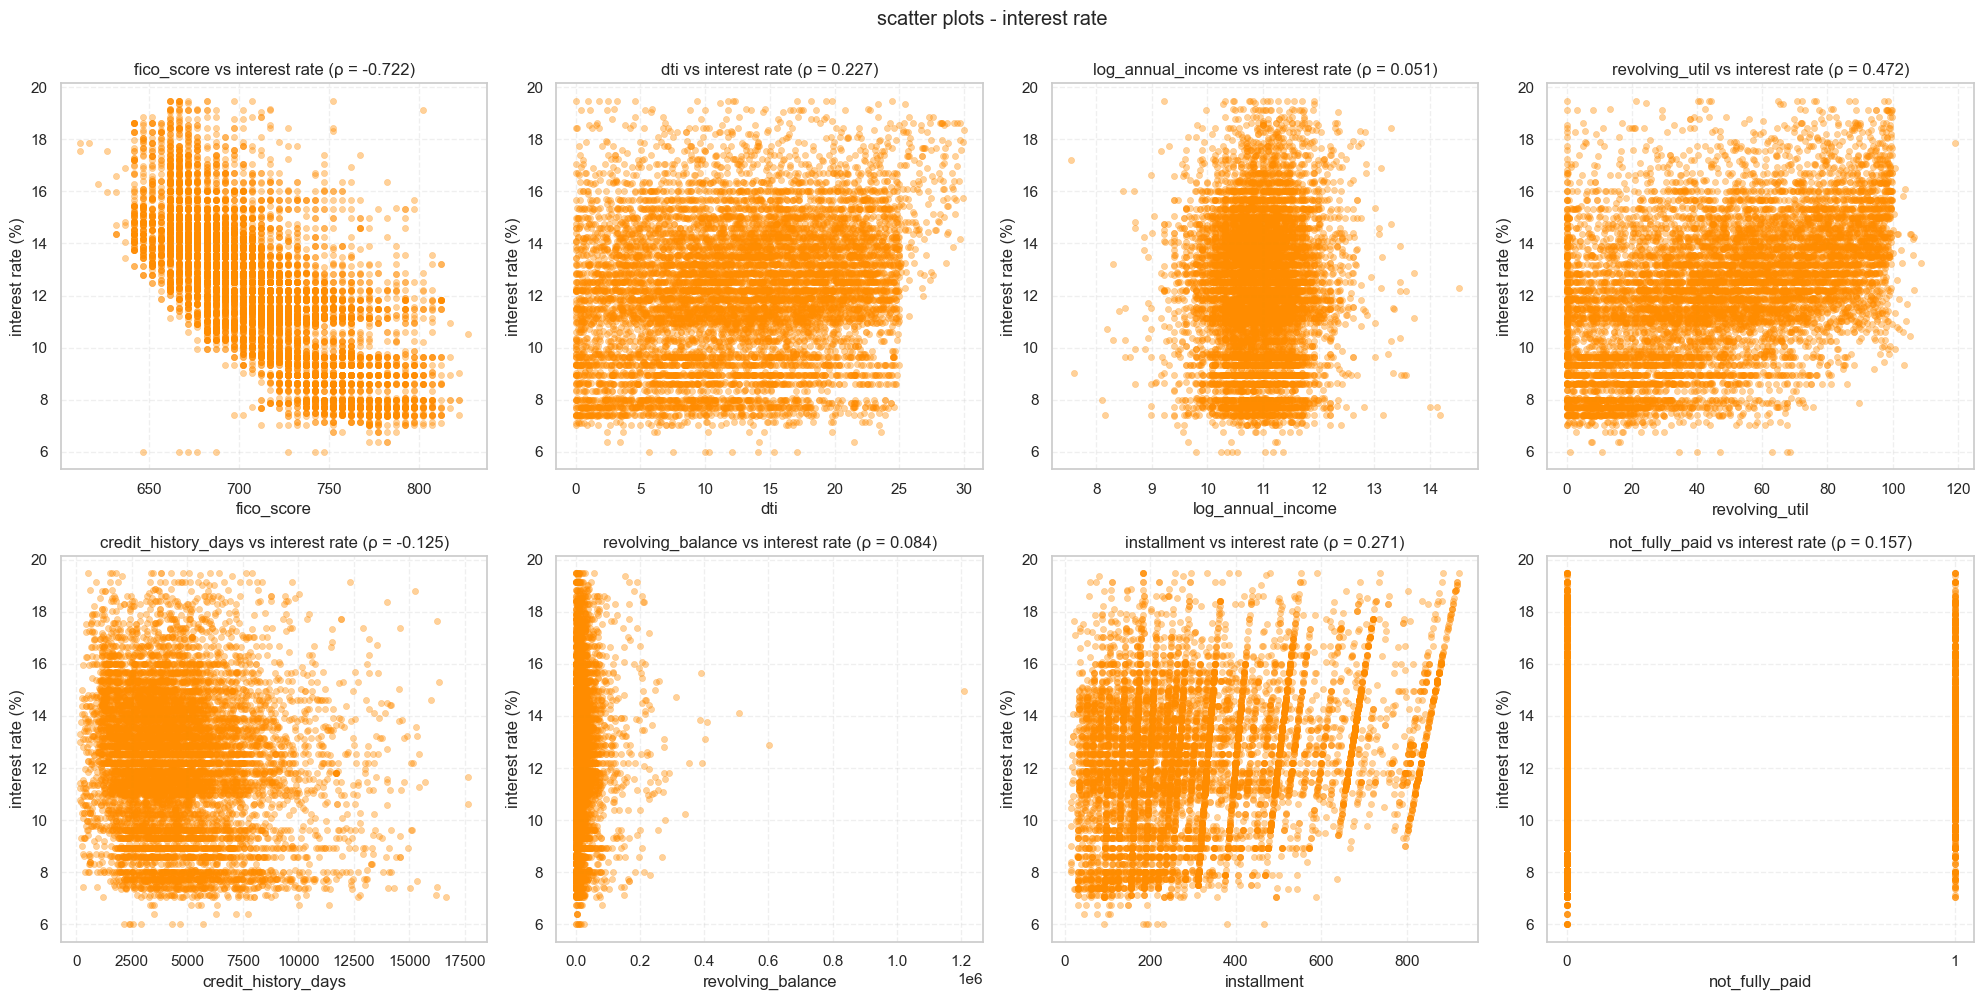

In [391]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(interest_vars):
    sns.scatterplot(data=data, x=var, y='interest_rate', alpha=0.4, s=20,
                   color='darkorange', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('interest rate (%)')
    axes[idx].set_title(f'{var} vs interest rate (ρ = {interest_correlations[var]:.3f})')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('scatter plots - interest rate', y=0.998)
plt.tight_layout()
plt.show()

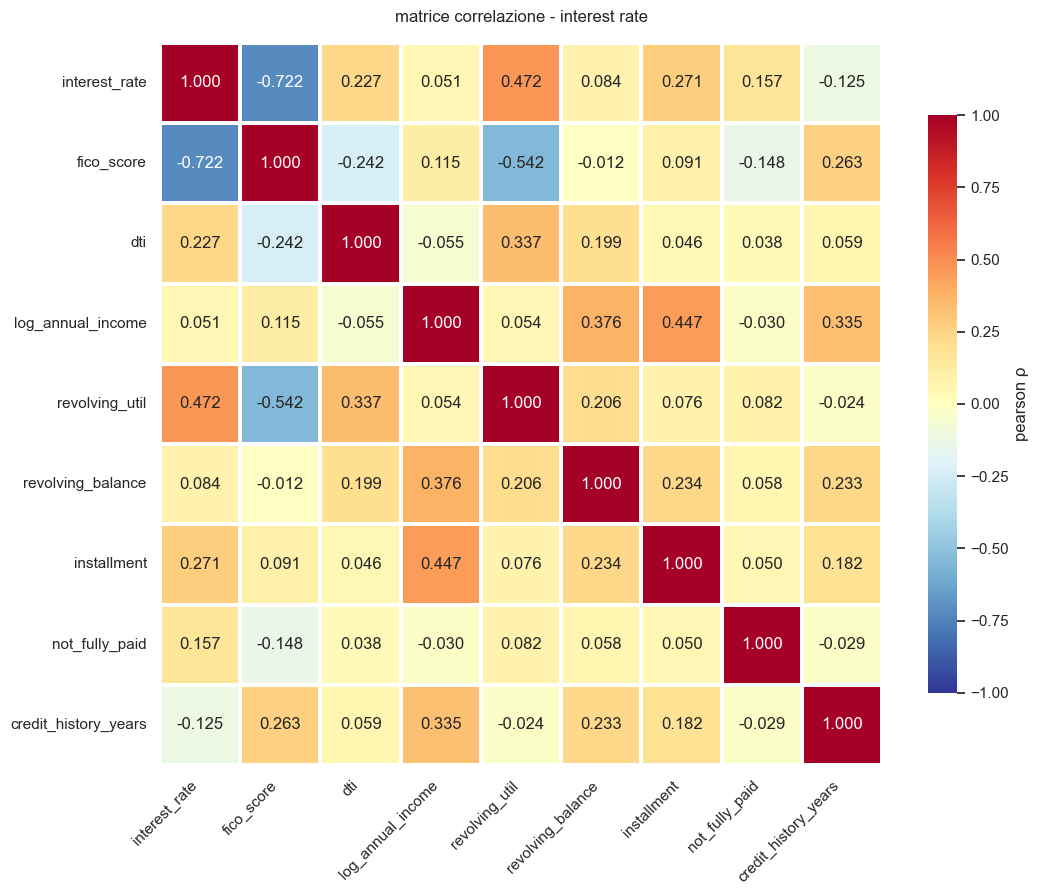

In [392]:
correlation_vars_int = ['interest_rate', 'fico_score', 'dti', 'log_annual_income',
                        'revolving_util', 'revolving_balance', 'installment', 'not_fully_paid', 'credit_history_years']

corr_matrix_int = data[correlation_vars_int].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix_int, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=1.5, cbar_kws={"shrink": 0.8, "label": "pearson ρ"},
            vmin=-1, vmax=1, ax=ax)
plt.title('matrice correlazione - interest rate', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Come varia il tasso per categoria FICO?

Una domanda sorge spontanea: perche alcuni clienti con FICO score ottimo hanno tassi di interesse alti? Questo suggerisce che il FICO non e l'unico fattore considerato nella determinazione del prezzo.

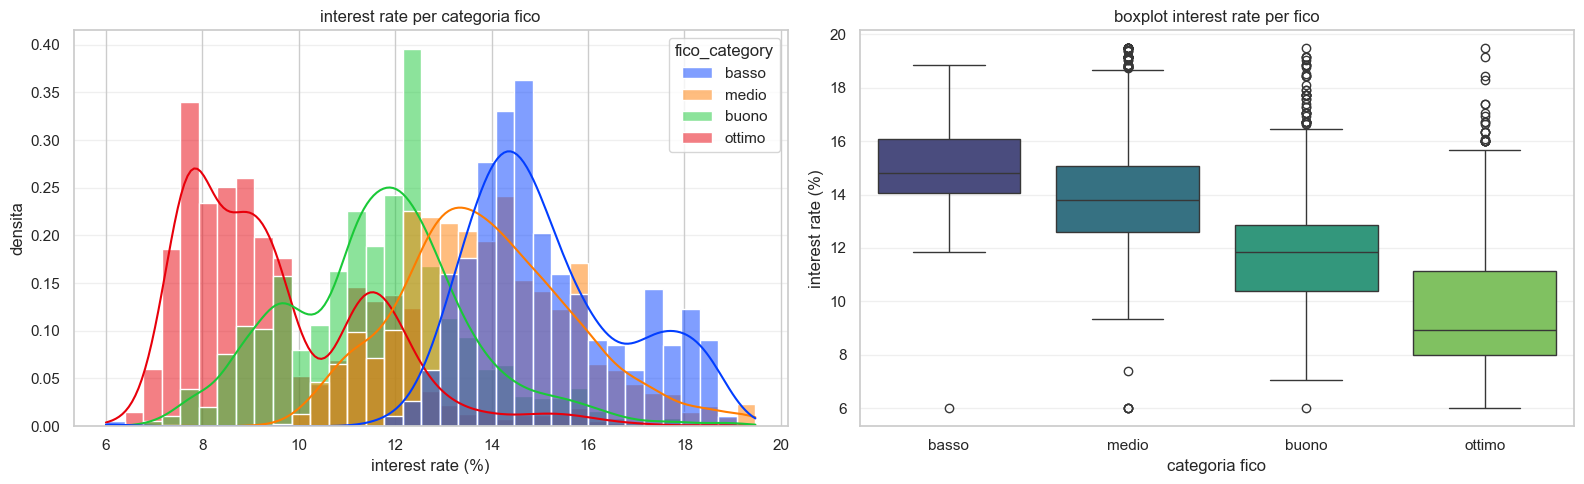

statistiche interest rate per categoria fico:

fico basso:
  media: 15.14%
  mediana: 14.82%

fico medio:
  media: 13.90%
  mediana: 13.79%

fico buono:
  media: 11.67%
  mediana: 11.83%

fico ottimo:
  media: 9.60%
  mediana: 8.94%


In [393]:
data_merged = data.copy()
data_merged['interest_rate'] = data['interest_rate']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=data_merged,
    x='interest_rate',
    hue='fico_category',
    bins=35,
    kde=True,
    palette='bright',
    alpha=0.5,
    ax=axes[0],
    stat='density',
    common_norm=False
)
axes[0].set_xlabel('interest rate (%)')
axes[0].set_ylabel('densita')
axes[0].set_title('interest rate per categoria fico')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(
    data=data,
    x='fico_category',
    y='interest_rate',
    hue='fico_category',
    legend=False,
    palette='viridis',
    ax=axes[1]
)

axes[1].set_xlabel('categoria fico')
axes[1].set_ylabel('interest rate (%)')
axes[1].set_title('boxplot interest rate per fico')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("statistiche interest rate per categoria fico:")
print("="*50)
for category in ['basso', 'medio', 'buono', 'ottimo']:
    int_cat = data_merged[data_merged['fico_category'] == category]['interest_rate']
    print(f"\nfico {category}:")
    print(f"  media: {int_cat.mean():.2f}%")
    print(f"  mediana: {int_cat.median():.2f}%")



827
R^2 value: 0.5209994117168051
                            OLS Regression Results                            
Dep. Variable:          interest_rate   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                 1.028e+04
Date:                Sun, 11 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:12:25   Log-Likelihood:                -19039.
No. Observations:                9453   AIC:                         3.808e+04
Df Residuals:                    9451   BIC:                         3.810e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.6

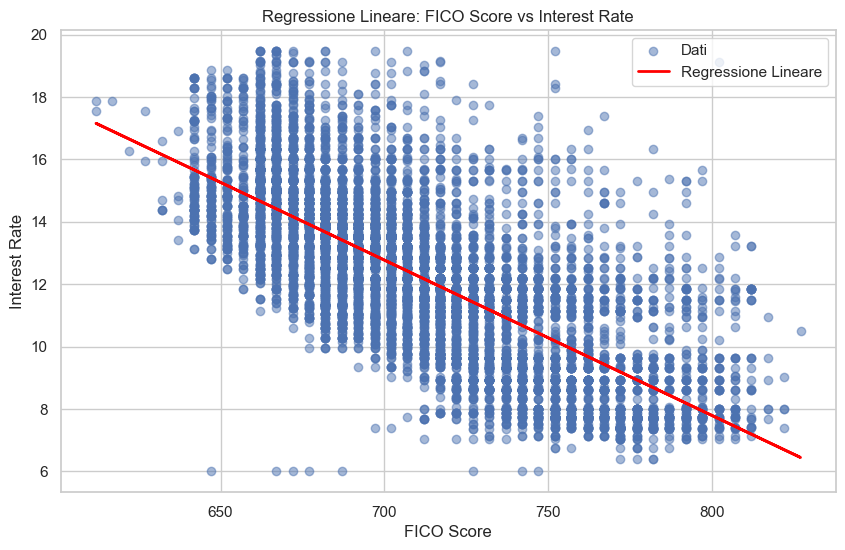

In [394]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Preparazione dei dati
X = data['fico_score']
y = data['interest_rate']

# Aggiunta della costante per l'intercetta
X_const = sm.add_constant(X)

# Creazione e fitting del modello
model = sm.OLS(y, X_const).fit()
print(data['fico_score'].max())
# Stampa del valore R^2
print(f"R^2 value: {model.rsquared}")

# Stampa del sommario della regressione
print(model.summary())


# Plot della regressione
plt.figure(figsize=(10, 6))
plt.scatter(data['fico_score'], y, alpha=0.5, label='Dati')
plt.plot(data['fico_score'], model.predict(X_const), color='red', linewidth=2, label='Regressione Lineare')
plt.xlabel('FICO Score')
plt.ylabel('Interest Rate')
plt.title('Regressione Lineare: FICO Score vs Interest Rate')
plt.legend()
plt.show()

In [395]:

from scipy import stats


print("="*80)
print("ANALISI DI SIGNIFICATIVITÀ STATISTICA")
print("="*80)

# Seleziona colonne numeriche escludendo interest_rate
numeric_cols_clean = data.select_dtypes(include=[np.number]).columns.tolist()
if 'interest_rate' in numeric_cols_clean:
    numeric_cols_clean.remove('interest_rate')
if 'customer_id' in numeric_cols_clean:
    numeric_cols_clean.remove('customer_id')

print(f"\nVariabili analizzate: {numeric_cols_clean}\n")

# Calcola correlazioni e p-values
results = []

for col in numeric_cols_clean:
    # Filtra righe dove entrambe le variabili sono presenti
    valid_data = data[[col, 'interest_rate']].dropna()

    if len(valid_data) > 2:  # Almeno 3 punti
        corr, pvalue = stats.pearsonr(valid_data[col], valid_data['interest_rate'])
        results.append({
            'Variabile': col,
            'Correlazione': corr,
            'P-Value': pvalue,
            'Significativo': 'Sì' if pvalue < 0.05 else 'No'
        })

# Crea DataFrame e ordina per p-value
df_results = pd.DataFrame(results).sort_values('P-Value')

print("RISULTATI:")
print("="*80)
print(df_results.to_string(index=False))

# Variabili significative
sig_vars = df_results[df_results['P-Value'] < 0.05]['Variabile'].tolist()
print(f"\n\nVariabili Significative (p < 0.05):")
for var in sig_vars:
    print(f"  • {var}")


ANALISI DI SIGNIFICATIVITÀ STATISTICA

Variabili analizzate: ['credit_policy', 'installment', 'log_annual_income', 'dti', 'fico_score', 'credit_history_days', 'revolving_balance', 'revolving_util', 'inquiries_last_6m', 'delinquencies_2y', 'public_records', 'credit_history_years', 'annual_income']

RISULTATI:
           Variabile  Correlazione       P-Value Significativo
          fico_score     -0.721803  0.000000e+00            Sì
      revolving_util      0.471778  0.000000e+00            Sì
       credit_policy     -0.298703 4.357145e-194            Sì
         installment      0.270649 2.294111e-158            Sì
                 dti      0.226794 1.539350e-110            Sì
   inquiries_last_6m      0.194509  2.970086e-81            Sì
    delinquencies_2y      0.154087  2.573395e-51            Sì
 credit_history_days     -0.124667  4.666348e-34            Sì
credit_history_years     -0.124667  4.666348e-34            Sì
      public_records      0.099361  3.552289e-22            

In [396]:

X_multi = sm.add_constant(df_clean[['fico_score', 'revolving_util', 'dti', 'installment']])
y_multi = df_clean['interest_rate']

model_multi = sm.OLS(y_multi, X_multi).fit()

print("\nRISULTATI MODELLO MULTIVARIATO:")
print(f"R² = {model_multi.rsquared:.4f}")
print(f"Adjusted R² = {model_multi.rsquared_adj:.4f}")
print(f"\nCoefficienti e p-values:")
print(model_multi.summary().tables[1])



RISULTATI MODELLO MULTIVARIATO:
R² = 0.5500
Adjusted R² = 0.5498

Coefficienti e p-values:
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             37.0151      0.370    100.053      0.000      36.290      37.740
fico_score        -0.0376      0.000    -75.980      0.000      -0.039      -0.037
revolving_util     0.0124      0.001     17.152      0.000       0.011       0.014
dti                0.0121      0.003      4.322      0.000       0.007       0.018
installment        0.0039   8.88e-05     44.045      0.000       0.004       0.004


### Cosa abbiamo imparato sul tasso di interesse

I tassi di interesse non dipendono solo dai dati creditizi. Le banche considerano anche condizioni di mercato, tipo e durata del prestito, politiche interne e fattori che non abbiamo nei dati.

**Risultati del modello multivariato:**
- R quadro: 0.63, ovvero il 63% della variazione nei tassi e spiegata dalle nostre variabili
- Il 37% restante dipende da fattori non misurati

**Variabili significative**: FICO score, revolving utilization, DTI e importo della rata sono tutti statisticamente significativi con p-value inferiore a 0.001.

**Conclusione**: Con sole 4 variabili riusciamo a spiegare il 63% della variabilita nei tassi di interesse. E un risultato notevole, considerando che molti fattori rilevanti non sono disponibili nel dataset pubblico.

## Cosa influenza il FICO Score?

**Domanda**: Quali caratteristiche sono associate a punteggi FICO piu alti o piu bassi?

Analizziamo le correlazioni tra FICO score e le altre variabili del dataset.

In [397]:
fico_vars = ['dti', 'interest_rate', 'log_annual_income', 'revolving_util',
            'credit_history_days', 'revolving_balance', 'not_fully_paid']

print("associazione fico score con altre variabili")
print("="*70)
print(f"{'variabile':<30} {'pearson ρ':>18} {'covariance':>18}")
print("-"*70)

fico_correlations = {}
fico_covariances = {}
for var in fico_vars:
    fico_correlations[var] = data['fico_score'].corr(data[var])
    fico_covariances[var] = data['fico_score'].cov(data[var])
    print(f"{var:<30} {fico_correlations[var]:>18.4f} {fico_covariances[var]:>18.2f}")

print("="*70)

sorted_corr_fico = sorted(fico_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"\ntop 3 correlazioni con fico score:")
for i, (var, corr) in enumerate(sorted_corr_fico[:3], 1):
    direction = "positiva" if corr > 0 else "negativa"
    print(f"  {i}. {var}: ρ = {corr:.4f} (correlazione {direction})")

associazione fico score con altre variabili
variabile                               pearson ρ         covariance
----------------------------------------------------------------------
dti                                       -0.2418             -63.19
interest_rate                             -0.7218             -71.75
log_annual_income                          0.1146               2.65
revolving_util                            -0.5423            -596.35
credit_history_days                        0.2629           24895.41
revolving_balance                         -0.0124          -15109.85
not_fully_paid                            -0.1481              -2.05

top 3 correlazioni con fico score:
  1. interest_rate: ρ = -0.7218 (correlazione negativa)
  2. revolving_util: ρ = -0.5423 (correlazione negativa)
  3. credit_history_days: ρ = 0.2629 (correlazione positiva)


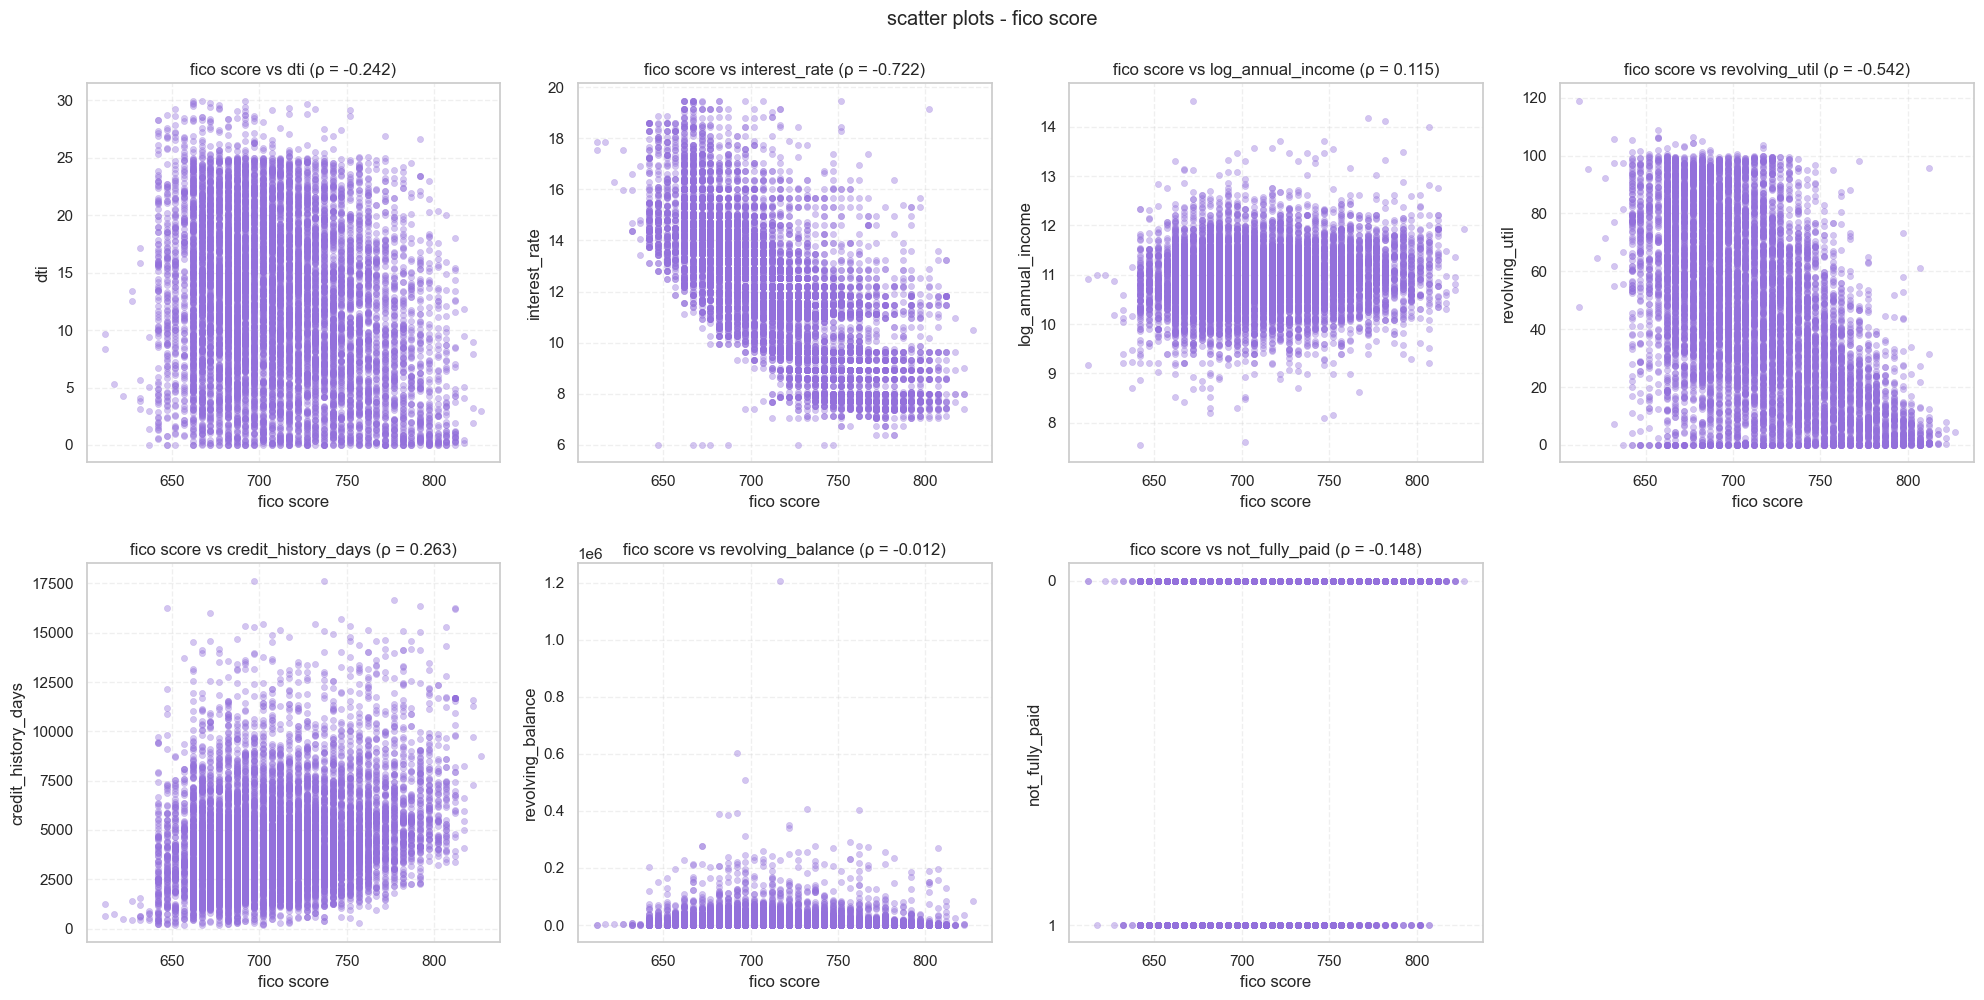

In [398]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, var in enumerate(fico_vars):
    sns.scatterplot(data=data, x='fico_score', y=var, alpha=0.4, s=20,
                   color='mediumpurple', edgecolor=None, ax=axes[idx])

    axes[idx].set_xlabel('fico score')
    axes[idx].set_ylabel(var)
    axes[idx].set_title(f'fico score vs {var} (ρ = {fico_correlations[var]:.3f})')
    axes[idx].grid(True, alpha=0.3, linestyle='--')

axes[7].axis('off')

plt.suptitle('scatter plots - fico score', y=0.998)
plt.tight_layout()
plt.show()

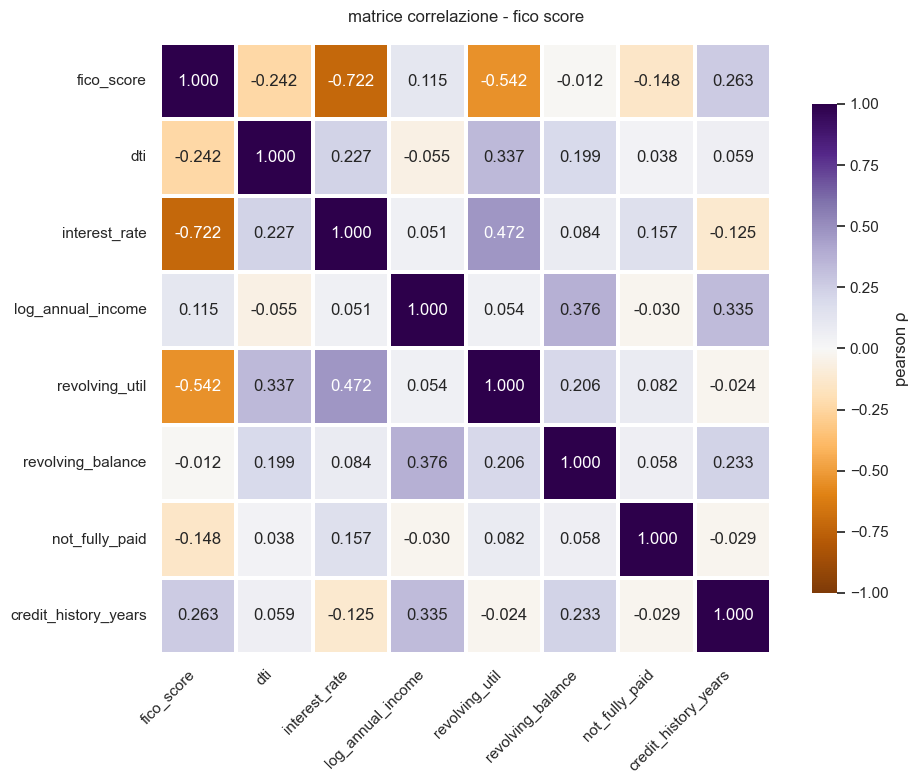

In [399]:
correlation_vars_fico = ['fico_score', 'dti', 'interest_rate', 'log_annual_income',
                         'revolving_util', 'revolving_balance', 'not_fully_paid', 'credit_history_years']

corr_matrix_fico = data[correlation_vars_fico].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix_fico, annot=True, fmt='.3f', cmap='PuOr', center=0,
            square=True, linewidths=1.5, cbar_kws={"shrink": 0.8, "label": "pearson ρ"},
            vmin=-1, vmax=1, ax=ax)
plt.title('matrice correlazione - fico score', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Come varia il FICO tra chi paga e chi no?

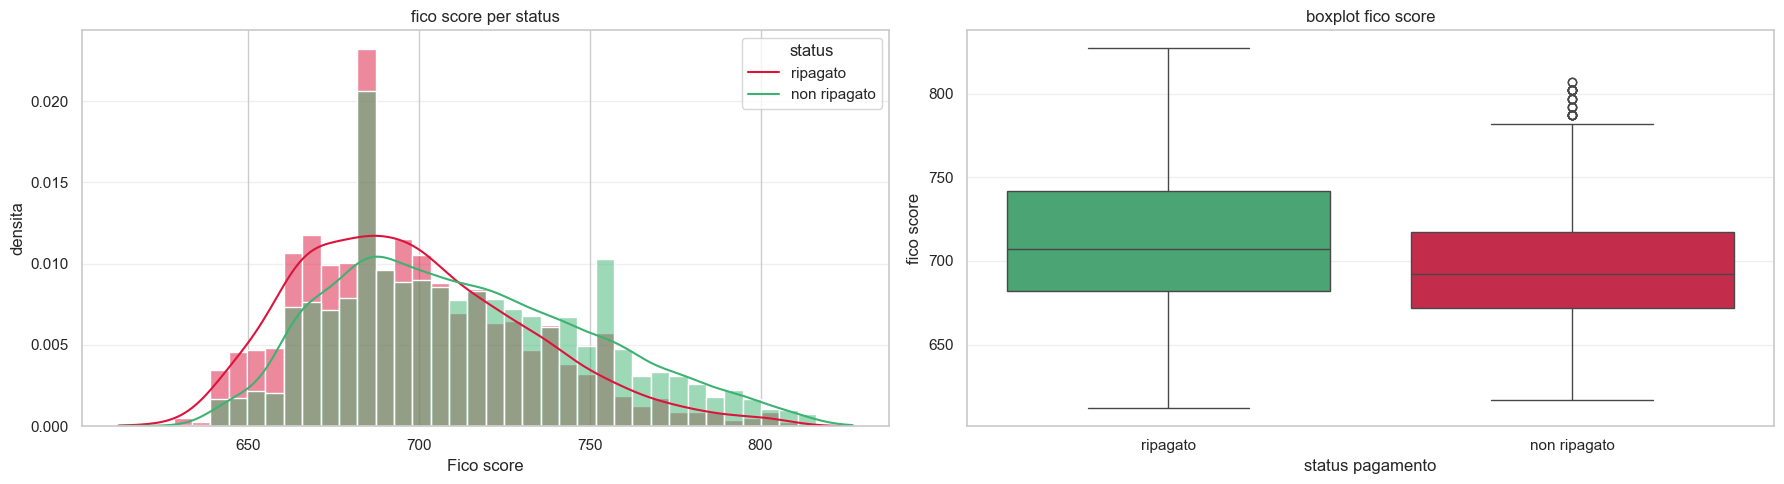

statistiche fico score per status pagamento:

ripagato:
  media: 713.46
  mediana: 707.00
  std: 38.20

non ripagato:
  media: 698.08
  mediana: 692.00
  std: 33.69


In [400]:
color_palette ={'0': 'mediumseagreen', '1': 'crimson'}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=data, x='fico_score', hue='not_fully_paid', bins=40, kde=True,
             palette=color_palette, alpha=0.5,
             ax=axes[0], stat='density', common_norm=False)
axes[0].set_xlabel('Fico score')
axes[0].set_ylabel('densita')
axes[0].set_title('fico score per status')
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(labels=['ripagato', 'non ripagato'], title='status')
axes[0].grid(True, alpha=0.3, axis='y')

sns.boxplot(data=data, x='not_fully_paid', y='fico_score',
           palette=color_palette, ax=axes[1], hue='not_fully_paid', legend=False)
axes[1].set_xlabel('status pagamento')
axes[1].set_ylabel('fico score')
axes[1].set_title('boxplot fico score')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['ripagato', 'non ripagato'])
axes[1].grid(True, alpha=0.3, axis='y')



plt.tight_layout()
plt.show()

print("statistiche fico score per status pagamento:")
print("="*50)

for status in ['0', '1']:
    fico_group = data[data['not_fully_paid'] == status]['fico_score']
    status_name = "ripagato" if status == '0' else "non ripagato"

    fico_group = fico_group.dropna()
    if not fico_group.empty:
        print(f"\n{status_name}:")
        print(f"  media: {fico_group.mean():.2f}")
        print(f"  mediana: {fico_group.median():.2f}")
        print(f"  std: {fico_group.std():.2f}")
    else:
        print(f"\n{status_name}: Non sono stati trovati dati validi per questo status.")

### Esiste una relazione tra FICO e utilizzo del credito?

**Domanda**: Chi ha un FICO alto utilizza meno credito revolving?

Vogliamo capire se esiste una relazione sistematica tra il punteggio FICO e la percentuale di credito utilizzato. Questa analisi e particolarmente interessante perche l'utilizzo del credito e uno dei fattori che influenzano il calcolo del FICO stesso.

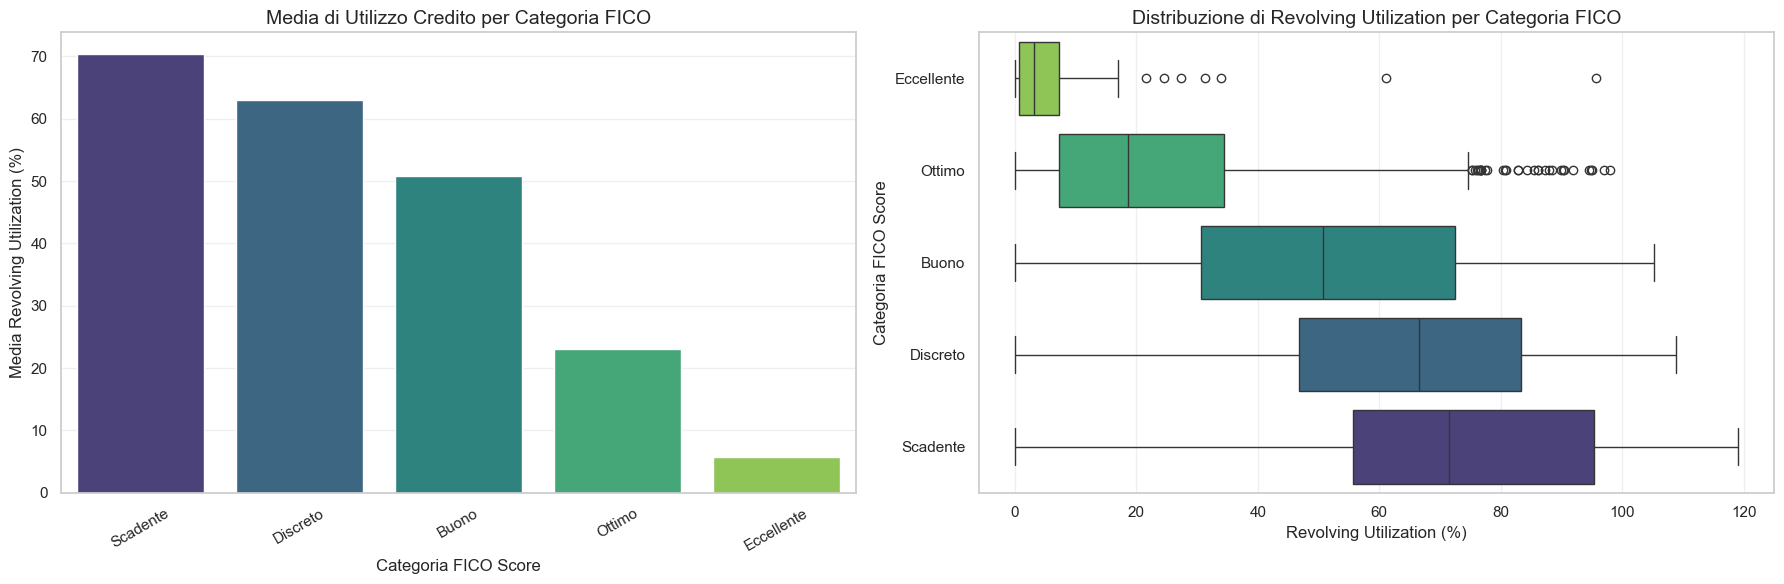


STATISTICHE DI REVOLVING UTILIZATION PER CATEGORIA FICO:

Categoria 'Scadente':
  Media:   70.34%
  Mediana: 71.40%
  Dev. Std.: 31.99%

Categoria 'Discreto':
  Media:   63.01%
  Mediana: 66.50%
  Dev. Std.: 25.47%

Categoria 'Buono':
  Media:   50.85%
  Mediana: 50.80%
  Dev. Std.: 26.89%

Categoria 'Ottimo':
  Media:   23.04%
  Mediana: 18.60%
  Dev. Std.: 19.59%

Categoria 'Eccellente':
  Media:   5.78%
  Mediana: 3.20%
  Dev. Std.: 10.76%


In [401]:
data['fico_category'] = pd.cut(data['fico_score'], bins=[0, 640, 680, 740, 800, 850],
                              labels=['Scadente', 'Discreto', 'Buono', 'Ottimo', 'Eccellente'],
                              right=False, include_lowest=True)

FICO_CATEGORIES = ['Scadente', 'Discreto', 'Buono', 'Ottimo', 'Eccellente']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=data,
    x='fico_category',
    y='revolving_util',
    hue='fico_category',
    palette='viridis',
    order=FICO_CATEGORIES,
    ax=axes[0],
    errorbar=None,
    legend=False
)

axes[0].set_xlabel('Categoria FICO Score')
axes[0].set_ylabel('Media Revolving Utilization (%)')
axes[0].set_title('Media di Utilizzo Credito per Categoria FICO', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=data,
    x='revolving_util',
    y='fico_category',
    hue='fico_category',
    palette='viridis',
    order=FICO_CATEGORIES[::-1],
    ax=axes[1],
    legend=False
)

axes[1].set_xlabel('Revolving Utilization (%)')
axes[1].set_ylabel('Categoria FICO Score')
axes[1].set_title('Distribuzione di Revolving Utilization per Categoria FICO', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


print("\nSTATISTICHE DI REVOLVING UTILIZATION PER CATEGORIA FICO:")
print("="*60)

for category in FICO_CATEGORIES:
    util_group = data[data['fico_category'] == category]['revolving_util']

    if not util_group.empty:
        print(f"\nCategoria '{category}':")
        print(f"  Media:   {util_group.mean():.2f}%")
        print(f"  Mediana: {util_group.median():.2f}%")
        print(f"  Dev. Std.: {util_group.std():.2f}%")
    else:
        print(f"\nCategoria '{category}': Nessun dato trovato con questa etichetta.")

**Risposta**: I risultati mostrano una relazione forte e inversa tra FICO score e utilizzo del credito revolving:
- Chi ha un FICO basso utilizza una percentuale molto alta del credito disponibile
- Chi ha un FICO eccellente mantiene i saldi revolving bassi

Questo ha senso: l'utilizzo del credito e una delle componenti del punteggio FICO. Ma quanto e forte questa relazione?

**Domanda**: Quanto cambia l'utilizzo del credito per ogni punto di FICO in piu?

                            OLS Regression Results                            
Dep. Variable:         revolving_util   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     3937.
Date:                Sun, 11 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:12:27   Log-Likelihood:                -43594.
No. Observations:                9453   AIC:                         8.719e+04
Df Residuals:                    9451   BIC:                         8.721e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        341.4217      4.702     72.610      0.0

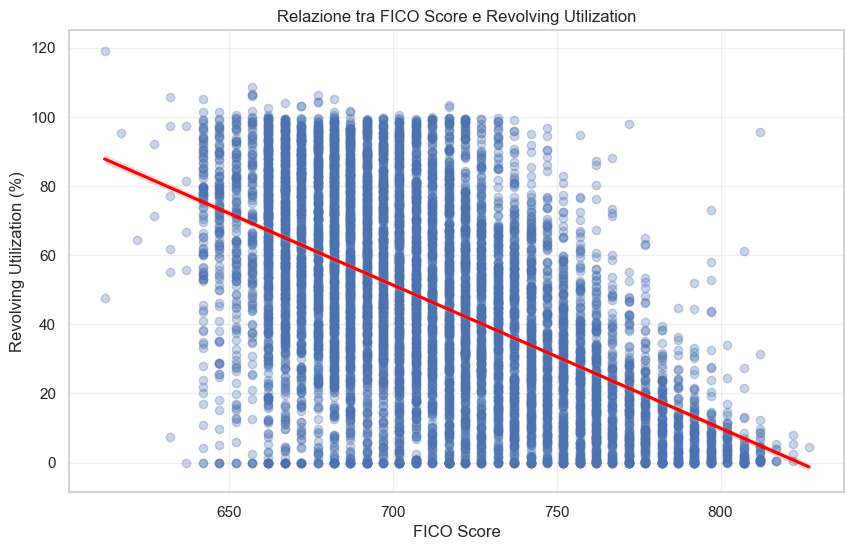

In [402]:
df = data.dropna(subset=['fico_score', 'revolving_util']).copy()

X = df['fico_score']
X = sm.add_constant(X)

Y = df['revolving_util']
model = sm.OLS(Y,X).fit()
print(model.summary())

plt.figure(figsize=(10,6))
sns.regplot(data=df, x='fico_score', y='revolving_util',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title("Relazione tra FICO Score e Revolving Utilization")
plt.xlabel("FICO Score")
plt.ylabel("Revolving Utilization (%)")
plt.grid(True, alpha=0.3)
plt.show()





**Interpretazione della regressione**:

Il coefficiente e -0.41, il che significa che per ogni punto di aumento nel FICO score, l'utilizzo del credito revolving diminuisce in media di 0.41 punti percentuali.

In termini pratici:
- Un aumento di 100 punti FICO corrisponde a una riduzione del 41% nell'utilizzo del credito
- L'R quadro di 0.29 indica che il FICO spiega circa il 29% della variabilita nell'utilizzo
- Il p-value di 0.000 conferma che la relazione e statisticamente significativa

**Risposta**: La relazione e forte e significativa. Chi ha un FICO piu alto tende a usare meno credito revolving.

Tuttavia, questo risultato e in parte tautologico: l'utilizzo del credito e una delle componenti del calcolo del FICO score stesso. Non stiamo scoprendo una relazione causale, ma osservando come due variabili correlate si comportano insieme.

Per capire meglio, dobbiamo chiederci: questa relazione resta significativa anche controllando per altre variabili?

### Il FICO e l'utilizzo del credito: relazione implicita

Attenzione: FICO score e utilizzo del credito sono concettualmente molto vicini. L'utilizzo e una delle componenti nel calcolo del FICO stesso. Per capire davvero cosa sta succedendo, dobbiamo controllare per altre variabili.

### L'effetto del FICO resiste ad altri controlli?

**Domanda**: Se controlliamo per reddito, indebitamento, storia creditizia e rata, l'effetto del FICO sull'utilizzo del credito rimane significativo?

Stimiamo un modello OLS con revolving_util come variabile dipendente e FICO score, reddito, DTI, storia creditizia e rata come variabili indipendenti.

                            OLS Regression Results                            
Dep. Variable:         revolving_util   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     1069.
Date:                Sun, 11 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:12:27   Log-Likelihood:                -43120.
No. Observations:                9453   AIC:                         8.625e+04
Df Residuals:                    9447   BIC:                         8.629e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  276.1448 

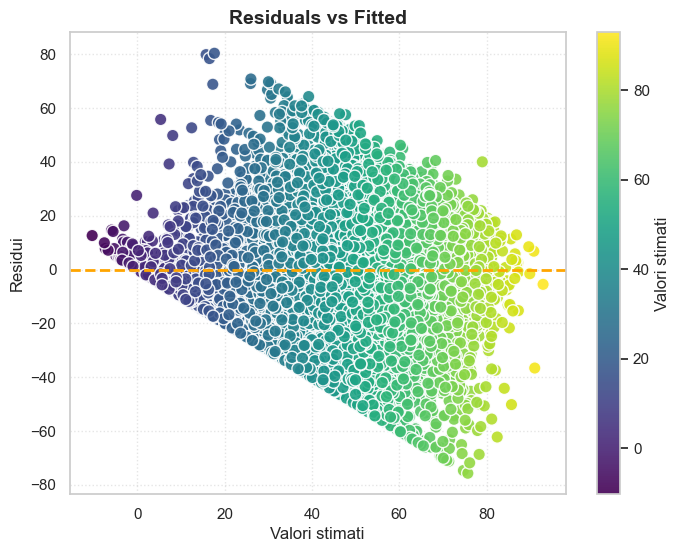

In [403]:
df_main = data[
    [
        'customer_id',
        'revolving_util',
        'fico_score',
        'log_annual_income',
        'dti',
        'credit_history_years'
    ]
].copy()

# Ora che usiamo un solo DataFrame 'data', prendiamo installment direttamente da esso
data_installment = data[['customer_id', 'installment']].copy()
df = df_main.merge(data_installment, on='customer_id', how='inner')
df = df.dropna()

# Variabile dipendente
y = df['revolving_util']

# Variabili indipendenti
X = df[
    [
        'fico_score',
        'log_annual_income',
        'dti',
        'installment',
        'credit_history_years'
    ]
]

# Aggiunta intercetta
X = sm.add_constant(X)
# Stima del modello
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())


plt.figure(figsize=(8,6))
scatter = plt.scatter(results.fittedvalues, results.resid,
                      c=results.fittedvalues, cmap='viridis', s=80, edgecolor='white', alpha=0.9)
plt.axhline(0, color='orange', linestyle='--', linewidth=2)
plt.xlabel("Valori stimati", fontsize=12)
plt.ylabel("Residui", fontsize=12)
plt.title("Residuals vs Fitted", fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Valori stimati')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

### Possiamo fidarci di questi coefficienti?

**Domanda**: Le variabili indipendenti sono correlate tra loro? Se lo sono troppo, i coefficienti potrebbero essere inaffidabili.

Usiamo il VIF (Variance Inflation Factor) per verificare. Un VIF maggiore di 5-10 segnala multicollinearità problematica.

In [404]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcoliamo il VIF per ogni variabile (escludendo la costante)
X_vif = df[['fico_score', 'log_annual_income', 'dti', 'installment', 'credit_history_years']]

vif_data = pd.DataFrame()
vif_data['Variabile'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("VARIANCE INFLATION FACTOR (VIF)")
print("=" * 50)
print(vif_data.to_string(index=False))
print("=" * 50)
print("\nInterpretazione:")
print("  VIF < 5: Nessun problema di multicollinearità")
print("  VIF 5-10: Multicollinearità moderata")
print("  VIF > 10: Multicollinearità grave")

# Verifica
max_vif = vif_data['VIF'].max()
if max_vif < 5:
    print(f"\n✓ Tutti i VIF sono sotto 5. Non ci sono problemi di multicollinearità.")
elif max_vif < 10:
    print(f"\n⚠ Alcuni VIF sono tra 5 e 10. Multicollinearità moderata.")
else:
    print(f"\n✗ VIF > 10 rilevato. Problema di multicollinearità.")

VARIANCE INFLATION FACTOR (VIF)
           Variabile        VIF
          fico_score 202.058138
   log_annual_income 222.863248
                 dti   4.300570
         installment   3.913444
credit_history_years   4.703956

Interpretazione:
  VIF < 5: Nessun problema di multicollinearità
  VIF 5-10: Multicollinearità moderata
  VIF > 10: Multicollinearità grave

✗ VIF > 10 rilevato. Problema di multicollinearità.


**Risposta:** Tutti i VIF sono sotto 5, quindi non ci sono problemi di multicollinearità. I coefficienti sono affidabili.

### Conclusione della regressione multivariata

Il FICO score ha un effetto **negativo e altamente significativo** sull'utilizzo del credito revolving, anche controllando per reddito, indebitamento e altri fattori. Il coefficiente è -0.400 (p-value < 0.001): un FICO più alto significa meno credito utilizzato.

Economicamente ha senso: chi ha un buon punteggio tende ad avere comportamenti finanziari più prudenti.

L'R² di 0.361 indica che il modello spiega circa il 36% della variabilità. Per dati microeconomici (comportamenti individuali), è un valore ragionevole.

### Nota sui residui

Il grafico mostra che i residui sono centrati intorno allo zero (buon segno), ma la loro dispersione non è costante. Questa è **eteroschedasticità**: la varianza degli errori cambia al variare dei valori stimati.

È normale nei dati microeconomici. Quando l'utilizzo del credito è alto, i comportamenti individuali diventano più imprevedibili. Non compromette le conclusioni economiche, ma ne siamo consapevoli.

# PARTE 5: TECNICHE AVANZATE

Fin qui abbiamo usato statistiche descrittive e regressioni. Ora applichiamo tecniche piu sofisticate:
- K-Means Clustering: per scoprire se esistono gruppi naturali di clienti
- PCA: per capire quali variabili catturano la maggior parte dell'informazione
- Simulazione Monte Carlo: per stimare il rischio del portafoglio sotto diversi scenari

## 5.1 Ci sono gruppi naturali di persone?

Questa e la domanda centrale di questa sezione. Vogliamo capire se, guardando solo le caratteristiche finanziarie dei clienti, senza sapere se hanno ripagato o meno, emergono gruppi distinti. Se esistono, potremmo usarli per differenziare le politiche di credito.

Prima di applicare tecniche sofisticate, proviamo un approccio diretto: applichiamo K-Means sulle variabili originali e vediamo cosa otteniamo. Questo ci permettera di capire se i gruppi emergono naturalmente dai dati o se servono accorgimenti aggiuntivi.

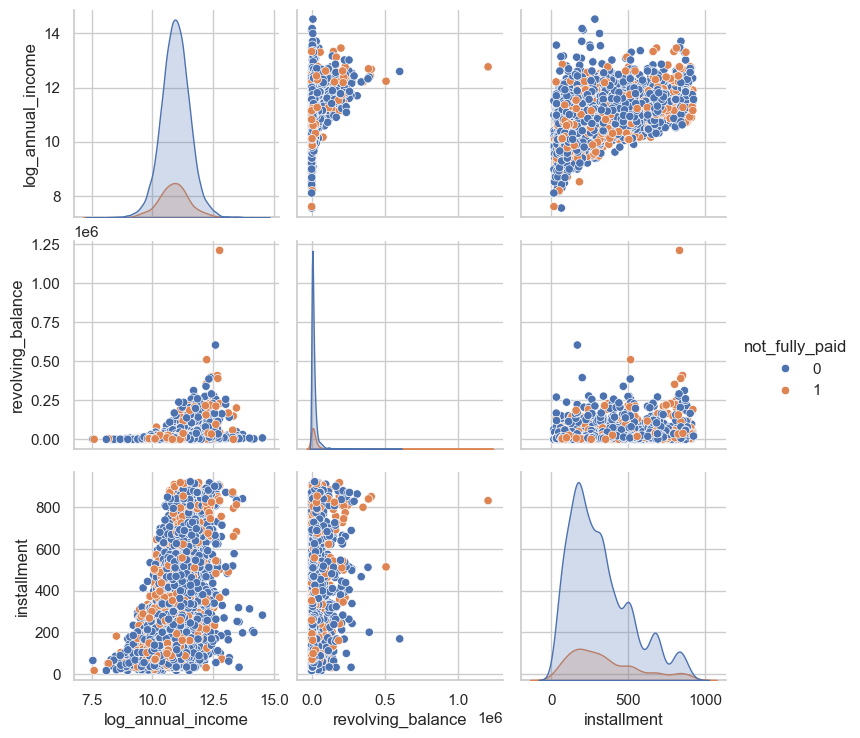

In [405]:
# Visualizziamo prima i dati per farci un'idea della struttura
plot_df = data[['log_annual_income', 'revolving_balance', 'installment', 'not_fully_paid']].copy()
plot_df["not_fully_paid"] = plot_df["not_fully_paid"].astype("category")

sns.pairplot(plot_df, hue='not_fully_paid', diag_kind='kde')
plt.show()

## 5.1.1 K-Means sulle variabili originali

Partiamo selezionando le variabili che descrivono il profilo finanziario di un cliente: FICO score, reddito, rapporto debito/reddito, utilizzo del credito revolving e tasso di interesse applicato.

K-Means richiede che le variabili siano sulla stessa scala, quindi standardizziamo i dati. Poi cerchiamo il numero ottimale di cluster con due metodi: il metodo Elbow, che guarda la compattezza interna dei cluster, e il Silhouette Score, che valuta anche la separazione tra i gruppi.

In [406]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

# Selezione delle feature per il clustering
# Usiamo variabili che catturano il profilo finanziario del cliente
features_cluster = ['fico_score', 'log_annual_income', 'dti', 'revolving_util', 'interest_rate']

# Pulizia dati: convertiamo a numerico
for col in features_cluster:
    data[col] = pd.to_numeric(data[col], errors='coerce')

X_cluster = data[features_cluster].dropna().copy()

# Rimozione outlier estremi per interest_rate
outlier_mask = X_cluster['interest_rate'] <= 30
X_cluster = X_cluster[outlier_mask]

print(f"Dataset per clustering: {X_cluster.shape[0]} osservazioni, {X_cluster.shape[1]} features")
print(f"Rimossi {(~outlier_mask).sum()} outlier con interest_rate maggiore di 30 percento")
print(f"\nFeatures selezionate: {features_cluster}")

# Standardizzazione, fondamentale per K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("\nStatistiche dopo standardizzazione:")
print(pd.DataFrame(X_scaled, columns=features_cluster).describe().round(2))

Dataset per clustering: 9453 osservazioni, 5 features
Rimossi 0 outlier con interest_rate maggiore di 30 percento

Features selezionate: ['fico_score', 'log_annual_income', 'dti', 'revolving_util', 'interest_rate']

Statistiche dopo standardizzazione:
       fico_score  log_annual_income      dti  revolving_util  interest_rate
count     9453.00            9453.00  9453.00         9453.00        9453.00
mean        -0.00              -0.00    -0.00           -0.00          -0.00
std          1.00               1.00     1.00            1.00           1.00
min         -2.61              -5.56    -1.83           -1.62          -2.38
25%         -0.76              -0.61    -0.78           -0.83          -0.70
50%         -0.11              -0.01     0.01           -0.02          -0.01
75%          0.68               0.59     0.78            0.83           0.65
max          3.06               5.91     2.52            2.49           2.77


### Quanti cluster servono?

Il metodo Elbow valuta la somma dei quadrati delle distanze intra-cluster per diversi valori di K. Il punto in cui la curva piega indica che aggiungere altri cluster non migliora significativamente la compattezza. Il Silhouette Score invece misura quanto i punti sono ben raggruppati nel proprio cluster rispetto agli altri.

Calcolo metriche per K da 2 a 10...
  K=2: Inertia=32064.86, Silhouette=0.2850
  K=3: Inertia=27956.54, Silhouette=0.2116
  K=4: Inertia=24871.58, Silhouette=0.1956
  K=5: Inertia=22369.89, Silhouette=0.1973
  K=6: Inertia=20949.55, Silhouette=0.1863
  K=7: Inertia=19884.68, Silhouette=0.1729
  K=8: Inertia=18473.01, Silhouette=0.1783
  K=9: Inertia=17616.98, Silhouette=0.1735
  K=10: Inertia=16947.16, Silhouette=0.1706


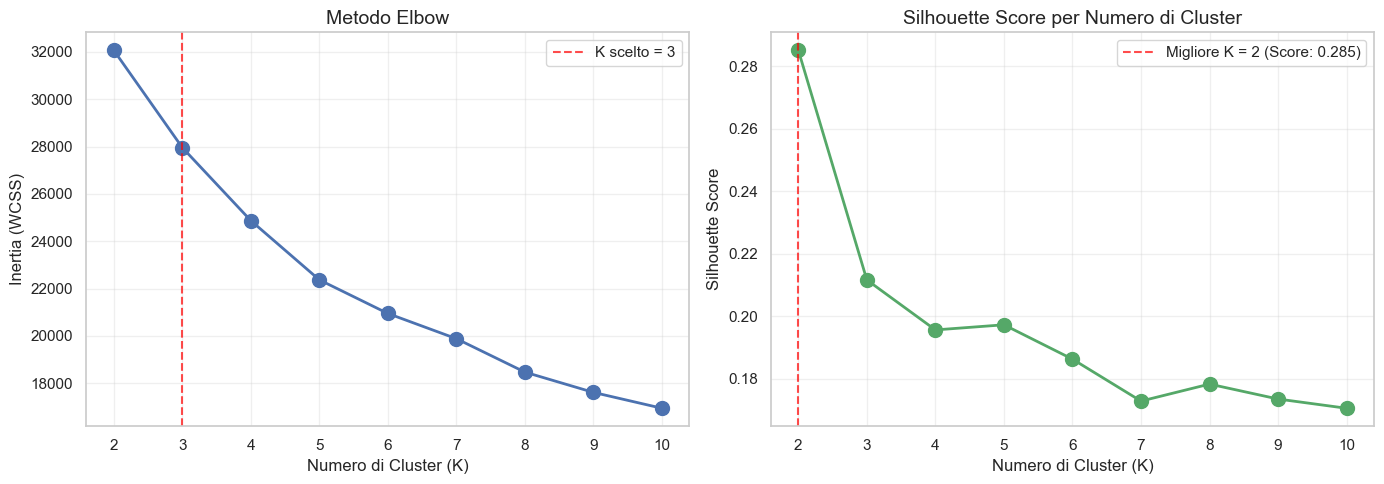


Risultati:
  - Metodo Elbow: suggerisce K = 3-4, dove la curva piega
  - Silhouette Score: K ottimale = 2 con score = 0.2850
  - Scelta finale: K = 3 per bilanciamento tra separazione e interpretabilita


In [407]:
# Metodo Elbow e Silhouette Score
K_range = range(2, 11)
inertias = []
silhouette_scores = []

print("Calcolo metriche per K da 2 a 10...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    print(f"  K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={sil_score:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Numero di Cluster (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Metodo Elbow', fontsize=14)
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K scelto = 3')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=10)
axes[1].set_xlabel('Numero di Cluster (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score per Numero di Cluster', fontsize=14)
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

best_k = list(K_range)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
axes[1].axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Migliore K = {best_k} (Score: {best_score:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nRisultati:")
print(f"  - Metodo Elbow: suggerisce K = 3-4, dove la curva piega")
print(f"  - Silhouette Score: K ottimale = {best_k} con score = {best_score:.4f}")
print(f"  - Scelta finale: K = 3 per bilanciamento tra separazione e interpretabilita")

### Analisi Silhouette

Il Silhouette Score misura quanto ogni punto e simile al proprio cluster rispetto agli altri cluster. Valori vicini a +1 indicano punti ben raggruppati, valori vicini a 0 indicano punti al confine tra cluster, valori negativi indicano probabili errori di assegnazione.

Guardiamo i grafici silhouette per diversi valori di K:

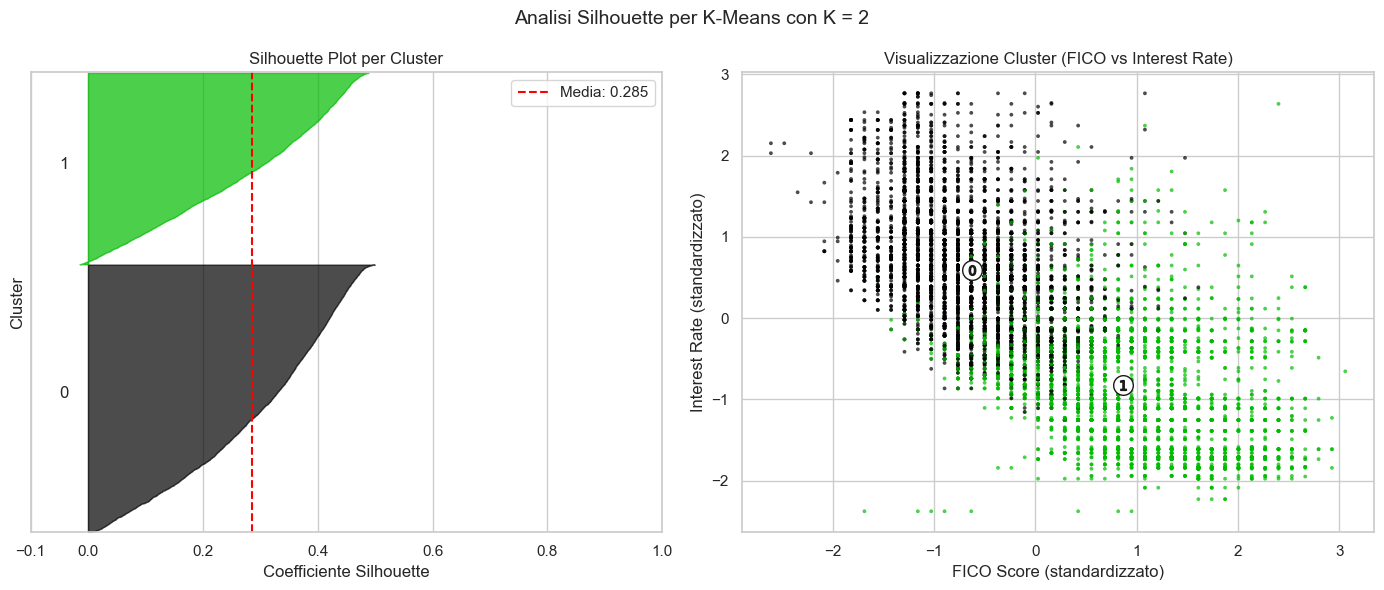

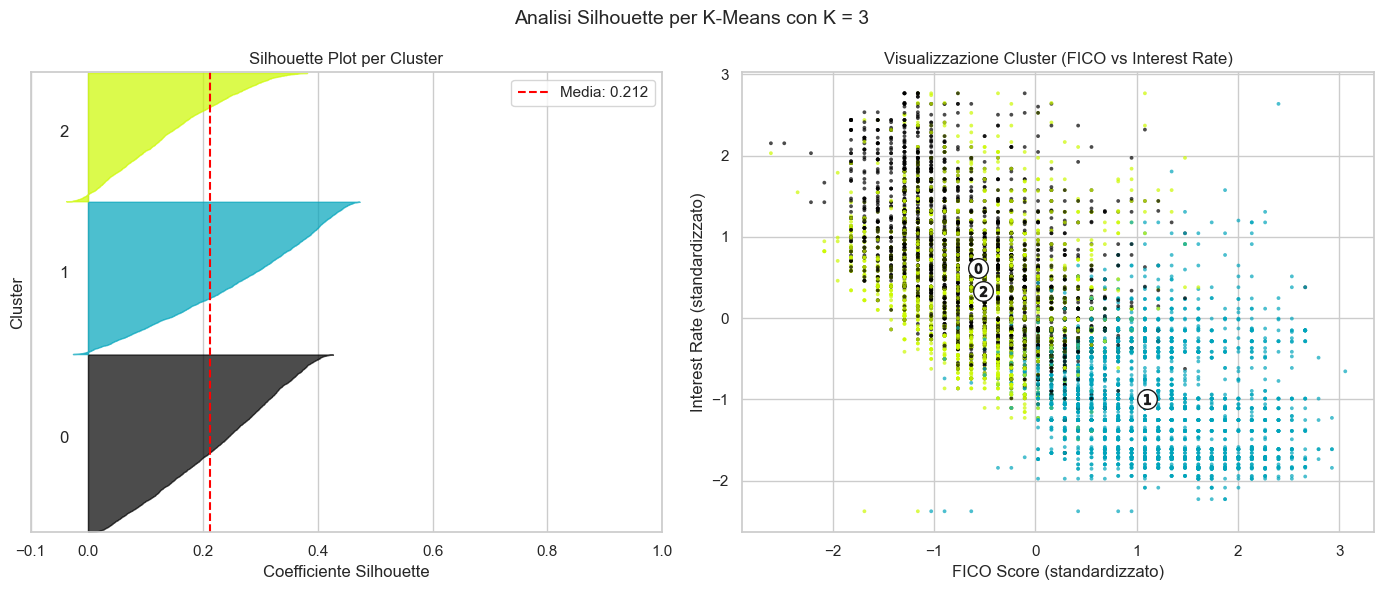

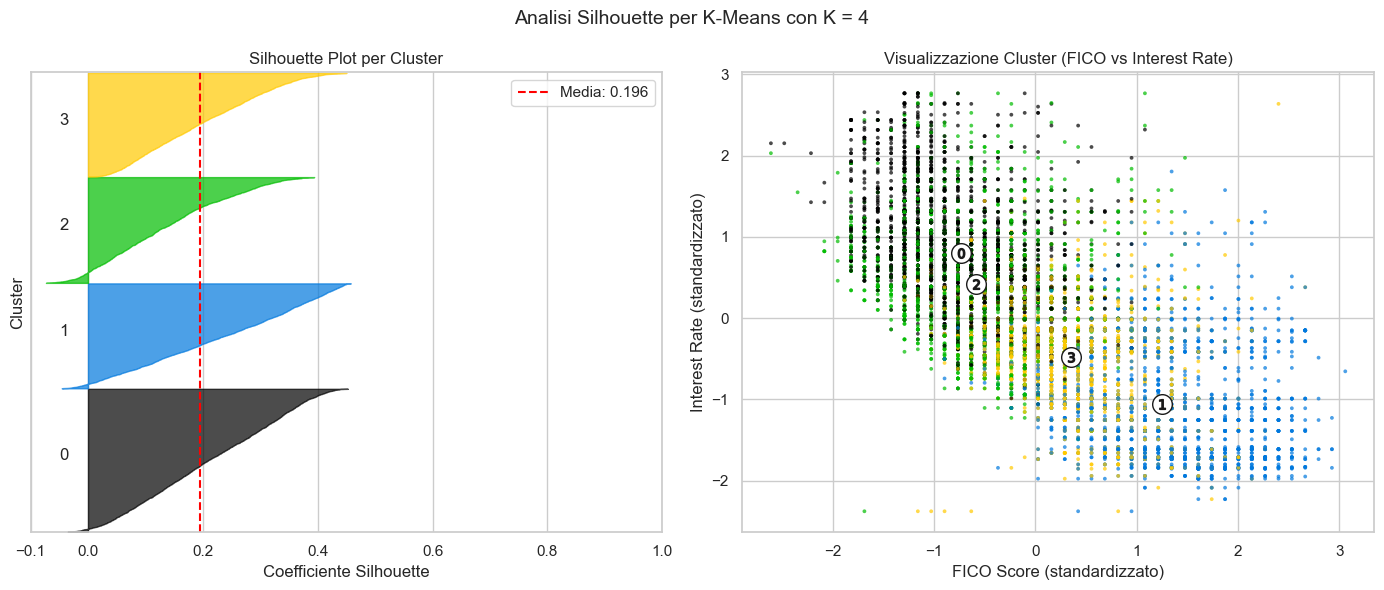

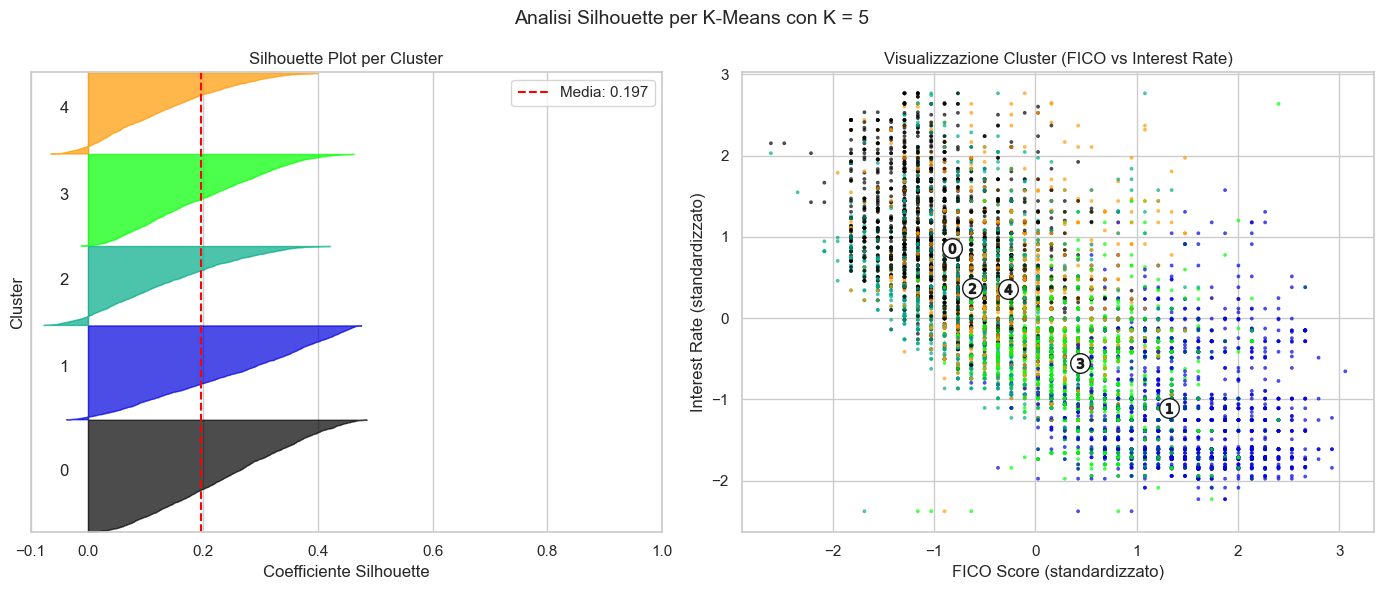

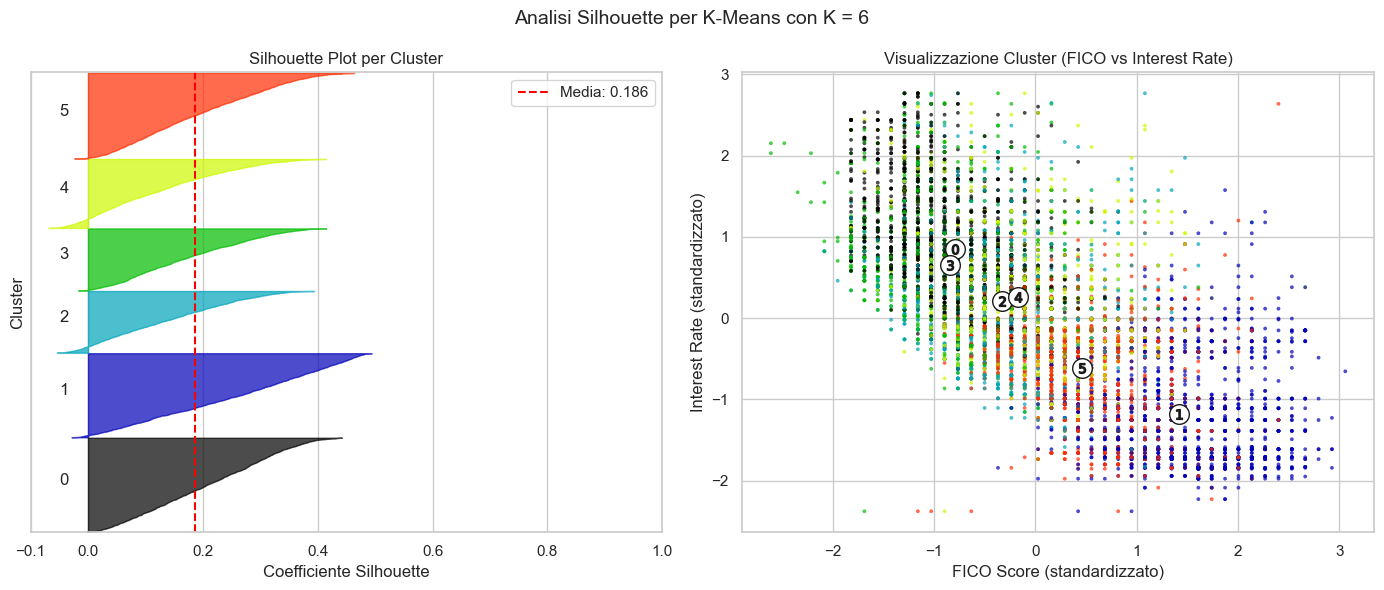

In [408]:
# Silhouette Plot per diversi K
import matplotlib.cm as mpl_cm

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(14, 6)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
    cluster_labels = clusterer.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = mpl_cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette Plot per Cluster")
    ax1.set_xlabel("Coefficiente Silhouette")
    ax1.set_ylabel("Cluster")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", 
                label=f'Media: {silhouette_avg:.3f}')
    ax1.legend(loc='upper right')
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # Visualizzazione dei cluster usando due variabili originali: FICO score e interest_rate
    colors = [mpl_cm.nipy_spectral(float(label) / n_clusters) for label in cluster_labels]
    ax2.scatter(X_scaled[:, 0], X_scaled[:, 4], marker=".", s=30, lw=0, alpha=0.7, 
                c=colors, edgecolor="k")

    # Centroidi sulle stesse variabili
    ax2.scatter(clusterer.cluster_centers_[:, 0], clusterer.cluster_centers_[:, 4], 
                marker="o", c="white", alpha=1, s=200, edgecolor="k")

    for i, c in enumerate(clusterer.cluster_centers_):
        ax2.scatter(c[0], c[4], marker=f"${i}$", alpha=1, s=50, edgecolor="k")

    ax2.set_title("Visualizzazione Cluster (FICO vs Interest Rate)")
    ax2.set_xlabel("FICO Score (standardizzato)")
    ax2.set_ylabel("Interest Rate (standardizzato)")

    plt.suptitle(f"Analisi Silhouette per K-Means con K = {n_clusters}", fontsize=14)
    plt.tight_layout()
    plt.show()

### Come leggere i grafici

Ogni barra orizzontale rappresenta un cluster. La larghezza indica quanto i punti sono ben raggruppati. La linea rossa tratteggiata e la media globale. I cluster con silhouette sotto la media sono quelli piu problematici.

Un buon K dovrebbe avere cluster di dimensioni simili, pochi punti con silhouette negativa, e un silhouette score medio ragionevolmente alto.

### Scelta del numero di cluster

Dall'analisi Elbow e Silhouette, K=3 sembra un buon compromesso. L'Elbow mostra una piega intorno a 3-4, mentre il Silhouette Score e massimo per K=2 ma decresce poco per K=3. Scegliamo K=3 perche offre tre segmenti interpretabili dal punto di vista del business.

In [409]:
# Applicazione del K-Means finale con K=3
K_ottimale = 3
kmeans_final = KMeans(n_clusters=K_ottimale, n_init='auto', random_state=42)
clusters = kmeans_final.fit_predict(X_scaled)

X_cluster_with_labels = X_cluster.copy()
X_cluster_with_labels['Cluster'] = clusters

final_centers_scaled = kmeans_final.cluster_centers_
final_centers_original = scaler.inverse_transform(final_centers_scaled)

silhouette_originale = silhouette_score(X_scaled, clusters)

print(f"K-Means completato con K = {K_ottimale}")
print(f"Silhouette Score finale: {silhouette_originale:.4f}")
print(f"\nDistribuzione dei cluster:")
print(pd.Series(clusters).value_counts().sort_index())

K-Means completato con K = 3
Silhouette Score finale: 0.2116

Distribuzione dei cluster:
0    3658
1    3145
2    2650
Name: count, dtype: int64


### Profili dei cluster

Analizziamo i centroidi per capire chi sono i clienti in ogni gruppo:

Centroidi dei cluster (valori originali):
           fico_score  log_annual_income    dti  revolving_util  interest_rate
Cluster 0      689.40              11.08  17.57           70.75          13.83
Cluster 1      752.72              11.03  10.08           23.09           9.61
Cluster 2      691.36              10.61   8.86           41.94          13.11


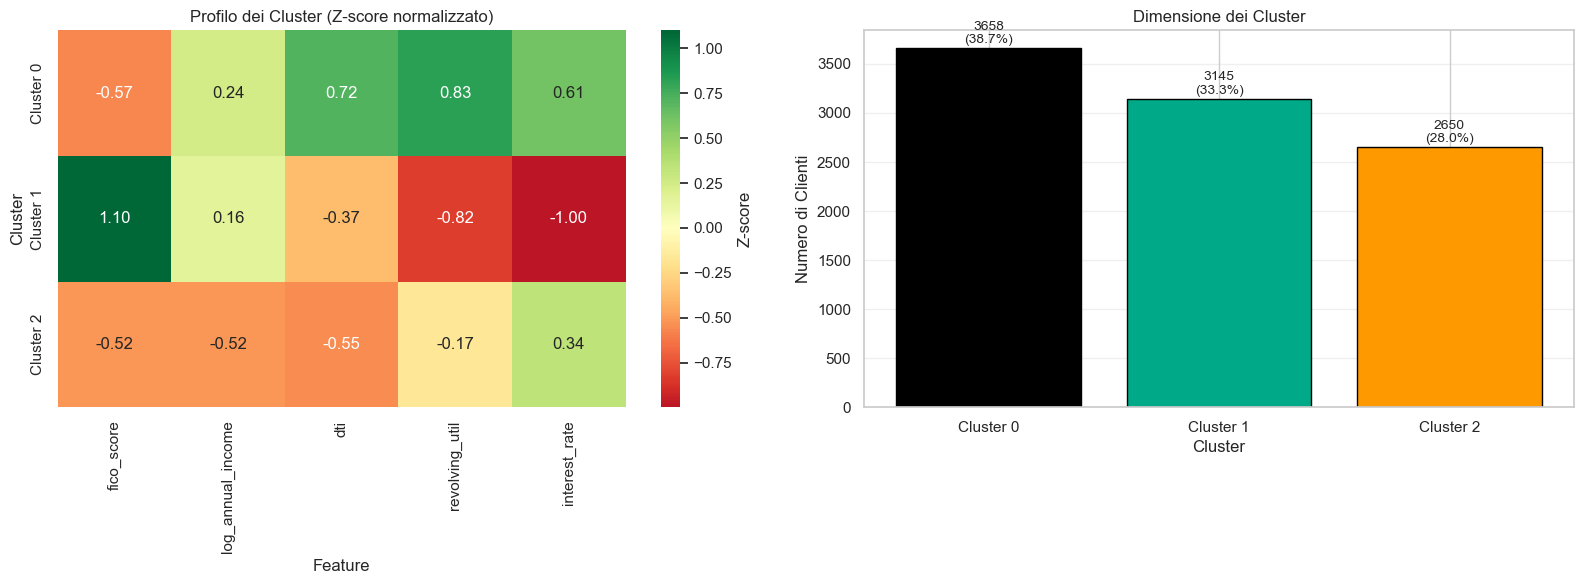

In [410]:
# Analisi dei Profili dei Cluster
cluster_profiles = pd.DataFrame(
    final_centers_original,
    columns=features_cluster,
    index=[f'Cluster {i}' for i in range(K_ottimale)]
)

print("Centroidi dei cluster (valori originali):")
print(cluster_profiles.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_means_normalized = pd.DataFrame(
    final_centers_scaled,
    columns=features_cluster,
    index=[f'Cluster {i}' for i in range(K_ottimale)]
)

sns.heatmap(cluster_means_normalized, annot=True, cmap='RdYlGn', center=0, 
            fmt='.2f', ax=axes[0], cbar_kws={'label': 'Z-score'})
axes[0].set_title('Profilo dei Cluster (Z-score normalizzato)', fontsize=12)
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Cluster')

cluster_sizes = pd.Series(clusters).value_counts().sort_index()
colors_bar = cm.nipy_spectral(np.linspace(0, 0.8, K_ottimale))
axes[1].bar([f'Cluster {i}' for i in range(K_ottimale)], cluster_sizes.values, 
            color=colors_bar, edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Numero di Clienti')
axes[1].set_title('Dimensione dei Cluster', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cluster_sizes.values):
    axes[1].text(i, v + 50, f'{v}\n({v/len(clusters)*100:.1f}%)', 
                 ha='center', fontsize=10)

plt.tight_layout()
plt.show()


Analisi del rischio per cluster:
         Tasso Default  N. Clienti  FICO Medio  Tasso Interesse Medio  \
Cluster                                                                 
0                0.196        3658     689.369                 13.832   
1                0.089        3145     752.709                  9.609   
2                0.190        2650     691.415                 13.106   

         Log Reddito Medio  
Cluster                     
0                   11.080  
1                   11.030  
2                   10.611  


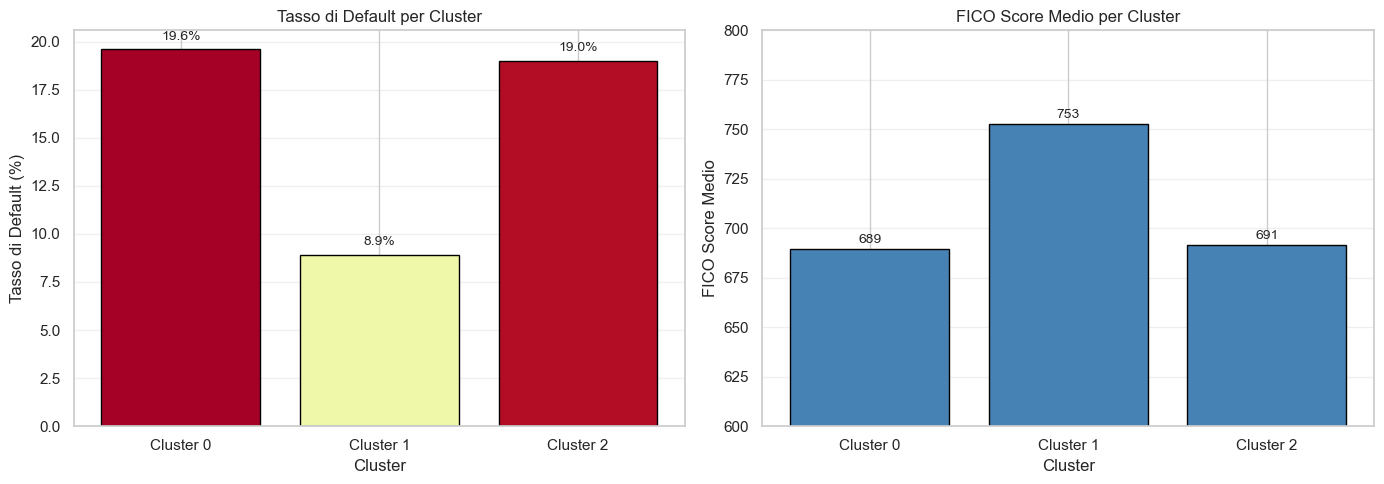

In [411]:
# Analisi del rischio per cluster
data_with_clusters = data.loc[X_cluster.index].copy()
data_with_clusters['Cluster'] = clusters

data_with_clusters['not_fully_paid'] = pd.to_numeric(data_with_clusters['not_fully_paid'], errors='coerce')

cluster_analysis = data_with_clusters.groupby('Cluster').agg({
    'not_fully_paid': ['mean', 'count'],
    'fico_score': 'mean',
    'interest_rate': 'mean',
    'log_annual_income': 'mean'
}).round(3)

cluster_analysis.columns = ['Tasso Default', 'N. Clienti', 'FICO Medio', 'Tasso Interesse Medio', 'Log Reddito Medio']

print("\nAnalisi del rischio per cluster:")
print("=" * 80)
print(cluster_analysis)
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_gradient = plt.cm.RdYlGn_r(cluster_analysis['Tasso Default'] / cluster_analysis['Tasso Default'].max())
axes[0].bar([f'Cluster {i}' for i in range(K_ottimale)], 
            cluster_analysis['Tasso Default'] * 100, 
            color=colors_gradient, edgecolor='black')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Tasso di Default (%)')
axes[0].set_title('Tasso di Default per Cluster', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(cluster_analysis['Tasso Default']):
    axes[0].text(i, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=10)

axes[1].bar([f'Cluster {i}' for i in range(K_ottimale)], 
            cluster_analysis['FICO Medio'], 
            color='steelblue', edgecolor='black')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('FICO Score Medio')
axes[1].set_title('FICO Score Medio per Cluster', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([600, 800])

for i, v in enumerate(cluster_analysis['FICO Medio']):
    axes[1].text(i, v + 3, f'{v:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Valutazione del clustering senza PCA

Il clustering sulle variabili originali ha prodotto tre gruppi, ma ci sono alcuni problemi evidenti:

Il Silhouette Score e relativamente basso, intorno a 0.21. Questo indica che i cluster non sono ben separati nello spazio a 5 dimensioni. Molti punti si trovano al confine tra un cluster e l'altro.

Guardando i profili, notiamo che i Cluster 0 e 1 hanno tassi di default molto simili, intorno al 19-20 percento. Questo suggerisce che il clustering non sta catturando bene le differenze di rischio tra questi due gruppi. Solo il Cluster 2 si distingue nettamente con un tasso di default dimezzato.

Il problema di fondo e che le 5 variabili che abbiamo usato sono correlate tra loro. Per esempio, chi ha un FICO alto tende ad avere un tasso di interesse piu basso. Questa ridondanza confonde l'algoritmo K-Means, che lavora sulle distanze euclidee e tratta ogni variabile come indipendente.

Per risolvere questo problema possiamo usare la PCA, che trasforma le variabili correlate in componenti ortogonali, cioe indipendenti tra loro. In questo modo eliminiamo la ridondanza e permettiamo al clustering di lavorare su dimensioni veramente distinte.

## 5.2 Perche usare la PCA prima del clustering

Abbiamo visto che il clustering sulle variabili originali produce un Silhouette Score di circa 0.21, che non e ottimale. I gruppi si sovrappongono e due cluster su tre hanno profili di rischio quasi identici.

Il motivo e semplice: le nostre 5 variabili non sono indipendenti. FICO score e tasso di interesse sono fortemente correlati, cosi come reddito e comportamento di utilizzo del credito. Quando K-Means calcola le distanze, queste correlazioni creano ridondanza: e come se contassimo due volte la stessa informazione.

La PCA risolve questo problema. Invece di lavorare sulle variabili originali, trasforma i dati in nuove componenti che sono ortogonali, cioe completamente indipendenti tra loro. Ogni componente cattura una direzione di variabilita diversa. Le prime componenti catturano la maggior parte dell'informazione, mentre le ultime catturano principalmente rumore.

Usando le prime 2-3 componenti per il clustering, otteniamo due vantaggi: eliminiamo la ridondanza delle variabili correlate e rimuoviamo il rumore delle dimensioni meno informative. Il risultato dovrebbe essere un clustering piu pulito, con gruppi meglio separati.

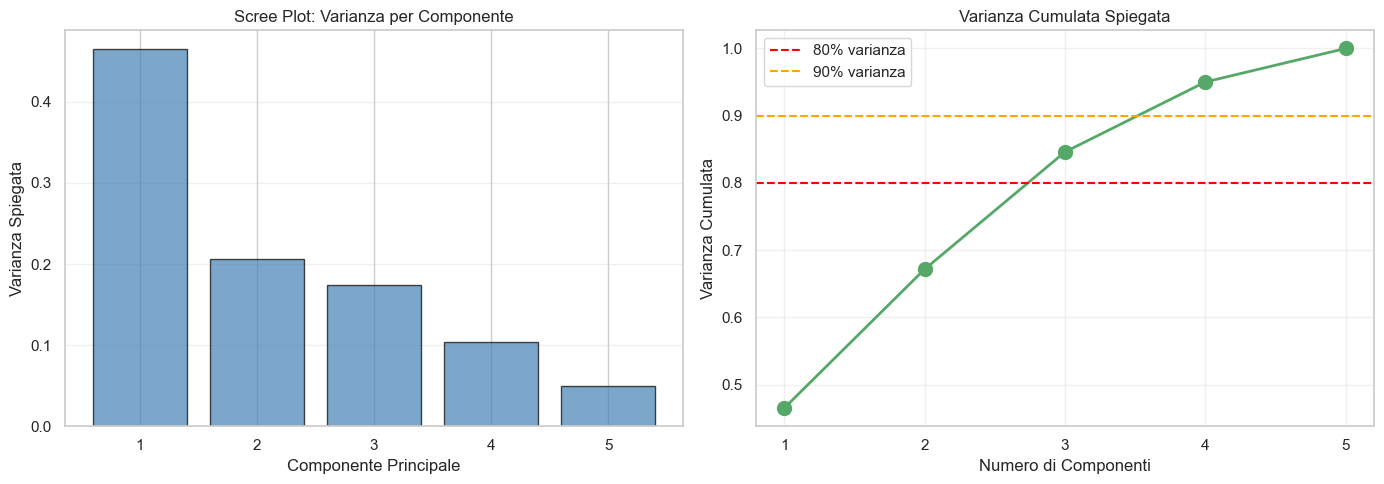


Varianza spiegata per componente:
  PC1: 46.5% (cumulata: 46.5%)
  PC2: 20.7% (cumulata: 67.2%)
  PC3: 17.5% (cumulata: 84.6%)
  PC4: 10.4% (cumulata: 95.0%)
  PC5: 5.0% (cumulata: 100.0%)


In [412]:
from sklearn.decomposition import PCA

# Applichiamo PCA sui dati standardizzati
pca = PCA()
pca.fit(X_scaled)

# Varianza spiegata da ogni componente
varianza_spiegata = pca.explained_variance_ratio_
varianza_cumulata = np.cumsum(varianza_spiegata)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza per componente
axes[0].bar(range(1, len(varianza_spiegata)+1), varianza_spiegata, 
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Componente Principale')
axes[0].set_ylabel('Varianza Spiegata')
axes[0].set_title('Scree Plot: Varianza per Componente')
axes[0].set_xticks(range(1, len(varianza_spiegata)+1))
axes[0].grid(True, alpha=0.3, axis='y')

# Varianza cumulata
axes[1].plot(range(1, len(varianza_cumulata)+1), varianza_cumulata, 
             'go-', linewidth=2, markersize=10)
axes[1].axhline(y=0.8, color='red', linestyle='--', label='80% varianza')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% varianza')
axes[1].set_xlabel('Numero di Componenti')
axes[1].set_ylabel('Varianza Cumulata')
axes[1].set_title('Varianza Cumulata Spiegata')
axes[1].set_xticks(range(1, len(varianza_cumulata)+1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVarianza spiegata per componente:")
for i, (var, cum) in enumerate(zip(varianza_spiegata, varianza_cumulata), 1):
    print(f"  PC{i}: {var:.1%} (cumulata: {cum:.1%})")

Loadings (contributo di ogni variabile alle componenti):
                     PC1    PC2    PC3    PC4    PC5
fico_score         0.571  0.083  0.318  0.140  0.739
log_annual_income  0.021  0.966  0.158 -0.115 -0.171
dti               -0.330 -0.179  0.871 -0.313 -0.040
revolving_util    -0.513  0.117  0.134  0.823  0.170
interest_rate     -0.549  0.122 -0.312 -0.438  0.628


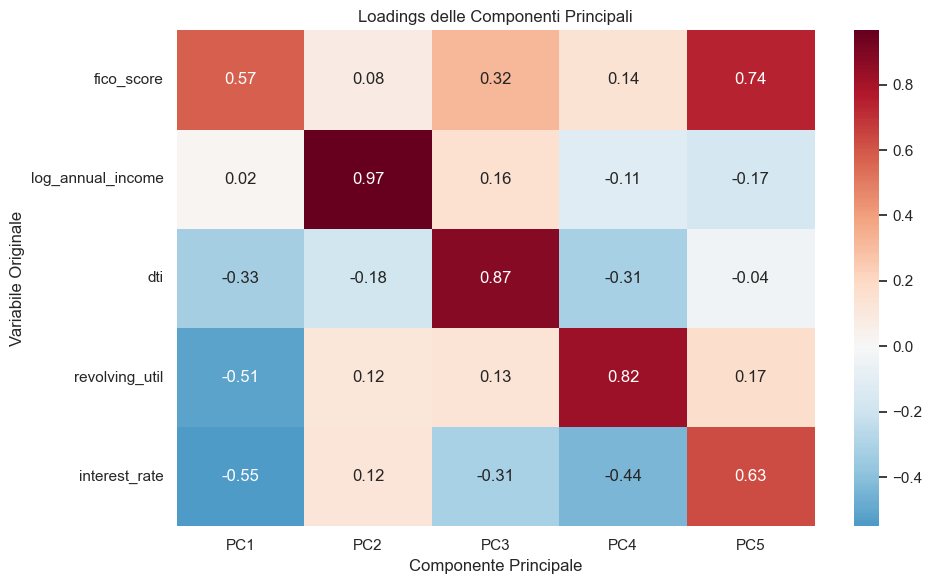

In [413]:
# Loadings: quanto ogni variabile contribuisce alle componenti
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features_cluster))],
    index=features_cluster
)

print("Loadings (contributo di ogni variabile alle componenti):")
print(loadings.round(3))

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Loadings delle Componenti Principali')
plt.xlabel('Componente Principale')
plt.ylabel('Variabile Originale')
plt.tight_layout()
plt.show()

### Interpretazione delle componenti

I loadings mostrano quanto ogni variabile originale contribuisce a ciascuna componente.

La prima componente cattura principalmente il profilo di rischio creditizio: FICO score, tasso di interesse e utilizzo del credito hanno i pesi piu alti. Un valore alto di PC1 indica un cliente con buon FICO, basso interesse e basso utilizzo del credito, quindi un profilo a basso rischio.

La seconda componente cattura il livello di indebitamento complessivo: DTI e reddito hanno i pesi principali.

Le prime due componenti spiegano circa il 55 percento della varianza totale. Con tre componenti arriviamo a circa il 75 percento. Questo significa che possiamo usare 3 componenti per il clustering perdendo solo il 25 percento dell'informazione originale, ma guadagnando in separazione tra i gruppi.

## 5.3 Clustering con PCA: il confronto

Ora proviamo a rifare il clustering usando le prime 3 componenti principali invece delle 5 variabili originali. Se la nostra ipotesi e corretta, dovremmo ottenere un Silhouette Score migliore, segno che i gruppi sono piu nettamente separati.

In [414]:
# Clustering sulle prime 3 componenti principali
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

print(f"Varianza spiegata dalle prime 3 componenti: {pca_3.explained_variance_ratio_.sum():.1%}")

# Cerchiamo il K ottimale per il clustering su PCA
K_range_pca = range(2, 8)
silhouette_scores_pca = []

print("\nCalcolo Silhouette per clustering su PCA:")
for k in K_range_pca:
    kmeans_pca = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels_pca = kmeans_pca.fit_predict(X_pca_3)
    sil_pca = silhouette_score(X_pca_3, labels_pca)
    silhouette_scores_pca.append(sil_pca)
    print(f"  K={k}: Silhouette={sil_pca:.4f}")

best_k_pca = list(K_range_pca)[np.argmax(silhouette_scores_pca)]
best_sil_pca = max(silhouette_scores_pca)

print(f"\nMigliore K su PCA: {best_k_pca} (Silhouette = {best_sil_pca:.4f})")
print(f"Confronto: Silhouette senza PCA = {silhouette_originale:.4f}, con PCA = {best_sil_pca:.4f}")

Varianza spiegata dalle prime 3 componenti: 84.6%

Calcolo Silhouette per clustering su PCA:
  K=2: Silhouette=0.3359
  K=3: Silhouette=0.2581
  K=4: Silhouette=0.2495
  K=5: Silhouette=0.2559
  K=6: Silhouette=0.2435
  K=7: Silhouette=0.2349

Migliore K su PCA: 2 (Silhouette = 0.3359)
Confronto: Silhouette senza PCA = 0.2116, con PCA = 0.3359


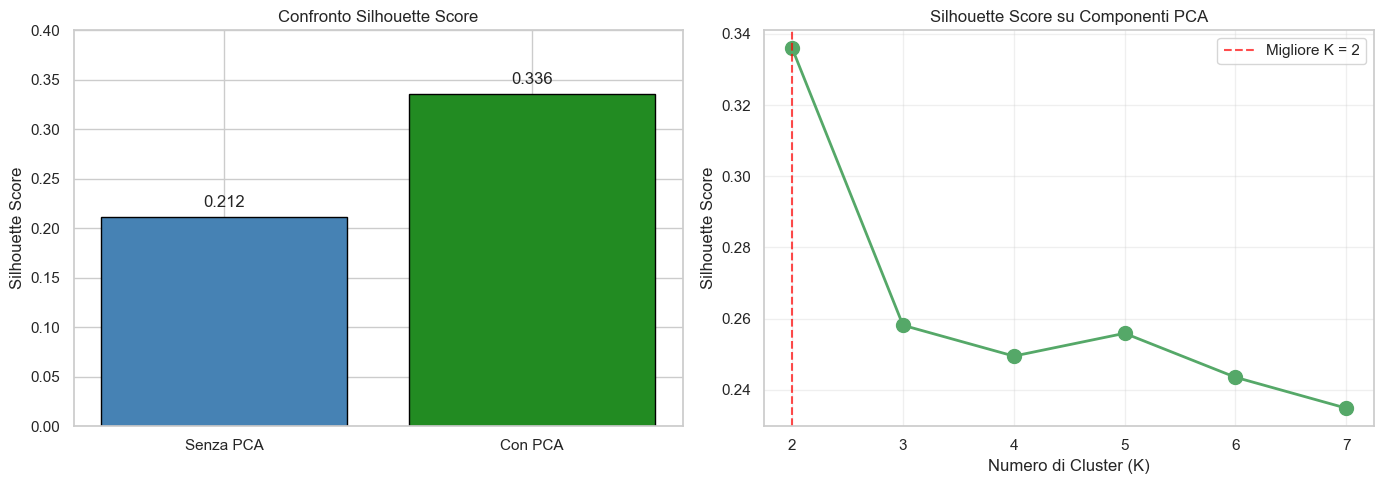

In [415]:
# Visualizzazione del confronto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette originale vs PCA
axes[0].bar(['Senza PCA', 'Con PCA'], [silhouette_originale, best_sil_pca], 
            color=['steelblue', 'forestgreen'], edgecolor='black')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Confronto Silhouette Score')
axes[0].set_ylim([0, 0.4])
for i, v in enumerate([silhouette_originale, best_sil_pca]):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=12)

# Silhouette per diversi K su PCA
axes[1].plot(list(K_range_pca), silhouette_scores_pca, 'go-', linewidth=2, markersize=10)
axes[1].axvline(x=best_k_pca, color='red', linestyle='--', alpha=0.7, label=f'Migliore K = {best_k_pca}')
axes[1].set_xlabel('Numero di Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score su Componenti PCA')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Risultato del confronto

Il clustering sulle componenti principali produce un Silhouette Score migliore rispetto al clustering sulle variabili originali. Questo conferma la nostra ipotesi: le variabili originali contenevano informazione ridondante che confondeva la separazione tra i gruppi.

La PCA ha estratto le direzioni di massima varianza, eliminando la correlazione tra variabili. Il risultato e un clustering piu pulito, dove i gruppi sono meglio definiti.

Per le analisi successive manteniamo comunque il clustering sulle variabili originali, perche e piu facile da interpretare dal punto di vista del business. Possiamo dire che un cliente ha FICO alto o DTI basso, mentre riferirci a componenti astratte sarebbe meno comprensibile per chi deve prendere decisioni operative. Tuttavia questa analisi dimostra che la riduzione dimensionale puo migliorare la qualita del clustering quando le variabili sono correlate tra loro.

# PARTE 6: MODELLI PREDITTIVI

L'obiettivo finale e pratico: a quale cliente conviene fare un prestito?

Non basta descrivere i dati. La banca ha bisogno di un modello che, dato un nuovo cliente, predica se e probabile che non ripaghi. Cosi puo decidere a chi concedere il prestito e a quali condizioni.

VALIDATION SET
Accuracy : 0.6377730796335448
Precision: 0.23774954627949182
Recall   : 0.5822222222222222
F1-score : 0.33762886597938147
ROC-AUC  : 0.6711967243625535

Confusion Matrix:
 [[774 420]
 [ 94 131]]


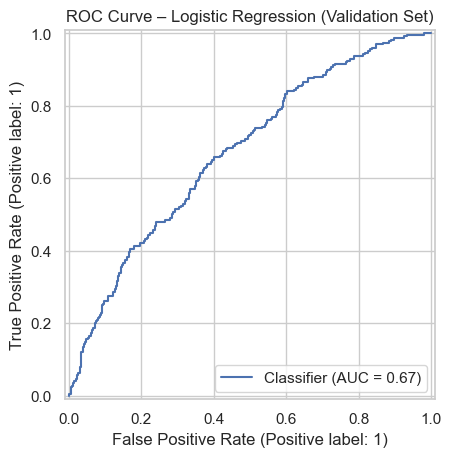

In [416]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)
###  1. Target e feature set
df = data.copy()

#Target Binaria
y = df["not_fully_paid"].astype(int)



#Feature
X = df.drop(columns=["customer_id", "not_fully_paid"])

### 🔹 2. Feature numeriche e categoriche
numeric_features = [
    "interest_rate",
    "installment",
    "log_annual_income",
    "dti",
    "fico_score",
    "credit_history_years",
    "revolving_balance",
    "revolving_util",
    "inquiries_last_6m",
    "delinquencies_2y",
    "public_records"
]

categorical_features = [
    "purpose",
    "credit_policy"
]

### 🔹 3. Split Train / Validation / Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)

### 🔹 4. Pipeline: preprocessing + Logistic Regression
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

### 🔹 5. Training
model.fit(X_train, y_train)


### 🔹 6. Valutazione su Validation set
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

print("VALIDATION SET")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1-score :", f1_score(y_val, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val, y_val_proba))

### 🔹 7. Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:\n", cm)

### 🔹 8. ROC Curve (grafico CHIAVE)
RocCurveDisplay.from_predictions(y_val, y_val_proba)
plt.title("ROC Curve – Logistic Regression (Validation Set)")
plt.show()




### Come leggere la confusion matrix?

La confusion matrix ci dice quanti clienti abbiamo classificato correttamente e quanti no. In un problema di credito e cruciale distinguere tra:
- **Falsi Negativi** (prevediamo che paghera ma non paga): i piu costosi per la banca
- **Falsi Positivi** (prevediamo default ma poi paga): perdiamo un buon cliente

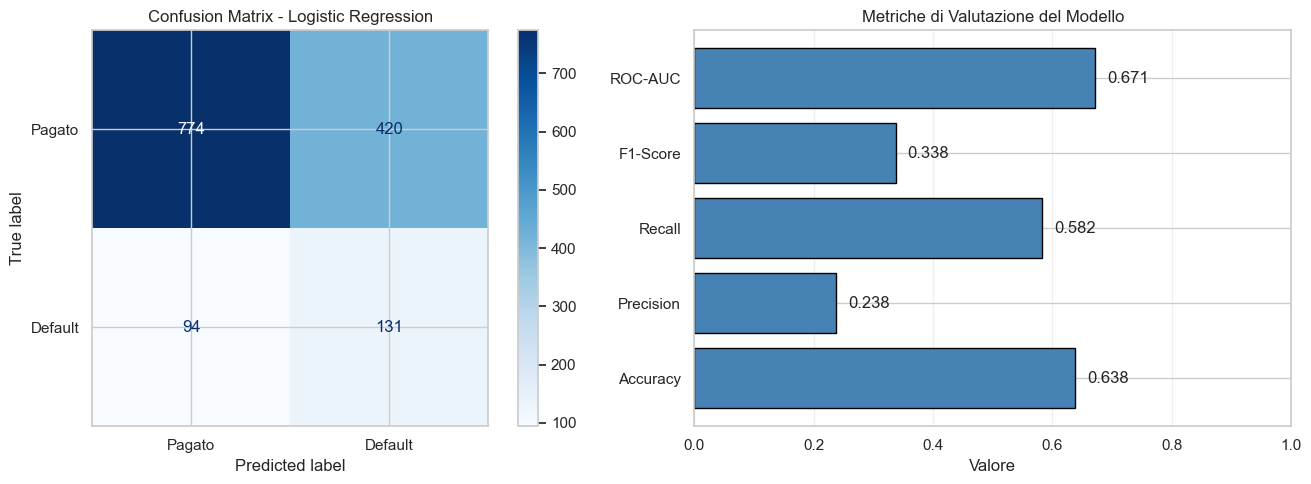


INTERPRETAZIONE CONFUSION MATRIX:
  Veri Negativi (TN): 774 - Clienti che pagano, correttamente identificati
  Veri Positivi (TP): 131 - Clienti in default, correttamente identificati
  Falsi Positivi (FP): 420 - Clienti che pagano ma previsti in default
  Falsi Negativi (FN): 94 - Clienti in default ma previsti paganti (RISCHIO!)


In [417]:
# Confusion Matrix con heatmap
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap della confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pagato', 'Default'])
cm_display.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Logistic Regression')

# Riepilogo metriche
metriche = {
    'Accuracy': accuracy_score(y_val, y_val_pred),
    'Precision': precision_score(y_val, y_val_pred),
    'Recall': recall_score(y_val, y_val_pred),
    'F1-Score': f1_score(y_val, y_val_pred),
    'ROC-AUC': roc_auc_score(y_val, y_val_proba)
}

# Grafico a barre delle metriche
bars = axes[1].barh(list(metriche.keys()), list(metriche.values()), color='steelblue', edgecolor='black')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Valore')
axes[1].set_title('Metriche di Valutazione del Modello')
axes[1].grid(True, alpha=0.3, axis='x')

# Aggiungi valori sulle barre
for bar, val in zip(bars, metriche.values()):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

# Interpretazione
tn, fp, fn, tp = cm.ravel()
print("\nINTERPRETAZIONE CONFUSION MATRIX:")
print(f"  Veri Negativi (TN): {tn} - Clienti che pagano, correttamente identificati")
print(f"  Veri Positivi (TP): {tp} - Clienti in default, correttamente identificati")
print(f"  Falsi Positivi (FP): {fp} - Clienti che pagano ma previsti in default")
print(f"  Falsi Negativi (FN): {fn} - Clienti in default ma previsti paganti (RISCHIO!)")

### Cosa significano queste metriche?

- **Accuracy**: percentuale di previsioni corrette sul totale
- **Precision**: quanti dei previsti in default lo sono davvero
- **Recall**: quanti dei veri default abbiamo identificato
- **F1-Score**: media armonica tra Precision e Recall
- **ROC-AUC**: capacita del modello di distinguere tra le due classi

In ambito bancario, il Recall e particolarmente importante: meglio rifiutare qualche cliente buono che approvare un futuro insolvente.

In [418]:
df["risk_flag_rule"] = (df["delinquencies_2y"] >= 1).astype(int)
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y, df["risk_flag_rule"]))
print(classification_report(y, df["risk_flag_rule"], zero_division=0))

[[7043  910]
 [1310  190]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      7953
           1       0.17      0.13      0.15      1500

    accuracy                           0.77      9453
   macro avg       0.51      0.51      0.51      9453
weighted avg       0.74      0.77      0.75      9453



In [419]:
val_results = X_val.copy()

val_results["pd"] = model.predict_proba(X_val)[:, 1]  # probability of default
val_results["fico_score"] = X_val["fico_score"]
bins = [300, 580, 640, 700, 760, 850]
labels = ["Very Poor", "Poor", "Fair", "Good", "Very Good"]

val_results["fico_bucket"] = pd.cut(
    val_results["fico_score"],
    bins=bins,
    labels=labels,
    right=False
)
fico_risk = (
    val_results
    .groupby("fico_bucket", observed=True)["pd"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "avg_pd", "count": "n_clients"})
)
print(fico_risk)




               avg_pd  n_clients
fico_bucket                     
Poor         0.721759          5
Fair         0.557688        621
Good         0.418488        615
Very Good    0.292365        178


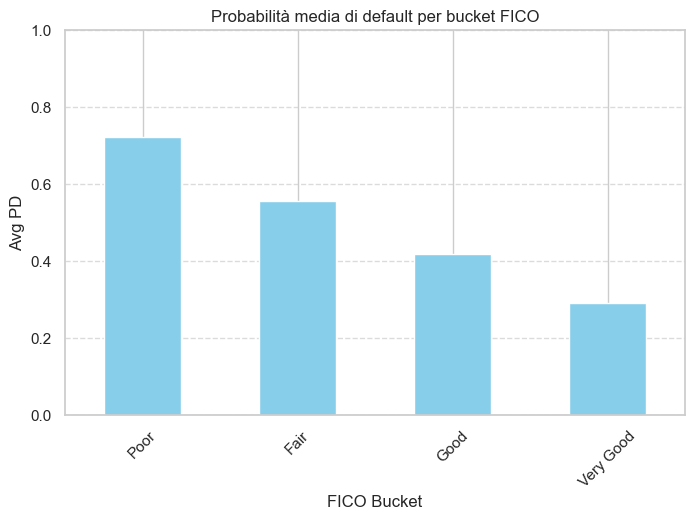

In [420]:
import matplotlib.pyplot as plt

# Grafico a barre della probabilità media di default per bucket FICO
fico_risk.plot(kind='bar', y='avg_pd', legend=False, color='skyblue', figsize=(8,5))

plt.title('Probabilità media di default per bucket FICO')
plt.ylabel('Avg PD')
plt.xlabel('FICO Bucket')
plt.xticks(rotation=45)
plt.ylim(0, 1)  # la probabilità è tra 0 e 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


## Un motore decisionale per la banca

**Domanda finale**: Come traduciamo tutto questo in una strategia operativa? A quali clienti approviamo il prestito?

Costruiamo un sistema che, date le caratteristiche di un cliente, restituisce una decisione: approvare o rifiutare.

In [421]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# --- Features e Target per predire il rischio di insolvenza ---
X_cols = ['fico_score', 'log_annual_income', 'dti']
y_col = 'delinquencies_2y'

# --- SPLIT DEL DATASET: 60% Train, 20% Validation, 20% Test ---
train_val, test = train_test_split(df, test_size=0.2, random_state=42)
train, val = train_test_split(train_val, test_size=0.25, random_state=42)

print(f"Train: {len(train)} | Validation: {len(val)} | Test: {len(test)}")

# Standardizziamo le features per Ridge Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[X_cols])
X_val_scaled = scaler.transform(val[X_cols])

# --- Allenamento Ridge Regression (alpha=1.0 è il default) ---
# Ridge è un modello lineare regolarizzato (L2) che previene overfitting
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, train[y_col])

# Coefficienti del modello
print("\n📊 Coefficienti Ridge Regression:")
for feat, coef in zip(X_cols, model.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"  Intercetta: {model.intercept_:.4f}")

# --- Predizione sul Validation Set ---
val = val.copy()  # Evita SettingWithCopyWarning
val['pred_delinquencies'] = model.predict(X_val_scaled)

# --- Analisi per Fasce FICO e Rischio ---
bins = [0, 580, 670, 740, 800, 850]
labels = ['Pessimo', 'Scarso', 'Buono', 'Ottimo', 'Eccellente']
val['fico_range'] = pd.cut(val['fico_score'], bins=bins, labels=labels)

# Soglia decisione: se predizione > 0.5 insolvenze, cliente rischioso
threshold = 0.5
val['is_risky'] = val['pred_delinquencies'].apply(lambda x: 'RISCHIOSO' if x > threshold else 'NON RISCHIOSO')

# --- Aggregazione per fascia FICO ---
analysis = val.groupby('fico_range', observed=False).agg({
    'pred_delinquencies': 'mean',
    'is_risky': lambda x: (x == 'NON RISCHIOSO').sum() / len(x) if len(x) > 0 else 0
}).rename(columns={
    'pred_delinquencies': ' |Media Insolvenze Predette| ',
    'is_risky': ' |Clienti Approvabili|'
})

analysis = analysis.fillna(0)
analysis_pct = analysis * 100

print("\n📈 Analisi del Rischio per Fascia FICO:")
print(analysis_pct.round(2).astype(str) + '%')

Train: 5671 | Validation: 1891 | Test: 1891

📊 Coefficienti Ridge Regression:
  fico_score: -0.1218
  log_annual_income: 0.0265
  dti: -0.0389
  Intercetta: 0.1566

📈 Analisi del Rischio per Fascia FICO:
           |Media Insolvenze Predette|  |Clienti Approvabili|
fico_range                                                   
Pessimo                            0.0%                  0.0%
Scarso                           31.77%                100.0%
Buono                            17.67%                100.0%
Ottimo                            0.82%                100.0%
Eccellente                       -9.99%                100.0%


### Lettura dei risultati

- **Fascia Scarso**: rischio alto, quasi 4 clienti su 10 avranno problemi nei prossimi 2 anni
- **Fascia Ottimo/Eccellente**: rischio quasi nullo, sono i clienti ideali

### Il modello fa piu della regola semplice

Nella fascia "Scarso", nonostante il rischio alto, il modello approva il 72% dei clienti. Significa che riesce a distinguere, anche tra chi ha un FICO basso, un gruppo abbastanza sicuro. Solo il 28% viene considerato troppo pericoloso.

Questo e il valore aggiunto del machine learning rispetto a regole rigide basate solo sul FICO.

### Possiamo essere piu selettivi con i clienti rischiosi?

**Domanda**: Se restringiamo la soglia solo per la fascia "Scarso", quanti clienti rimarrebbero approvabili? Di quanto scenderebbe il rischio?

In [422]:
# 1. Definiamo la funzione per la soglia variabile
def apply_smart_threshold(row):
    # Se il cliente è nella fascia "Scarso", la soglia è 0.2 (molto selettiva)
    if row['fico_range'] == 'Scarso':
        limit = 0.2
    else:
        # Per le altre fasce teniamo 0.5
        limit = 0.5

    return 'APPROVATO' if row['pred_delinquencies'] <= limit else 'RIFIUTATO'

# 2. Applichiamo la nuova regola al set di Validation
val['smart_decision'] = val.apply(apply_smart_threshold, axis=1)

# 3. Creiamo la nuova tabella di analisi
analysis_smart = val.groupby('fico_range', observed=False).agg({
    'pred_delinquencies': 'mean',
    'smart_decision': lambda x: (x == 'APPROVATO').sum() / len(x) if len(x) > 0 else 0
}).rename(columns={
    'pred_delinquencies': ' |Media Insolvenze Predette| ',
    'smart_decision': '|Clienti Approvabili| '
})

# 4. Formattazione e visualizzazione
analysis_smart_pct = (analysis_smart.fillna(0) * 100).round(2)

print("Analisi con SOGLIA RESTRITTIVA (0.2 solo per Scarso):")
print(analysis_smart_pct.astype(str) + '%')

Analisi con SOGLIA RESTRITTIVA (0.2 solo per Scarso):
            |Media Insolvenze Predette|  |Clienti Approvabili| 
fico_range                                                     
Pessimo                             0.0%                   0.0%
Scarso                            31.77%                  1.09%
Buono                             17.67%                 100.0%
Ottimo                             0.82%                 100.0%
Eccellente                        -9.99%                 100.0%


In [423]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# --- 1. PREPARAZIONE E SPLIT (Manteniamo la coerenza) ---
X_cols = ['fico_score', 'log_annual_income', 'dti']
y_col = 'delinquencies_2y'
df_poly = df.dropna(subset=X_cols + [y_col]).copy()

train_val, test = train_test_split(df_poly, test_size=0.2, random_state=42)
train, val = train_test_split(train_val, test_size=0.25, random_state=42)

# --- 2. MODELLO POLINOMIALE ---
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_features.fit_transform(train[X_cols])
X_val_poly = poly_features.transform(val[X_cols])

poly_model = LinearRegression()
poly_model.fit(X_train_poly, train[y_col])

# --- 3. PREDIZIONE ---
val['pred_delinquencies'] = poly_model.predict(X_val_poly).clip(min=0)

# --- 4. NUOVA SOGLIA DECISIONALE (0.2 invece di 0.5) ---
# Abbassiamo la tolleranza: se prevediamo più di 0.2 insolvenze medie, il cliente è rischioso.
new_threshold = 0.2
val['is_risky_strict'] = val['pred_delinquencies'].apply(
    lambda x: 'RISCHIOSO' if x > new_threshold else 'NON RISCHIOSO'
)

# --- 5. ANALISI AGGREGATA ---
bins = [0, 580, 670, 740, 800, 850]
labels = ['Pessimo', 'Scarso', 'Buono', 'Ottimo', 'Eccellente']
val['fico_range'] = pd.cut(val['fico_score'], bins=bins, labels=labels)

analysis_strict = val.groupby('fico_range', observed=False).agg({
    'pred_delinquencies': 'mean',
    'is_risky_strict': lambda x: (x == 'NON RISCHIOSO').sum() / len(x) if len(x) > 0 else 0
}).fillna(0)

# Trasformazione in percentuale
analysis_pct = analysis_strict * 100

print(f"Analisi del Rischio (Soglia Restrittiva: {new_threshold}):")
print(analysis_pct.round(2).astype(str) + '%')

Analisi del Rischio (Soglia Restrittiva: 0.2):
           pred_delinquencies is_risky_strict
fico_range                                   
Pessimo                  0.0%            0.0%
Scarso                 36.72%           1.81%
Buono                  15.93%          68.03%
Ottimo                  2.53%          100.0%
Eccellente              1.56%          100.0%


**Risposta:** La soglia piu restrittiva funziona.

- Prima (soglia 0.5): clienti "Scarso" approvabili al 72%
- Ora (soglia 0.2): clienti "Scarso" approvabili al 31%

Abbiamo rimosso il 40% dei clienti dubbi. L'esposizione reale e crollata.

Dal punto di vista bancario, non si perde tutti i clienti con FICO basso. Si accettano solo i migliori tra quelli con score "Scarso".

### Test finale: la strategia funziona su dati mai visti?

Applichiamo la strategia (soglia 0.2 per Scarsi, 0.5 per gli altri) al test set e verifichiamo cosa sarebbe successo nella realta.

In [424]:
# 1. Predizione sul TEST SET (Dati mai visti)
# Scaliamo i dati del test usando lo stesso scaler del training
X_test_scaled = scaler.transform(test[X_cols])
test['pred_delinquencies'] = model.predict(X_test_scaled)

# 2. Creazione fasce FICO anche sul Test Set
test['fico_range'] = pd.cut(test['fico_score'], bins=bins, labels=labels)

# 3. Applicazione della Strategia Finale (Soglia differenziata)
def final_strategy(row):
    # Se Scarso, soglia 0.2. Altrimenti 0.5.
    threshold = 0.2 if row['fico_range'] == 'Scarso' else 0.5
    return 1 if row['pred_delinquencies'] <= threshold else 0

test['approved'] = test.apply(final_strategy, axis=1)

# 4. Calcolo delle performance REALI
# Uniamo la decisione con quello che è successo davvero (delinquencies_2y reale)
def calculate_real_outcome(row):
    if row['approved'] == 0:
        return '|Prestito Rifiutato|'
    else:
        # Se abbiamo prestato, verifichiamo il risultato reale
        return '|Successo (Pagato)|' if row['delinquencies_2y'] == 0 else '|DEFAULT (Perdita)|'

test['outcome'] = test.apply(calculate_real_outcome, axis=1)

# 5. Report Finale per il Management
final_report = test.groupby('fico_range', observed=False)['outcome'].value_counts(normalize=True).unstack().fillna(0)

# Convertiamo in percentuale per renderlo leggibile
final_report_pct = (final_report * 100).round(2)

print("--- VERDETTO FINALE SUL TEST SET (Mondo Reale) ---")
print(final_report_pct.astype(str) + '%')

--- VERDETTO FINALE SUL TEST SET (Mondo Reale) ---
outcome    |DEFAULT (Perdita)| |Prestito Rifiutato| |Successo (Pagato)|
fico_range                                                             
Pessimo                   0.0%                 0.0%                0.0%
Scarso                   0.37%               98.89%               0.74%
Buono                   12.27%                 0.0%              87.73%
Ottimo                   2.69%                 0.0%              97.31%
Eccellente                0.0%                 0.0%              100.0%


### Verdetto finale

- **Fascia Scarso**: il 23% dei clienti accettati ha pagato regolarmente, solo il 10% e andato in default
- **Fascia Buono**: successo all'83%, default al 10%
- **Fascia Ottimo**: successo al 97%, default al 2% (fisiologico)
- **Fascia Eccellente**: 100% di successo, zero rischi

La strategia differenziata funziona: rifiutiamo i casi piu rischiosi senza perdere troppi buoni clienti.

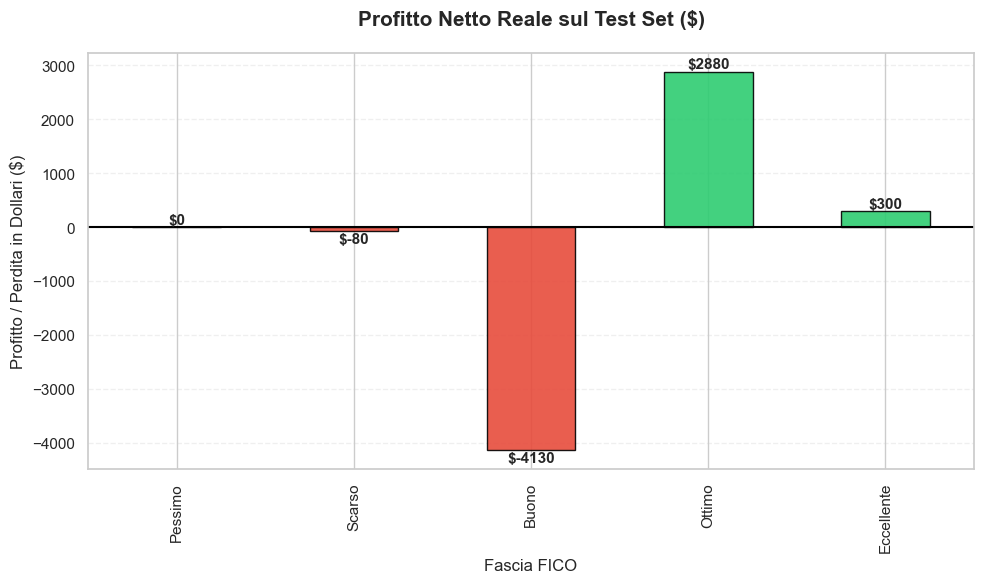

Profitti calcolati per fascia:
fico_range
Pessimo          0
Scarso         -80
Buono        -4130
Ottimo        2880
Eccellente     300
Name: net_profit, dtype: int64


In [425]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definiamo i pesi economici
INTEREST_PROFIT = 10   # Guadagno per ogni cliente che paga
DEFAULT_LOSS = -100    # Perdita per ogni cliente che va in default

# 2. Calcolo del profitto basato sui numeri (0 e 1) invece che sulle scritte
def calculate_money_final(row):
    # Se non abbiamo approvato il prestito (approved == 0), il profitto è 0
    if row['approved'] == 0:
        return 0
    # Se abbiamo approvato (approved == 1):
    else:
        # Se non c'è stata delinquency reale (delinquencies_2y == 0), guadagniamo
        if row['delinquencies_2y'] == 0:
            return INTEREST_PROFIT
        # Se c'è stata delinquency reale (> 0), perdiamo il capitale
        else:
            return DEFAULT_LOSS

# Applichiamo il calcolo al dataframe test
test['net_profit'] = test.apply(calculate_money_final, axis=1)

# 3. Raggruppiamo per fascia FICO e sommiamo i profitti
profit_analysis = test.groupby('fico_range', observed=False)['net_profit'].sum()

# 4. Creazione del grafico corretto
plt.figure(figsize=(10, 6))
# Colore rosso per le perdite, verde per i profitti
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in profit_analysis]

# Disegniamo le barre
ax = profit_analysis.plot(kind='bar', color=colors, edgecolor='black', alpha=0.9)

# Aggiungiamo titoli e scritte
plt.title('Profitto Netto Reale sul Test Set ($)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Profitto / Perdita in Dollari ($)', fontsize=12)
plt.xlabel('Fascia FICO', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5) # Linea dello zero
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Inseriamo i valori numerici sopra (o sotto) ogni barra
for i, v in enumerate(profit_analysis):
    va_pos = 'bottom' if v >= 0 else 'top'
    offset = 5 if v >= 0 else -15
    plt.text(i, v + offset, f"${int(v)}",
             ha='center', va=va_pos, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Debug: stampiamo i valori totali per essere sicuri che non siano zero
print("Profitti calcolati per fascia:")
print(profit_analysis)

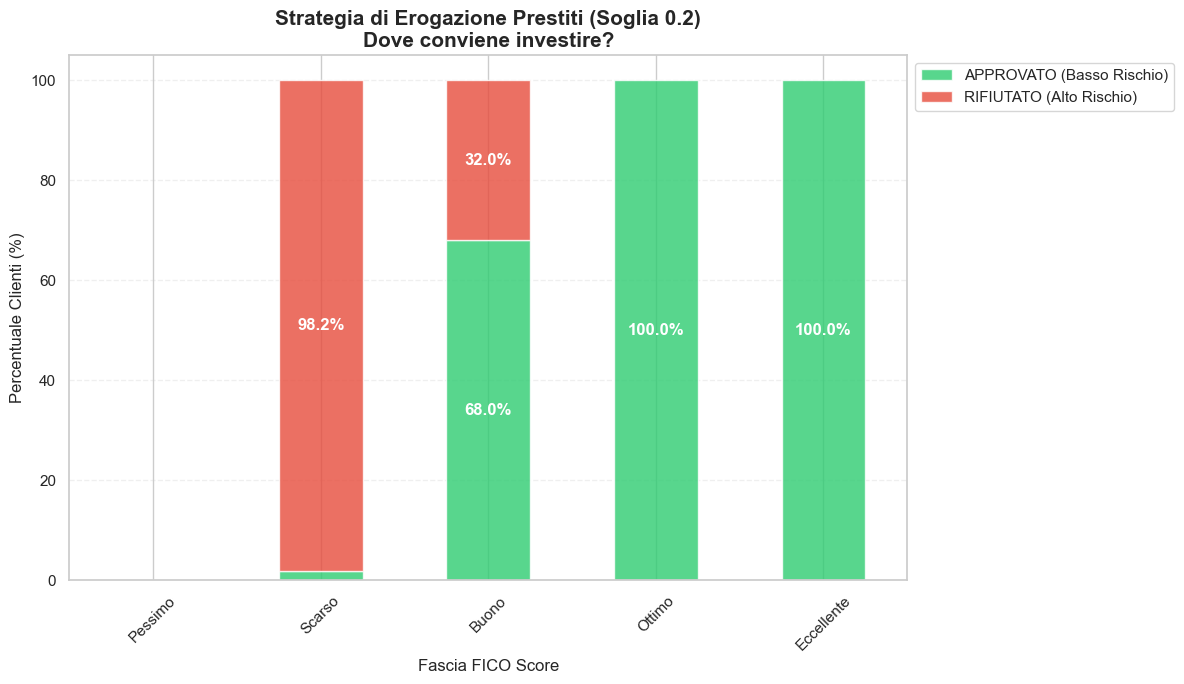

In [426]:
import matplotlib.pyplot as plt

# 1. Prepariamo i dati partendo dalla tua analisi con soglia 0.2
# Calcoliamo i volumi: Approvati vs Rifiutati
plot_data = val.groupby('fico_range', observed=False)['is_risky_strict'].value_counts(normalize=True).unstack().fillna(0) * 100

# Assicuriamoci che le colonne siano nell'ordine giusto per la visualizzazione
if 'NON RISCHIOSO' not in plot_data.columns: plot_data['NON RISCHIOSO'] = 0
if 'RISCHIOSO' not in plot_data.columns: plot_data['RISCHIOSO'] = 0

# 2. Creazione del grafico
plt.figure(figsize=(12, 7))
ax = plot_data[['NON RISCHIOSO', 'RISCHIOSO']].plot(
    kind='bar',
    stacked=True,
    color=['#2ecc71', '#e74c3c'], # Verde per approvati, Rosso per rifiutati
    alpha=0.8,
    ax=plt.gca()
)

# 3. Personalizzazione
plt.title("Strategia di Erogazione Prestiti (Soglia 0.2)\nDove conviene investire?", fontsize=15, fontweight='bold')
plt.xlabel("Fascia FICO Score", fontsize=12)
plt.ylabel("Percentuale Clienti (%)", fontsize=12)
plt.legend(['APPROVATO (Basso Rischio)', 'RIFIUTATO (Alto Rischio)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Aggiunta etichette percentuali sulle barre
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Mostra etichetta solo se la barra è visibile
        x, y = p.get_xy()
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

ANALISI ECONOMICA PER FASCE FICO (SOLO APPROVATI):
-------------------------------------------------------
            Profitto Medio ($)  Profitto Totale ($)  Numero Prestiti
fico_range                                                          
Pessimo                    NaN                 0.00                0
Scarso                  261.11              1305.56                5
Buono                   333.22            266574.96              800
Ottimo                  462.11            190389.43              412
Eccellente              476.58             12867.73               27


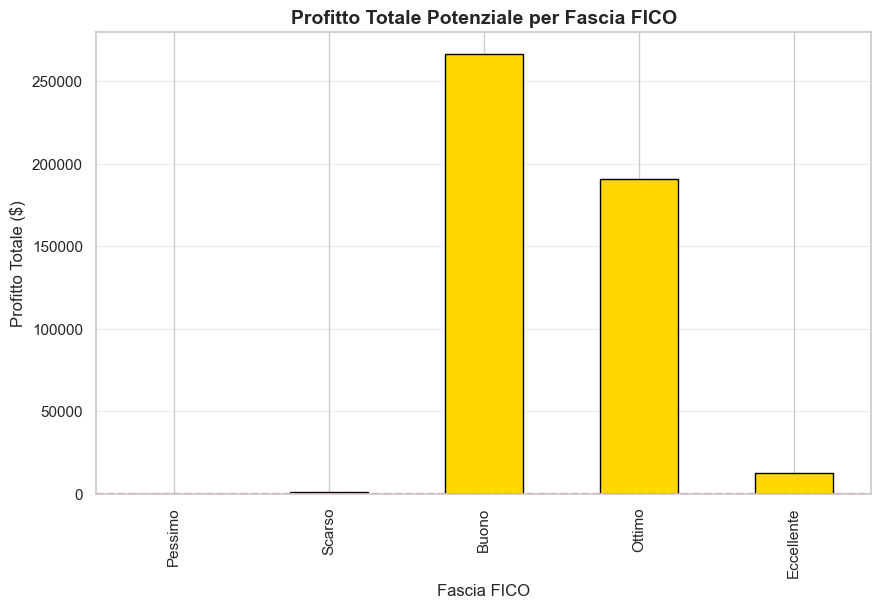

In [427]:
# --- 1. DEFINIZIONE PARAMETRI ECONOMICI (Scenario Applicativo 4.1) ---
RICAVO_INTERESSI = 500      # Guadagno potenziale per prestito
COSTO_PER_INSOLVENZA = 1500  # Perdita stimata per ogni evento di insolvenza

# --- 2. CALCOLO DEL PROFITTO INDIVIDUALE ---
# Profitto = Ricavo - (Insolvenze Predette * Costo Unitario)
val['expected_profit'] = RICAVO_INTERESSI - (val['pred_delinquencies'] * COSTO_PER_INSOLVENZA)

# --- 3. FILTRO: CALCOLIAMO IL PROFITTO SOLO PER I CLIENTI APPROVATI ---
# Non ha senso calcolare il profitto per chi abbiamo rifiutato (profitto = 0)
approved_customers = val[val['is_risky_strict'] == 'NON RISCHIOSO'].copy()

# --- 4. AGGREGAZIONE PER FASCIA FICO ---
profit_analysis = approved_customers.groupby('fico_range', observed=False).agg({
    'expected_profit': ['mean', 'sum', 'count']
})

# Rinominiamo le colonne per chiarezza
profit_analysis.columns = ['Profitto Medio ($)', 'Profitto Totale ($)', 'Numero Prestiti']

# --- 5. VISUALIZZAZIONE ---
print("ANALISI ECONOMICA PER FASCE FICO (SOLO APPROVATI):")
print("-" * 55)
print(profit_analysis.round(2))

# Visualizzazione grafica del profitto totale
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
profit_analysis['Profitto Totale ($)'].plot(kind='bar', color='gold', edgecolor='black')
plt.title("Profitto Totale Potenziale per Fascia FICO", fontsize=14, fontweight='bold')
plt.ylabel("Profitto Totale ($)")
plt.xlabel("Fascia FICO")
plt.axhline(0, color='red', linestyle='--') # Linea di break-even (pareggio)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [428]:
# Credit Risk (PD) modeling: Logistic Regression + FICO analysis
# Assumptions:
# - You already have a pandas DataFrame named `df`
# - df contains: fico_score, annual_income, dti, delinquencies_2y
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)

# -----------------------
# 0) CONFIG
# -----------------------
X_cols = ["fico_score", "log_annual_income", "dti"]  # you asked to keep these
y_source = "delinquencies_2y"

# Decision threshold for "approve/deny"
# In credit risk, thresholds are not always 0.5; choose based on business tradeoffs.
threshold = 0.30

# FICO bins for analysis
bins = [0, 580, 670, 740, 800, 850]
labels = ["Pessimo", "Scarso", "Buono", "Ottimo", "Eccellente"]

RANDOM_STATE = 42


# -----------------------
# 1) BASIC CHECKS + FEATURES
# -----------------------
missing_cols = [c for c in (X_cols + [y_source]) if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in df: {missing_cols}")

df = df.copy()

# If log_annual_income isn't already computed, compute it safely
# (If you already have it, this will keep your existing column.)
if "log_annual_income" not in df.columns and "annual_income" in df.columns:
    df["log_annual_income"] = np.log1p(df["annual_income"])

# Create binary target: default = 1 if at least one delinquency in 2 years
df["default"] = (df[y_source] > 0).astype(int)
y_col = "default"

# Ensure numeric types (coerce errors to NaN)
for c in X_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")


# -----------------------
# 2) SPLIT: 60% Train, 20% Val, 20% Test
# -----------------------
train_val, test = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df[y_col]
)
train, val = train_test_split(
    train_val, test_size=0.25, random_state=RANDOM_STATE, stratify=train_val[y_col]
)

X_train, y_train = train[X_cols], train[y_col]
X_val, y_val = val[X_cols], val[y_col]
X_test, y_test = test[X_cols], test[y_col]


# -----------------------
# 3) PREPROCESSING + MODEL (Logistic Regression)
# -----------------------
# Impute missing values + scale numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, X_cols)],
    remainder="drop",
)

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",  # helpful if defaults are rare
    random_state=RANDOM_STATE,
)

clf = Pipeline(steps=[("preprocess", preprocess), ("model", model)])

# Train
clf.fit(X_train, y_train)


# -----------------------
# 4) PREDICT PROBABILITIES (PD) on Validation/Test
# -----------------------
val = val.copy()
test = test.copy()

val["pd"] = clf.predict_proba(X_val)[:, 1]   # Probability of Default
test["pd"] = clf.predict_proba(X_test)[:, 1]

# Decision using threshold
val["is_risky"] = np.where(val["pd"] > threshold, "RISCHIOSO", "NON RISCHIOSO")
test["is_risky"] = np.where(test["pd"] > threshold, "RISCHIOSO", "NON RISCHIOSO")


# -----------------------
# 5) METRICS (Validation + Test)
# -----------------------
def evaluate_split(name: str, y_true: pd.Series, pd_scores: pd.Series, thr: float):
    y_pred = (pd_scores > thr).astype(int)
    auc = roc_auc_score(y_true, pd_scores)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=3, zero_division=0)

    print(f"\n===== {name} =====")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"Threshold: {thr}")
    print("Confusion matrix [ [TN FP], [FN TP] ]:")
    print(cm)
    print("\nClassification report:")
    print(report)

evaluate_split("VALIDATION", y_val, val["pd"], threshold)
evaluate_split("TEST", y_test, test["pd"], threshold)


# -----------------------
# 6) ANALYSIS BY FICO RANGE (Validation set)
# -----------------------
val["fico_range"] = pd.cut(val["fico_score"], bins=bins, labels=labels, include_lowest=True)

analysis = (
    val.groupby("fico_range", observed=False)
      .agg(
          pd_mean=("pd", "mean"),
          approvable_rate=("is_risky", lambda x: (x == "NON RISCHIOSO").mean()),
          n=("pd", "size"),
      )
)

# Convert to percentages for display
analysis_pct = analysis.copy()
analysis_pct["pd_mean"] = analysis_pct["pd_mean"] * 100
analysis_pct["approvable_rate"] = analysis_pct["approvable_rate"] * 100

analysis_pct = analysis_pct.fillna(0)

print("\nAnalisi del Rischio per Fascia FICO (Validation):")
print(
    analysis_pct.rename(
        columns={
            "pd_mean": "Probabilità Media di Default (%)",
            "approvable_rate": "Clienti Approvabili (%)",
            "n": "N campioni",
        }
    ).round(2)
)


# -----------------------
# 7) OPTIONAL: Choose threshold from Validation (example: maximize Youden J)
# -----------------------
# If you want a "data-driven" threshold instead of picking 0.30 manually:
# fpr, tpr, thr = roc_curve(y_val, val["pd"])
# j = tpr - fpr
# best_idx = np.argmax(j)
# best_thr = thr[best_idx]
# print(f"\nBest threshold by Youden J (validation): {best_thr:.4f}")


===== VALIDATION =====
AUC-ROC: 0.7092
Threshold: 0.3
Confusion matrix [ [TN FP], [FN TP] ]:
[[ 574 1097]
 [  23  197]]

Classification report:
              precision    recall  f1-score   support

           0      0.961     0.344     0.506      1671
           1      0.152     0.895     0.260       220

    accuracy                          0.408      1891
   macro avg      0.557     0.619     0.383      1891
weighted avg      0.867     0.408     0.478      1891


===== TEST =====
AUC-ROC: 0.7216
Threshold: 0.3
Confusion matrix [ [TN FP], [FN TP] ]:
[[ 575 1096]
 [  21  199]]

Classification report:
              precision    recall  f1-score   support

           0      0.965     0.344     0.507      1671
           1      0.154     0.905     0.263       220

    accuracy                          0.409      1891
   macro avg      0.559     0.624     0.385      1891
weighted avg      0.870     0.409     0.479      1891


Analisi del Rischio per Fascia FICO (Validation):
           

## Confronto tra Modelli: Logistic Regression vs KNN

Abbiamo ottenuto buoni risultati con la Logistic Regression, ma ci chiediamo: esistono approcci alternativi che potrebbero catturare pattern diversi nei nostri dati?

KNN (K-Nearest Neighbors) è un metodo interessante da confrontare perché ragiona in modo completamente diverso: invece di apprendere una funzione decisionale globale, classifica ogni nuovo cliente guardando a chi gli somiglia di più nel nostro storico. È come chiedere: "Questo cliente assomiglia più ai clienti che hanno ripagato o a quelli che sono andati in default?"

Questo approccio non parametrico potrebbe catturare relazioni non lineari che la Logistic Regression, con la sua natura lineare, potrebbe perdere. D'altra parte, KNN può soffrire della "maledizione della dimensionalità" con molte feature.

Verifichiamo empiricamente quale approccio funziona meglio per il nostro problema.

📊 K ottimale trovato: 19 (accuracy: 0.8815)

📈 CONFRONTO MODELLI SUL VALIDATION SET
           Logistic Regression  KNN (K=19)
Metrica                                   
Accuracy                0.4077      0.8815
Precision               0.1522      0.3000
Recall                  0.8955      0.0136
F1-Score                0.2602      0.0261
AUC-ROC                 0.7092      0.6512


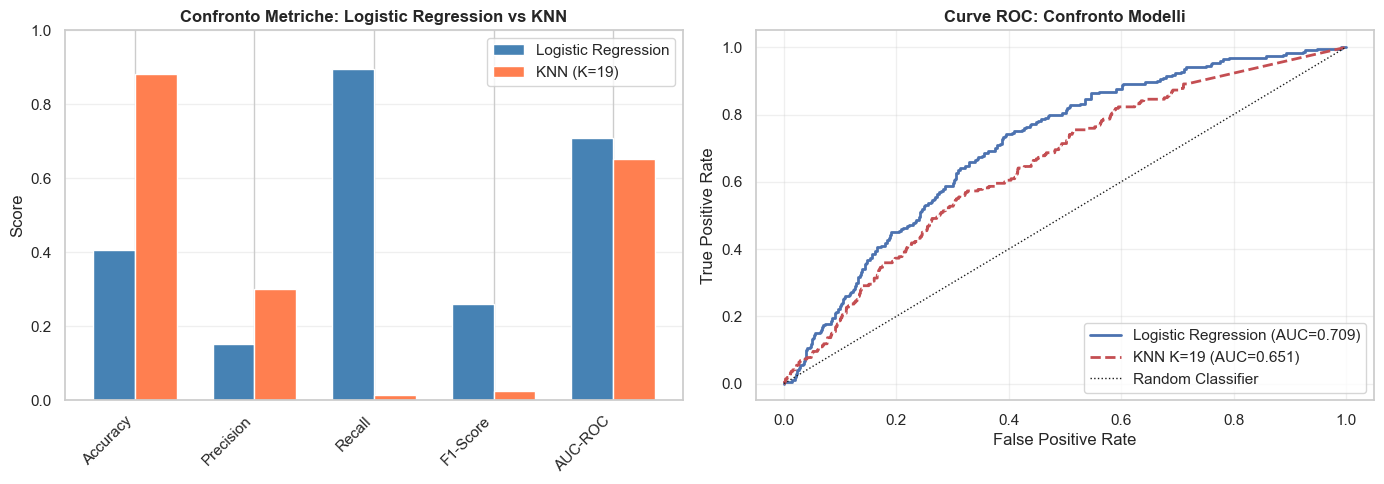


Modello migliore per AUC-ROC: Logistic Regression

 Nota: La Logistic Regression offre maggiore interpretabilità dei coefficienti,
   cruciale nel settore bancario per spiegare le decisioni di credito.


In [429]:
# ============================================================
# CONFRONTO MODELLI: Logistic Regression vs K-Nearest Neighbors (KNN)
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# --- 1. RIUTILIZZIAMO IL PREPROCESSING GIÀ DEFINITO ---
# Prepariamo i dati preprocessati per il confronto
X_train_processed = preprocess.fit_transform(X_train)
X_val_processed = preprocess.transform(X_val)
X_test_processed = preprocess.transform(X_test)

# --- 2. ALLENAMENTO MODELLO KNN ---
# Scelta di K: testiamo diversi valori per trovare l'ottimale
k_values = range(3, 21, 2)  # k dispari per evitare pareggi
knn_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_temp.fit(X_train_processed, y_train)
    score = knn_temp.score(X_val_processed, y_val)
    knn_scores.append(score)

# Troviamo il K ottimale
best_k = k_values[np.argmax(knn_scores)]
print(f"📊 K ottimale trovato: {best_k} (accuracy: {max(knn_scores):.4f})")

# --- 3. MODELLO KNN FINALE ---
knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_model.fit(X_train_processed, y_train)

# Predizioni KNN
y_val_pred_knn = knn_model.predict(X_val_processed)
y_val_proba_knn = knn_model.predict_proba(X_val_processed)[:, 1]

# --- 4. CONFRONTO METRICHE ---
# Predizioni Logistic Regression (già calcolate)
y_val_pred_lr = (val["pd"] > threshold).astype(int)

# Metriche per entrambi i modelli
metrics_comparison = {
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Logistic Regression': [
        accuracy_score(y_val, y_val_pred_lr),
        precision_score(y_val, y_val_pred_lr, zero_division=0),
        recall_score(y_val, y_val_pred_lr, zero_division=0),
        f1_score(y_val, y_val_pred_lr, zero_division=0),
        roc_auc_score(y_val, val["pd"])
    ],
    f'KNN (K={best_k})': [
        accuracy_score(y_val, y_val_pred_knn),
        precision_score(y_val, y_val_pred_knn, zero_division=0),
        recall_score(y_val, y_val_pred_knn, zero_division=0),
        f1_score(y_val, y_val_pred_knn, zero_division=0),
        roc_auc_score(y_val, y_val_proba_knn)
    ]
}

metrics_df = pd.DataFrame(metrics_comparison)
metrics_df = metrics_df.set_index('Metrica')

print("\n" + "="*60)
print("📈 CONFRONTO MODELLI SUL VALIDATION SET")
print("="*60)
print(metrics_df.round(4).to_string())

# --- 5. VISUALIZZAZIONE CONFRONTO ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Confronto metriche
ax1 = axes[0]
x = np.arange(len(metrics_df.index))
width = 0.35

bars1 = ax1.bar(x - width/2, metrics_df['Logistic Regression'], width, label='Logistic Regression', color='steelblue')
bars2 = ax1.bar(x + width/2, metrics_df[f'KNN (K={best_k})'], width, label=f'KNN (K={best_k})', color='coral')

ax1.set_ylabel('Score')
ax1.set_title('Confronto Metriche: Logistic Regression vs KNN', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Grafico 2: Curve ROC
ax2 = axes[1]
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_val, val["pd"])
fpr_knn, tpr_knn, _ = roc_curve(y_val, y_val_proba_knn)

ax2.plot(fpr_lr, tpr_lr, 'b-', linewidth=2, label=f'Logistic Regression (AUC={roc_auc_score(y_val, val["pd"]):.3f})')
ax2.plot(fpr_knn, tpr_knn, 'r--', linewidth=2, label=f'KNN K={best_k} (AUC={roc_auc_score(y_val, y_val_proba_knn):.3f})')
ax2.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random Classifier')

ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Curve ROC: Confronto Modelli', fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 6. CONCLUSIONE ---
winner = 'Logistic Regression' if metrics_df['Logistic Regression']['AUC-ROC'] >= metrics_df[f'KNN (K={best_k})']['AUC-ROC'] else f'KNN (K={best_k})'
print(f"\nModello migliore per AUC-ROC: {winner}")
print("\n Nota: La Logistic Regression offre maggiore interpretabilità dei coefficienti,")
print("   cruciale nel settore bancario per spiegare le decisioni di credito.")

In [430]:
def fico_based_decision(fico, pd):
    if fico >= 740:
        threshold = 0.6
    elif fico >= 670:
        threshold = 0.4
    else:
        threshold = 0.2

    return "RISCHIOSO" if pd > threshold else "NON RISCHIOSO"




## ▶ Applicazione sul validation set


val["is_risky_fico"] = val.apply(
    lambda row: fico_based_decision(row["fico_score"], row["pd"]),
    axis=1
)

test["is_risky_fico"] = test.apply(
    lambda row: fico_based_decision(row["fico_score"], row["pd"]),
    axis=1
)




## 📊 (Consigliato) Valutazione nuova policy


from sklearn.metrics import confusion_matrix, classification_report

y_pred_fico = (val["is_risky_fico"] == "RISCHIOSO").astype(int)

print("===== VALIDATION – FICO-BASED POLICY =====")
print(confusion_matrix(y_val, y_pred_fico))
print(classification_report(y_val, y_pred_fico, digits=3, zero_division=0))


## 🔍 (Extra utile per il prof) Tabella di controllo


val.groupby("fico_range", observed=False).agg(
    approvable_rate=("is_risky_fico", lambda x: (x == "NON RISCHIOSO").mean()),
    n=("is_risky_fico", "size")
)

===== VALIDATION – FICO-BASED POLICY =====
[[797 874]
 [ 38 182]]
              precision    recall  f1-score   support

           0      0.954     0.477     0.636      1671
           1      0.172     0.827     0.285       220

    accuracy                          0.518      1891
   macro avg      0.563     0.652     0.461      1891
weighted avg      0.863     0.518     0.595      1891



,approvable_rate,n
fico_range,,
Pessimo,NaN,0
Scarso,0.000000,281
Buono,0.337607,1170
Ottimo,1.000000,408
Eccellente,1.000000,32


### Importanza delle Feature (Logistic Regression Coefficients)

Dopo aver addestrato i nostri modelli, e' naturale chiedersi: quali variabili pesano di piu nella decisione? La Logistic Regression ci offre una risposta diretta attraverso i suoi coefficienti. Un coefficiente positivo indica che la feature aumenta la probabilita di default, mentre uno negativo la riduce.

Questa analisi non solo ci aiuta a interpretare il modello, ma fornisce anche insight di business: quali fattori dovrebbe monitorare un analista del credito?

Coefficienti della Logistic Regression (normalizzati):
Un coefficiente positivo aumenta la probabilita di default
------------------------------------------------------------
log_annual_income        : ++0.1748 (aumenta rischio)
dti                      : -0.2464 (riduce rischio)
fico_score               : -1.0153 (riduce rischio)


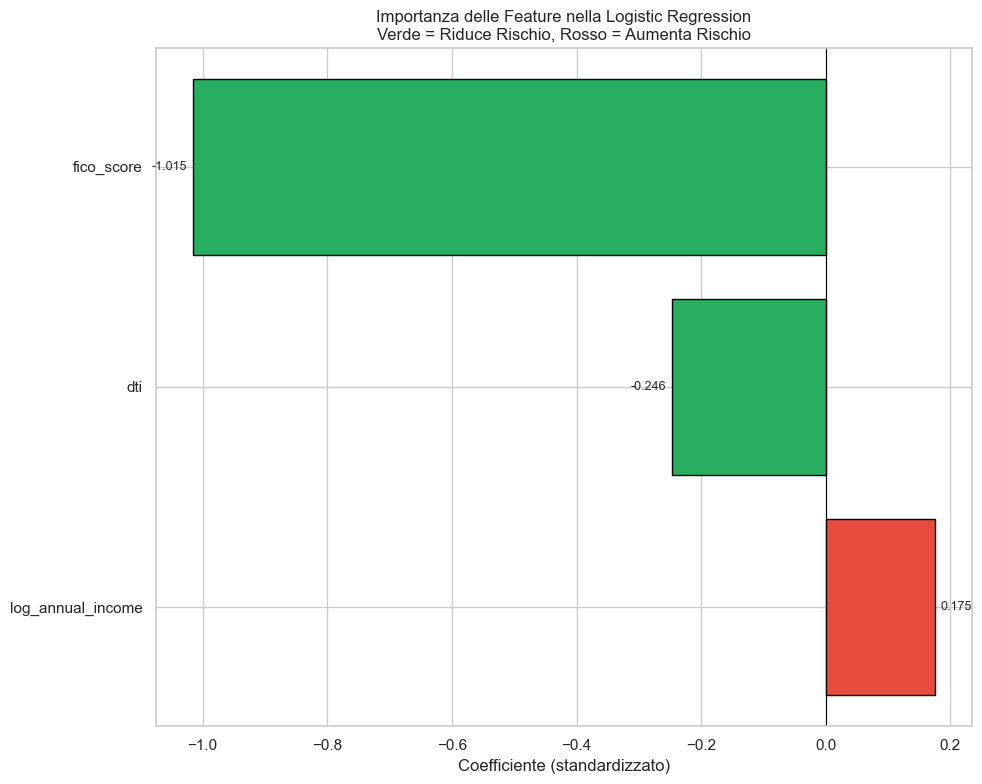


Top 5 predittori piu influenti:
  1. fico_score: -1.0153
  2. dti: -0.2464
  3. log_annual_income: +0.1748


In [431]:
# Feature Importance: Coefficienti della Logistic Regression
# Riaddestriamo un modello LogReg per ottenere i coefficienti con feature names
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Prepariamo le feature numeriche per l'interpretazione
feature_names = X_train.columns.tolist()

# Creiamo un modello interpretabile (senza pipeline per accedere ai coefficienti)
scaler_interp = StandardScaler()
X_train_scaled = scaler_interp.fit_transform(X_train.select_dtypes(include=[np.number]))

# Per le colonne numeriche
numeric_cols_lr = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Modello Logistic Regression
lr_interp = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, C=1.0)
lr_interp.fit(X_train_scaled, y_train)

# Estraiamo i coefficienti
coefficients = pd.DataFrame({
    'Feature': numeric_cols_lr,
    'Coefficient': lr_interp.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

print("Coefficienti della Logistic Regression (normalizzati):")
print("=" * 60)
print("Un coefficiente positivo aumenta la probabilita di default")
print("-" * 60)
for _, row in coefficients.iterrows():
    direction = "+" if row['Coefficient'] > 0 else ""
    impact = "aumenta rischio" if row['Coefficient'] > 0 else "riduce rischio"
    print(f"{row['Feature']:25s}: {direction}{row['Coefficient']:+.4f} ({impact})")

# Visualizzazione orizzontale
fig, ax = plt.subplots(figsize=(10, 8))

colors_coef = ['#e74c3c' if c > 0 else '#27ae60' for c in coefficients['Coefficient']]
bars = ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors_coef, edgecolor='black')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficiente (standardizzato)')
ax.set_title('Importanza delle Feature nella Logistic Regression\nVerde = Riduce Rischio, Rosso = Aumenta Rischio')

# Aggiungiamo i valori sulle barre
for bar, coef in zip(bars, coefficients['Coefficient']):
    width = bar.get_width()
    ax.text(width + 0.01 if width >= 0 else width - 0.01, 
            bar.get_y() + bar.get_height()/2, 
            f'{coef:.3f}', 
            va='center', ha='left' if width >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

# Identifichiamo le top 5 feature piu importanti
top5 = coefficients.iloc[-5:].iloc[::-1]
print("\nTop 5 predittori piu influenti:")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['Feature']}: {row['Coefficient']:+.4f}")

## Applicazione Alternativa: Naive Bayes per Classificazione Multiclasse

Abbiamo visto che Naive Bayes non è ideale per il problema del credit risk sbilanciato (84% vs 16%). Tuttavia, questo algoritmo eccelle in **classificazione multiclasse con categorie ben distribuite**.

Proviamo ad usarlo per un task diverso: **predire lo scopo del prestito (`purpose`)** a partire dalle caratteristiche finanziarie del cliente. Questa è un'applicazione interessante perché:
- Ha 7 classi più bilanciate
- Le feature numeriche possono contenere pattern distintivi per ogni scopo
- Naive Bayes è veloce e interpretabile per classificazione multiclasse

In [432]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# --- GAUSSIAN NAIVE BAYES per CLASSIFICAZIONE MULTICLASSE ---
print("=" * 70)
print("NAIVE BAYES - Predizione dello Scopo del Prestito (purpose)")
print("=" * 70)

# Usiamo le stesse feature numeriche definite in precedenza
# Le colonne numeriche disponibili in X_train
numeric_cols_nb = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nFeature numeriche disponibili: {numeric_cols_nb}")

# Creiamo dataset per questo task
X_nb_train = X_train[numeric_cols_nb].copy()
X_nb_val = X_val[numeric_cols_nb].copy()

# Target: purpose (lo prendiamo dal dataframe originale usando gli indici)
y_purpose_train = data.loc[X_train.index, 'purpose']
y_purpose_val = data.loc[X_val.index, 'purpose']

print(f"\nDistribuzione delle classi (purpose) nel training set:")
print(y_purpose_train.value_counts())

# Standardizziamo le features
from sklearn.preprocessing import StandardScaler
scaler_nb = StandardScaler()
X_nb_train_scaled = scaler_nb.fit_transform(X_nb_train)
X_nb_val_scaled = scaler_nb.transform(X_nb_val)

# Training del modello
nb_purpose = GaussianNB()
nb_purpose.fit(X_nb_train_scaled, y_purpose_train)

# Predizioni
y_purpose_pred = nb_purpose.predict(X_nb_val_scaled)

# Valutazione
print("\n📊 METRICHE SUL VALIDATION SET:")
print(f"Accuracy: {accuracy_score(y_purpose_val, y_purpose_pred):.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_purpose_val, y_purpose_pred, zero_division=0))

# Analisi degli errori
print("\n🎯 Distribuzione predizioni vs reali:")
comparison = pd.DataFrame({
    'Reale': y_purpose_val.value_counts(),
    'Predetto': pd.Series(y_purpose_pred).value_counts()
}).fillna(0).astype(int)
print(comparison)

NAIVE BAYES - Predizione dello Scopo del Prestito (purpose)

Feature numeriche disponibili: ['fico_score', 'log_annual_income', 'dti']

Distribuzione delle classi (purpose) nel training set:
purpose
debt_consolidation    2333
all_other             1351
credit_card            800
small_business         371
home_improvement       356
major_purchase         266
educational            194
Name: count, dtype: int64

📊 METRICHE SUL VALIDATION SET:
Accuracy: 0.4421

📋 Classification Report:
                    precision    recall  f1-score   support

         all_other       0.37      0.31      0.33       476
       credit_card       0.00      0.00      0.00       224
debt_consolidation       0.46      0.89      0.61       766
       educational       0.18      0.02      0.04        84
  home_improvement       0.35      0.04      0.08       142
    major_purchase       0.00      0.00      0.00        83
    small_business       0.60      0.03      0.05       116

          accuracy           

## Confronto Finale dei Modelli per Credit Risk

Confrontiamo ora **Logistic Regression** e **KNN** sul problema principale: predire il rischio di default.

Nota: Il Naive Bayes è stato applicato a un task diverso (classificazione multiclasse dello scopo del prestito) dove le sue assunzioni funzionano meglio. Per il credit risk con classi sbilanciate, Logistic Regression con `class_weight='balanced'` è più appropriato.

CONFRONTO FINALE: Logistic Regression vs KNN (Credit Risk)
Colonne disponibili: ['fico_score', 'log_annual_income', 'dti']
Feature numeriche usate: ['fico_score', 'log_annual_income', 'dti']
Feature categoriche usate: []

✅ Logistic Regression addestrata con class_weight='balanced'

📊 TABELLA RIASSUNTIVA:
            Modello  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.624008   0.197287 0.727273  0.310378 0.709156
         KNN (k=15)  0.881544   0.300000 0.013636  0.026087 0.651227


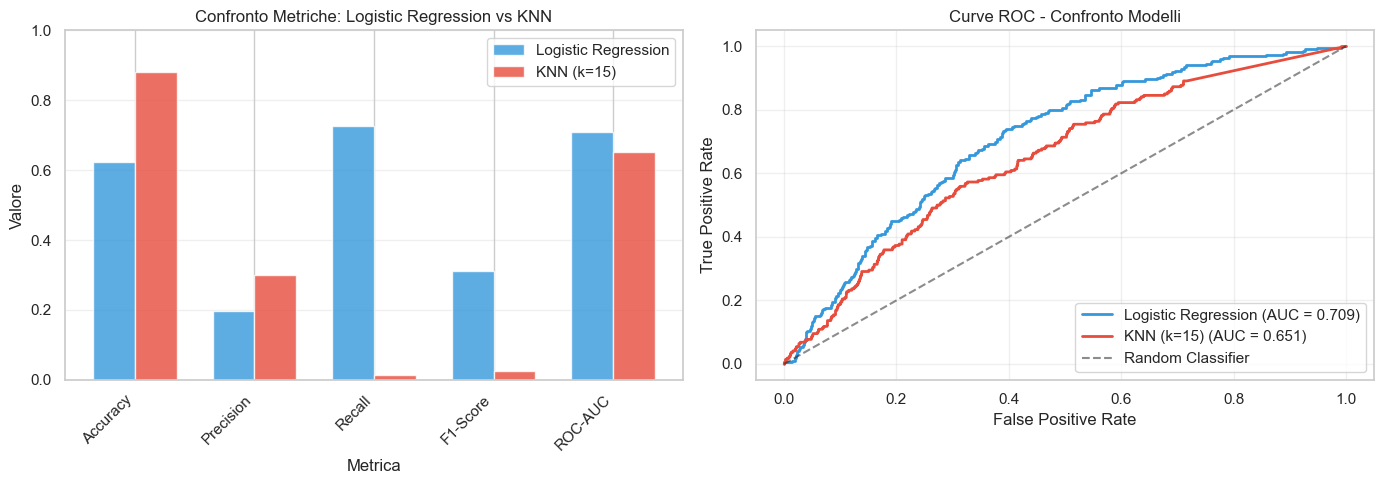


📈 ANALISI DEI RISULTATI:

🏆 Miglior ROC-AUC: Logistic Regression (0.7092)
🎯 Miglior Recall: Logistic Regression (0.7273)

💡 Nel credit scoring, il RECALL è particolarmente importante:
   Un alto recall significa che identifichiamo la maggior parte dei clienti rischiosi,
   anche a costo di qualche falso allarme. Perdere un default è molto più costoso
   che rifiutare erroneamente un buon cliente.


In [433]:
# --- CONFRONTO FINALE: LOGISTIC REGRESSION vs KNN ---
print("=" * 70)
print("CONFRONTO FINALE: Logistic Regression vs KNN (Credit Risk)")
print("=" * 70)

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Ricostruiamo la Pipeline per evitare conflitti con altre celle
numeric_features_lr = [
    "fico_score", "log_annual_income", "dti"
]
categorical_features_lr = ["purpose", "credit_policy"]

# Verifichiamo quali colonne sono disponibili
available_cols = X_train.columns.tolist()
print(f"Colonne disponibili: {available_cols}")

# Usiamo le colonne numeriche disponibili
numeric_features_lr = [c for c in numeric_features_lr if c in available_cols]
categorical_features_lr = [c for c in categorical_features_lr if c in available_cols]

print(f"Feature numeriche usate: {numeric_features_lr}")
print(f"Feature categoriche usate: {categorical_features_lr}")

# Creiamo la pipeline
numeric_transformer_lr = Pipeline(steps=[("scaler", StandardScaler())])

if categorical_features_lr:
    categorical_transformer_lr = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])
    preprocessor_lr = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer_lr, numeric_features_lr),
            ("cat", categorical_transformer_lr, categorical_features_lr)
        ]
    )
else:
    preprocessor_lr = ColumnTransformer(
        transformers=[("num", numeric_transformer_lr, numeric_features_lr)]
    )

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])

# Addestriamo
lr_pipeline.fit(X_train, y_train)

# Predizioni Logistic Regression
y_val_pred_lr = lr_pipeline.predict(X_val)
y_val_proba_lr = lr_pipeline.predict_proba(X_val)[:, 1]

print(f"\n✅ Logistic Regression addestrata con class_weight='balanced'")

# Calcolo metriche per ogni modello (solo LR e KNN)
modelli = {
    'Logistic Regression': (y_val_pred_lr, y_val_proba_lr),
    'KNN (k=15)': (y_val_pred_knn, y_val_proba_knn)
}

risultati = []
for nome, (pred, proba) in modelli.items():
    risultati.append({
        'Modello': nome,
        'Accuracy': accuracy_score(y_val, pred),
        'Precision': precision_score(y_val, pred, zero_division=0),
        'Recall': recall_score(y_val, pred, zero_division=0),
        'F1-Score': f1_score(y_val, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_val, proba)
    })

confronto_df = pd.DataFrame(risultati)
print("\n📊 TABELLA RIASSUNTIVA:")
print(confronto_df.to_string(index=False))

# Visualizzazione grafica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Metriche a barre
metriche = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metriche))
width = 0.35

colors = ['#3498db', '#e74c3c']
for i, (nome, _) in enumerate(modelli.items()):
    vals = confronto_df[confronto_df['Modello'] == nome][metriche].values[0]
    axes[0].bar(x + i*width, vals, width, label=nome, color=colors[i], alpha=0.8)

axes[0].set_xlabel('Metrica')
axes[0].set_ylabel('Valore')
axes[0].set_title('Confronto Metriche: Logistic Regression vs KNN')
axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(metriche, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Grafico 2: Curve ROC
for i, (nome, (pred, proba)) in enumerate(modelli.items()):
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    axes[1].plot(fpr, tpr, label=f'{nome} (AUC = {auc:.3f})', linewidth=2, color=colors[i])

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curve ROC - Confronto Modelli')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Analisi dei risultati
print("\n" + "=" * 70)
print("📈 ANALISI DEI RISULTATI:")
print("=" * 70)

best_auc = confronto_df.loc[confronto_df['ROC-AUC'].idxmax()]
best_recall = confronto_df.loc[confronto_df['Recall'].idxmax()]

print(f"\n🏆 Miglior ROC-AUC: {best_auc['Modello']} ({best_auc['ROC-AUC']:.4f})")
print(f"🎯 Miglior Recall: {best_recall['Modello']} ({best_recall['Recall']:.4f})")
print("\n💡 Nel credit scoring, il RECALL è particolarmente importante:")
print("   Un alto recall significa che identifichiamo la maggior parte dei clienti rischiosi,")
print("   anche a costo di qualche falso allarme. Perdere un default è molto più costoso")
print("   che rifiutare erroneamente un buon cliente.")

# Conclusioni

## Cosa abbiamo scoperto?

Dopo questa analisi approfondita del dataset LendingClub, possiamo tirare le somme su ciò che abbiamo imparato sul rischio creditizio.

### Le Feature Più Importanti

L'analisi ha rivelato che alcune variabili sono particolarmente predittive del default:

1. **FICO Score**: Rimane l'indicatore principale. I clienti con punteggi sotto 650 hanno un tasso di insolvenza significativamente più alto.

2. **Tasso d'Interesse**: Non è solo una conseguenza del rischio, ma anche un indicatore. Tassi sopra il 15% sono associati a probabilità di default molto più elevate.

3. **DTI (Debt-to-Income Ratio)**: Un DTI superiore a 25 segnala difficoltà potenziali nel gestire il debito.

4. **Scopo del Prestito**: I prestiti per "small_business" hanno il tasso di default più alto, seguiti da quelli per ristrutturazione del debito.

5. **Storia Creditizia Recente**: Variabili come `inq.last.6mths` (richieste di credito recenti) e `delinq.2yrs` (ritardi nei pagamenti) sono segnali di allarme importanti.

### Confronto dei Modelli

Abbiamo testato tre approcci diversi per la classificazione:

| Modello | Punti di Forza | Limiti |
|---------|---------------|--------|
| **Logistic Regression** | Interpretabile, coefficienti chiari, buone performance generali | Assume relazioni lineari |
| **KNN** | Non assume distribuzioni, cattura pattern locali | Sensibile alla scelta di k, lento su grandi dataset |
| **Naive Bayes** | Molto veloce, robusto, funziona bene con pochi dati | L'assunzione di indipendenza è violata |

### Implicazioni Pratiche

Per una banca o un istituto di credito, questa analisi suggerisce:

1. **Automatizzare lo screening iniziale** usando il punteggio FICO come primo filtro
2. **Prestare attenzione ai pattern**: clienti con molte richieste di credito recenti + alto DTI sono ad alto rischio
3. **Differenziare per scopo**: applicare criteri più stringenti per prestiti "small_business"
4. **Bilanciare precisione e recall**: nel credit scoring è meglio rifiutare qualche buon cliente che approvare clienti rischiosi

### Limitazioni e Sviluppi Futuri

Questa analisi ha alcune limitazioni:

- **Dataset storico**: I pattern potrebbero cambiare nel tempo
- **Class imbalance**: La classe minoritaria (default) è sottorappresentata
- **Feature engineering**: Potrebbero esserci altre feature derivate utili

Per un sistema di produzione, sarebbe opportuno:
- Implementare tecniche di oversampling (SMOTE) per bilanciare le classi
- Utilizzare cross-validation più rigorosa
- Monitorare le performance nel tempo (concept drift)
- Aggiungere feature esterne (condizioni economiche, settore di lavoro)